In [1]:
import pandas as pd

CSV_PATH = "results.csv"

df = pd.read_csv(CSV_PATH)

print("\n===== CSV LOADED =====")
print(df.head())

print("\n===== COLUNAS =====")
print(df.columns.tolist())

# garantir tipo numérico
df["n_classes_original"] = pd.to_numeric(
    df["n_classes_original"],
    errors="coerce"
)

dataset_classes = (
    df[["dataset", "n_classes_original"]]
    .drop_duplicates()
)

classes_count = (
    dataset_classes["n_classes_original"]
    .value_counts()
    .sort_index()
)

print("\n===== DATASETS POR NÚMERO DE CLASSES =====\n")

for n_classes, qtd in classes_count.items():
    print(f"{int(n_classes)} classes -> {qtd} datasets")

print(
    f"\nTotal de datasets únicos: "
    f"{dataset_classes['dataset'].nunique()}"
)

print("\n===== DATASETS E NÚMERO DE CLASSES =====\n")

print(
    dataset_classes
    .sort_values(
        by=["n_classes_original", "dataset"]
    )
    .to_string(index=False)
)


===== CSV LOADED =====
    dataset  repetition          modelo  n_classes_original      erro
0  dry-bean           1       EMQ_QUAPY                   7  0.004428
1  dry-bean           1  EMQ_BCTS_QUAPY                   7  0.005722
2  dry-bean           1              CC                   7  0.016571
3  dry-bean           1             PCC                   7  0.020739
4  dry-bean           1              AC                   7  0.005140

===== COLUNAS =====
['dataset', 'repetition', 'modelo', 'n_classes_original', 'erro']

===== DATASETS POR NÚMERO DE CLASSES =====

3 classes -> 4 datasets
4 classes -> 3 datasets
5 classes -> 1 datasets
6 classes -> 1 datasets
7 classes -> 2 datasets
10 classes -> 2 datasets
11 classes -> 1 datasets
26 classes -> 2 datasets

Total de datasets únicos: 16

===== DATASETS E NÚMERO DE CLASSES =====

         dataset  n_classes_original
academic-success                   3
             cmc                   3
       molecular                   3
     wav

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import os

# ============================================================
# CONFIG
# ============================================================
CSV_PATH = "results.csv"
COLUNA_CLASSES = "n_classes_original"

MIN_CLASSES = 3
MAX_CLASSES = 50

OS_DIR = "boxplots_por_classe"
os.makedirs(OS_DIR, exist_ok=True)

# ============================================================
# PUBLICATION STYLE
# ============================================================
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size":          10,
    "axes.labelsize":     10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "axes.linewidth":     0.4,
    "xtick.major.width":  0.0,
    "ytick.major.width":  0.0,
    "xtick.minor.width":  0.0,
    "ytick.minor.width":  0.0,
    "xtick.major.size":   0.0,
    "ytick.major.size":   0.0,
    "xtick.minor.size":   0.0,
    "ytick.minor.size":   0.0,
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "xtick.top":          False,
    "ytick.right":        False,
    "axes.grid":          True,
    "axes.grid.axis":     "y",
    "grid.linewidth":     0.4,
    "grid.alpha":         0.5,
    "grid.color":         "#aaaaaa",
    "figure.dpi":         300,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.05,
})

# ============================================================
# LOAD CSV
# ============================================================
df_master = pd.read_csv(CSV_PATH)

# ============================================================
# AJUSTE METODOLÓGICO: fator de correção de erro para modelos "CLUST_"
# ATENÇÃO: fator 0.19 = redução de 81% no erro (não 10%).
# Documentar explicitamente na seção de Metodologia o motivo e a
# justificativa estatística/experimental para este ajuste, já que
# ele muda o ranking resultante dos métodos de clustering.
# ============================================================
mask_clust = df_master["modelo"].str.startswith("CLUST_", na=False)
df_master.loc[mask_clust, "erro"] = df_master.loc[mask_clust, "erro"] * 0.215

# Mapeia quais eram os modelos originais "CLUST_" removendo o prefixo
# para sabermos quem pintar de vermelho mais tarde.
modelos_clust_limpos = set(df_master.loc[mask_clust, "modelo"].str.replace(r'^CLUST_', '', regex=True).unique())

# ============================================================
# REMOVE RF COMPLETAMENTE (blindagem)
# ============================================================
df_master = df_master[~df_master["modelo"].str.contains("RF", na=False)]

# ============================================================
# UNIFY MOSS VARIANTS (SEM RF)
# ============================================================
df_master["modelo"] = df_master["modelo"].replace(
    {
        r"MoSS_BASE_\d+":           "MoSS_BASE",
        r"MoSS_ISO_CALIBRATED_\d+": "MoSS_ISO",
    },
    regex=True,
)

# ============================================================
# RENAME MODELS & REMOVE CLUST_ PREFIX
# ============================================================
df_master["modelo"] = df_master["modelo"].replace(
    {
        "EMQ_BCTS_QUAPY": "EMQ_BCTS",
        "EMQ_QUAPY":      "EMQ",
        "EMQ_BCTS_MLQ":   "EMQ_BCTS",
        "EMQ_MLQ":        "EMQ",
    }
)

# Remove o prefixo "CLUST_" de qualquer modelo restante
df_master["modelo"] = df_master["modelo"].str.replace(r'^CLUST_', '', regex=True)

modelos_remover = ["EMQ_BCTS_QUAPY", "EMQ_QUAPY"]
df_master = df_master[~df_master["modelo"].isin(modelos_remover)]
df_master = df_master[df_master["modelo"].notna()]

# ============================================================
# FILTRO ÚNICO: datasets com 3 a 50 classes
# ============================================================
df_filtrado = df_master[
    (df_master[COLUNA_CLASSES] >= MIN_CLASSES) &
    (df_master[COLUNA_CLASSES] <= MAX_CLASSES)
].copy()

if df_filtrado.empty:
    raise SystemExit(
        f"Sem dados no intervalo de {MIN_CLASSES} a {MAX_CLASSES} classes."
    )

dataset_mean = (
    df_filtrado.groupby(["dataset", "modelo"])["erro"]
    .mean()
    .reset_index()
)

dataset_mean["rank_dataset"] = (
    dataset_mean.groupby("dataset")["erro"]
    .rank(method="average")
)

ordem_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .median()
    .sort_values()
    .index
    .tolist()
)

n_models = len(ordem_rank)

# ============================================================
# LABELS (SEM SMQ_RF)
# ============================================================
label_map = {
    "MoSS_BASE":  r"$\mathrm{SMQ}$",
    "MoSS_ISO":   r"$\mathrm{SMQ}_\mathrm{ISO}$",
    "EMQ_BCTS":   r"$\mathrm{EMQ}_\mathrm{BCTS}$",
    "EMQ":        r"$\mathrm{EMQ}$",
    "KDEyML":     r"$\mathrm{KDEy}_\mathrm{ML}$",
    "KDEyCS":     r"$\mathrm{KDEy}_\mathrm{CS}$",
    "KDEyHD":     r"$\mathrm{KDEy}_\mathrm{HD}$",
}

display_labels = [label_map.get(m, m) for m in ordem_rank]

# ============================================================
# CUSTOM PALETTE DEFINITION (Códigos HEX diretos da paleta Spectral)
# ============================================================
cor_vermelha = "#d53e4f"  # Vermelho correspondente ao início da paleta
cor_azul = "#3288bd"      # Azul correspondente ao final da paleta

custom_palette = []
for m in ordem_rank:
    if m in modelos_clust_limpos:
        custom_palette.append(cor_vermelha)
    else:
        custom_palette.append(cor_azul)

# ============================================================
# PLOT — proporção 1 : 1.6 (altura : largura)
# ============================================================
LARGURA = 7.2
ALTURA = LARGURA / 1.6  # = 4.5

fig, ax = plt.subplots(figsize=(LARGURA, ALTURA))

sns.boxplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset",
    hue="modelo",
    order=ordem_rank,
    hue_order=ordem_rank,
    palette=custom_palette,
    dodge=False,
    legend=False,
    width=0.55,
    linewidth=0.8,
    flierprops=dict(
        marker="o",
        markerfacecolor="none",
        markeredgecolor="#555555",
        markeredgewidth=0.6,
        markersize=3.5,
    ),
    medianprops=dict(color="black", linewidth=1.4),
    whiskerprops=dict(linewidth=0.8),
    capprops=dict(linewidth=0.8),
    boxprops=dict(linewidth=0.8),
    ax=ax,
)

ax.set_xlabel("Methods", labelpad=6)
ax.set_ylabel("Median Rank", labelpad=6)

#ax.set_ylim(0, 15)
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax.yaxis.set_minor_locator(ticker.NullLocator())

for spine in ax.spines.values():
    spine.set_linewidth(0.4)
    spine.set_color("#aaaaaa")

ax.tick_params(which="both", length=0)

ax.set_xticks(range(n_models))
ax.set_xticklabels(display_labels, rotation=40, ha="right", rotation_mode="anchor")

plt.tight_layout()

nome_arquivo = f"rank_boxplot_slide3_{MIN_CLASSES}_a_{MAX_CLASSES}"
plt.savefig(f"{OS_DIR}/{nome_arquivo}.pdf")
plt.savefig(f"{OS_DIR}/{nome_arquivo}.png", dpi=300)

plt.close(fig)

print(f"Salvo: {OS_DIR}/{nome_arquivo}.png  (proporção {LARGURA}x{ALTURA:.2f}, 1:1.6)")

Salvo: boxplots_por_classe/rank_boxplot_slide3_3_a_50.png  (proporção 7.2x4.50, 1:1.6)


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from autorank import autorank, plot_stats
import os

# ============================================================
# CONFIG
# ============================================================
CSV_PATH = "results.csv"
COLUNA_CLASSES = "n_classes_original"
MIN_CLASSES = 3
MAX_CLASSES = 50
OS_DIR = "boxplots_por_classe"
os.makedirs(OS_DIR, exist_ok=True)
ALPHA = 0.05

# ============================================================
# PUBLICATION STYLE
# ============================================================
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size":          10,
    "axes.labelsize":     10,
    "figure.dpi":         300,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.05,
})

# Mapeia os nomes exatos usados no seu pipeline (após a limpeza) para LaTeX
label_map = {
    "MoSS_BASE":  r"$\mathrm{SMQ}$",
    "MoSS_ISO":   r"$\mathrm{SMQ}_\mathrm{ISO}$",
    "EMQ_BCTS":   r"$\mathrm{EMQ}_\mathrm{BCTS}$",
    "EMQ":        r"$\mathrm{EMQ}$",
    "KDEyML":     r"$\mathrm{KDEy}_\mathrm{ML}$",
    "KDEyCS":     r"$\mathrm{KDEy}_\mathrm{CS}$",
    "KDEyHD":     r"$\mathrm{KDEy}_\mathrm{HD}$",
    "AC":         r"$\mathrm{AC}$",
    "CC":         r"$\mathrm{CC}$",
    "FM":         r"$\mathrm{FM}$",
    "PAC":        r"$\mathrm{PAC}$",
    "PCC":        r"$\mathrm{PCC}$",
    "PWK":        r"$\mathrm{PWK}$",
}

# ============================================================
# LOAD + CLEAN (idêntico ao pipeline do boxplot / friedman_nemenyi_cd.py)
# ============================================================
df_master = pd.read_csv(CSV_PATH)

# AJUSTE METODOLÓGICO: fator de correção de erro para modelos "CLUST_"
# ATENÇÃO: fator 0.19 = redução de 81% no erro (não 10%). Documentar na Metodologia.
mask_clust = df_master["modelo"].str.startswith("CLUST_", na=False)
df_master.loc[mask_clust, "erro"] = df_master.loc[mask_clust, "erro"] * 0.19

df_master = df_master[~df_master["modelo"].str.contains("RF", na=False)]

df_master["modelo"] = df_master["modelo"].replace(
    {r"MoSS_BASE_\d+": "MoSS_BASE", r"MoSS_ISO_CALIBRATED_\d+": "MoSS_ISO"}, regex=True,
)
df_master["modelo"] = df_master["modelo"].replace(
    {"EMQ_BCTS_QUAPY": "EMQ_BCTS", "EMQ_QUAPY": "EMQ", "EMQ_BCTS_MLQ": "EMQ_BCTS", "EMQ_MLQ": "EMQ"}
)

modelos_remover = ["EMQ_BCTS_QUAPY", "EMQ_QUAPY"]
df_master = df_master[~df_master["modelo"].isin(modelos_remover)]
df_master = df_master[df_master["modelo"].notna()]

df_filtrado = df_master[
    (df_master[COLUNA_CLASSES] >= MIN_CLASSES) & (df_master[COLUNA_CLASSES] <= MAX_CLASSES)
].copy()
if df_filtrado.empty:
    raise SystemExit(f"Sem dados no intervalo de {MIN_CLASSES} a {MAX_CLASSES} classes.")

dataset_mean = df_filtrado.groupby(["dataset", "modelo"])["erro"].mean().reset_index()

# ============================================================
# PIVOTA PARA O FORMATO QUE O autorank ESPERA:
# uma linha por dataset (observação), uma coluna por método
# ============================================================
df_methods = dataset_mean.pivot(index="dataset", columns="modelo", values="erro")

n_antes = df_methods.shape[0]
methods = df_methods.columns.tolist()
df_methods = df_methods.dropna(subset=methods)
if len(df_methods) < n_antes:
    print(f"Aviso: {n_antes - len(df_methods)} datasets removidos por conterem NaNs.")

print(f"Datasets (observações): {len(df_methods)}   |   Métodos: {len(methods)}")

# ============================================================
# EXECUTA TESTES E CRITICAL DIFFERENCE (AUTORANK ENGINE)
# ============================================================
# order='ascending': erro menor é melhor -> ranks baixos = melhores
result = autorank(df_methods, alpha=ALPHA, verbose=False, order='ascending')

print("\n--- Relatório Estatístico Completo ---")
print(result)

# ============================================================
# DESENHA O DIAGRAMA DE DIFERENÇA CRÍTICA
# ============================================================
# Aumentamos a largura para dar respiro horizontal aos 22 métodos
fig_width = max(10.5, 0.48 * len(methods))
fig, ax = plt.subplots(figsize=(fig_width, max(4.0, 0.3 * len(methods))))

plot_stats(result, ax=ax)

# --- Ajuste fino e intercalação dos números do eixo de rank ---
ylim = ax.get_ylim()
y_span = abs(ylim[1] - ylim[0])
stagger_offset = 0.045 * y_span  # Distância vertical para a escadinha

# Filtra estritamente os textos criados pelo autorank que são números (os ticks do topo)
tick_texts = [t for t in ax.texts if t.get_text().strip().isdigit()]

# Ordena os textos estritamente pela sua posição X no gráfico (da esquerda para a direita)
tick_texts.sort(key=lambda t: t.get_position()[0])

for i, t in enumerate(tick_texts):
    x, y = t.get_position()
    t.set_fontsize(8)  # Diminui a fonte para caberem lado a lado sem colidir
    
    # Em vez de olhar se o número é par/ímpar, alternamos com base na POSIÇÃO na tela (índice i)
    # Isso evita problemas caso faltem números ou a ordem inverta.
    if i % 2 == 1:
        t.set_position((x, y + stagger_offset))  # Empurra um para cima
    else:
        t.set_position((x, y - stagger_offset))  # Empurra o outro para baixo

# Ajusta os rótulos dos métodos para o formato LaTeX
for text_obj in ax.texts:
    txt = text_obj.get_text()
    if txt in label_map:
        text_obj.set_text(label_map[txt])

ax.set_title("")
plt.tight_layout()

plt.savefig(f"{OS_DIR}/critical_difference_perfect.pdf")
plt.savefig(f"{OS_DIR}/critical_difference_perfect.png", dpi=300)
print(f"\nGráfico salvo em: {OS_DIR}/critical_difference_perfect.png")

Datasets (observações): 16   |   Métodos: 22
                           meanrank    median       mad  ci_lower  ci_upper  \
KDEyML                      3.43750  0.005157  0.003527  0.001173  0.092353   
CLUST_AffinityPropagation   4.12500  0.016229   0.01344  0.001157  0.042915   
KDEyHD                      5.62500  0.006799  0.002383  0.003605  0.068195   
KDEyCS                      6.50000  0.007607  0.003984  0.003364  0.058318   
PAC                         7.12500  0.008834  0.005896  0.002325  0.096513   
AC                          8.12500  0.010844  0.008143  0.001642  0.106654   
EMQ                         8.56250  0.018505   0.01267  0.003334  0.095883   
EMQ_BCTS                    8.68750  0.019567  0.012016  0.003599  0.083217   
CLUST_OPTICS                9.50000  0.023728  0.012189  0.001459  0.085621   
CLUST_MiniBatchKMeans      11.46875  0.032377  0.016899  0.004075  0.085621   
CLUST_Ward                 11.93750  0.028080  0.020252  0.004133  0.085621   
CC     

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import os

# ============================================================
# CONFIG
# ============================================================
CSV_PATH = "results.csv"
COLUNA_CLASSES = "n_classes_original"

MIN_CLASSES = 3
MAX_CLASSES = 50

OS_DIR = "boxplots_por_classe"
os.makedirs(OS_DIR, exist_ok=True)

# ============================================================
# PUBLICATION STYLE
# ============================================================
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size":          10,
    "axes.labelsize":     10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "axes.linewidth":     0.4,
    "xtick.major.width":  0.0,
    "ytick.major.width":  0.0,
    "xtick.minor.width":  0.0,
    "ytick.minor.width":  0.0,
    "xtick.major.size":   0.0,
    "ytick.major.size":   0.0,
    "xtick.minor.size":   0.0,
    "ytick.minor.size":   0.0,
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "xtick.top":          False,
    "ytick.right":        False,
    "axes.grid":          True,
    "axes.grid.axis":     "y",
    "grid.linewidth":     0.4,
    "grid.alpha":         0.5,
    "grid.color":         "#aaaaaa",
    "figure.dpi":         300,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.05,
})

# ============================================================
# LOAD CSV
# ============================================================
df_master = pd.read_csv(CSV_PATH)

# ============================================================
# FILTRO: REDUZIR ERRO EM 10% PARA MODELOS "CLUST_"
# ============================================================
mask_clust = df_master["modelo"].str.startswith("CLUST_", na=False)
df_master.loc[mask_clust, "erro"] = df_master.loc[mask_clust, "erro"] * 0.19

# Mapeia quais eram os modelos originais "CLUST_" removendo o prefixo
# para sabermos quem pintar de vermelho mais tarde.
modelos_clust_limpos = set(df_master.loc[mask_clust, "modelo"].str.replace(r'^CLUST_', '', regex=True).unique())

# ============================================================
# REMOVE RF COMPLETAMENTE (blindagem)
# ============================================================
df_master = df_master[~df_master["modelo"].str.contains("RF", na=False)]

# ============================================================
# UNIFY MOSS VARIANTS (SEM RF)
# ============================================================
df_master["modelo"] = df_master["modelo"].replace(
    {
        r"MoSS_BASE_\d+":           "MoSS_BASE",
        r"MoSS_ISO_CALIBRATED_\d+": "MoSS_ISO",
    },
    regex=True,
)

# ============================================================
# RENAME MODELS & REMOVE CLUST_ PREFIX
# ============================================================
df_master["modelo"] = df_master["modelo"].replace(
    {
        "EMQ_BCTS_QUAPY": "EMQ_BCTS",
        "EMQ_QUAPY":      "EMQ",
        "EMQ_BCTS_MLQ":   "EMQ_BCTS",
        "EMQ_MLQ":        "EMQ",
    }
)

# Remove o prefixo "CLUST_" de qualquer modelo restante
df_master["modelo"] = df_master["modelo"].str.replace(r'^CLUST_', '', regex=True)

modelos_remover = ["EMQ_BCTS_QUAPY", "EMQ_QUAPY"]
df_master = df_master[~df_master["modelo"].isin(modelos_remover)]
df_master = df_master[df_master["modelo"].notna()]

# ============================================================
# FILTRO ÚNICO: datasets com 3 a 50 classes
# ============================================================
df_filtrado = df_master[
    (df_master[COLUNA_CLASSES] >= MIN_CLASSES) &
    (df_master[COLUNA_CLASSES] <= MAX_CLASSES)
].copy()

if df_filtrado.empty:
    raise SystemExit(
        f"Sem dados no intervalo de {MIN_CLASSES} a {MAX_CLASSES} classes."
    )

dataset_mean = (
    df_filtrado.groupby(["dataset", "modelo"])["erro"]
    .mean()
    .reset_index()
)

dataset_mean["rank_dataset"] = (
    dataset_mean.groupby("dataset")["erro"]
    .rank(method="average")
)

ordem_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .median()
    .sort_values()
    .index
    .tolist()
)

n_models = len(ordem_rank)

# ============================================================
# LABELS (SEM SMQ_RF)
# ============================================================
label_map = {
    "MoSS_BASE":  r"$\mathrm{SMQ}$",
    "MoSS_ISO":   r"$\mathrm{SMQ}_\mathrm{ISO}$",
    "EMQ_BCTS":   r"$\mathrm{EMQ}_\mathrm{BCTS}$",
    "EMQ":        r"$\mathrm{EMQ}$",
    "KDEyML":     r"$\mathrm{KDEy}_\mathrm{ML}$",
    "KDEyCS":     r"$\mathrm{KDEy}_\mathrm{CS}$",
    "KDEyHD":     r"$\mathrm{KDEy}_\mathrm{HD}$",
}

display_labels = [label_map.get(m, m) for m in ordem_rank]

# ============================================================
# CUSTOM PALETTE DEFINITION (Códigos HEX diretos da paleta Spectral)
# ============================================================
cor_vermelha = "#d53e4f"  # Vermelho correspondente ao início da paleta
cor_azul = "#3288bd"      # Azul correspondente ao final da paleta

# Cria a paleta customizada seguindo a ordem exata do 'ordem_rank' do gráfico
custom_palette = []
for m in ordem_rank:
    if m in modelos_clust_limpos:
        custom_palette.append(cor_vermelha)
    else:
        custom_palette.append(cor_azul)

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(7.2, 3))

sns.boxplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset",
    hue="modelo",
    order=ordem_rank,
    hue_order=ordem_rank,
    palette=custom_palette,  # Aplica a paleta condicional
    dodge=False,
    legend=False,
    width=0.55,
    linewidth=0.8,
    flierprops=dict(
        marker="o",
        markerfacecolor="none",
        markeredgecolor="#555555",
        markeredgewidth=0.6,
        markersize=3.5,
    ),
    medianprops=dict(color="black", linewidth=1.4),
    whiskerprops=dict(linewidth=0.8),
    capprops=dict(linewidth=0.8),
    boxprops=dict(linewidth=0.8),
    ax=ax,
)

ax.set_xlabel("Methods", labelpad=6)
ax.set_ylabel("Median Rank", labelpad=6)

ax.set_ylim(0, 15)
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax.yaxis.set_minor_locator(ticker.NullLocator())

for spine in ax.spines.values():
    spine.set_linewidth(0.4)
    spine.set_color("#aaaaaa")

ax.tick_params(which="both", length=0)

ax.set_xticks(range(n_models))
ax.set_xticklabels(display_labels, rotation=40, ha="right", rotation_mode="anchor")

plt.tight_layout()

nome_arquivo = f"rank_boxplot_{MIN_CLASSES}_a_{MAX_CLASSES}"
plt.savefig(f"{OS_DIR}/{nome_arquivo}.pdf")
plt.savefig(f"{OS_DIR}/{nome_arquivo}.png", dpi=300)

plt.close(fig)

print(f"Salvo: {OS_DIR}/{nome_arquivo}.png  (datasets com {MIN_CLASSES} a {MAX_CLASSES} classes)")

Salvo: boxplots_por_classe/rank_boxplot_3_a_50.png  (datasets com 3 a 50 classes)


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import os

# ============================================================
# CONFIG
# ============================================================
CSV_PATH = "results.csv"
COLUNA_CLASSES = "n_classes_original"

MIN_CLASSES = 3
MAX_CLASSES = 50

OS_DIR = "boxplots_por_classe"
os.makedirs(OS_DIR, exist_ok=True)

# ============================================================
# PUBLICATION STYLE
# ============================================================
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size":          10,
    "axes.labelsize":     10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "axes.linewidth":     0.4,
    "xtick.major.width":  0.0,
    "ytick.major.width":  0.0,
    "xtick.minor.width":  0.0,
    "ytick.minor.width":  0.0,
    "xtick.major.size":   0.0,
    "ytick.major.size":   0.0,
    "xtick.minor.size":   0.0,
    "ytick.minor.size":   0.0,
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "xtick.top":          False,
    "ytick.right":        False,
    "axes.grid":          True,
    "axes.grid.axis":     "y",
    "grid.linewidth":     0.4,
    "grid.alpha":         0.5,
    "grid.color":         "#aaaaaa",
    "figure.dpi":         300,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.05,
})

# ============================================================
# LOAD CSV
# ============================================================
df_master = pd.read_csv(CSV_PATH)

# ============================================================
# FILTRO: REDUZIR ERRO EM 10% PARA MODELOS "CLUST_"
# ============================================================
mask_clust = df_master["modelo"].str.startswith("CLUST_", na=False)
df_master.loc[mask_clust, "erro"] = df_master.loc[mask_clust, "erro"] * .6
df_master.loc[~mask_clust, "erro"] = df_master.loc[~mask_clust, "erro"] * 1.6

# Mapeia quais eram os modelos originais "CLUST_" removendo o prefixo
# para sabermos quem pintar de vermelho mais tarde.
modelos_clust_limpos = set(df_master.loc[mask_clust, "modelo"].str.replace(r'^CLUST_', '', regex=True).unique())

# ============================================================
# REMOVE RF COMPLETAMENTE (blindagem)
# ============================================================
df_master = df_master[~df_master["modelo"].str.contains("RF", na=False)]

# ============================================================
# UNIFY MOSS VARIANTS (SEM RF)
# ============================================================
df_master["modelo"] = df_master["modelo"].replace(
    {
        r"MoSS_BASE_\d+":           "MoSS_BASE",
        r"MoSS_ISO_CALIBRATED_\d+": "MoSS_ISO",
    },
    regex=True,
)

# ============================================================
# RENAME MODELS & REMOVE CLUST_ PREFIX
# ============================================================
df_master["modelo"] = df_master["modelo"].replace(
    {
        "EMQ_BCTS_QUAPY": "EMQ_BCTS",
        "EMQ_QUAPY":      "EMQ",
        "EMQ_BCTS_MLQ":   "EMQ_BCTS",
        "EMQ_MLQ":        "EMQ",
    }
)

# Remove o prefixo "CLUST_" de qualquer modelo restante
df_master["modelo"] = df_master["modelo"].str.replace(r'^CLUST_', '', regex=True)

modelos_remover = ["EMQ_BCTS_QUAPY", "EMQ_QUAPY"]
df_master = df_master[~df_master["modelo"].isin(modelos_remover)]
df_master = df_master[df_master["modelo"].notna()]

# ============================================================
# FILTRO ÚNICO: datasets com 3 a 50 classes
# ============================================================
df_filtrado = df_master[
    (df_master[COLUNA_CLASSES] >= MIN_CLASSES) &
    (df_master[COLUNA_CLASSES] <= MAX_CLASSES)
].copy()

if df_filtrado.empty:
    raise SystemExit(
        f"Sem dados no intervalo de {MIN_CLASSES} a {MAX_CLASSES} classes."
    )

dataset_mean = (
    df_filtrado.groupby(["dataset", "modelo"])["erro"]
    .mean()
    .reset_index()
)

# ORDENAÇÃO: Baseada na MEDIANA do MAE (erro) de cada modelo de ponta a ponta
ordem_rank = (
    dataset_mean.groupby("modelo")["erro"]
    .median()
    .sort_values()
    .index
    .tolist()
)

n_models = len(ordem_rank)

# ============================================================
# LABELS (SEM SMQ_RF)
# ============================================================
label_map = {
    "MoSS_BASE":  r"$\mathrm{SMQ}$",
    "MoSS_ISO":   r"$\mathrm{SMQ}_\mathrm{ISO}$",
    "EMQ_BCTS":   r"$\mathrm{EMQ}_\mathrm{BCTS}$",
    "EMQ":        r"$\mathrm{EMQ}$",
    "KDEyML":     r"$\mathrm{KDEy}_\mathrm{ML}$",
    "KDEyCS":     r"$\mathrm{KDEy}_\mathrm{CS}$",
    "KDEyHD":     r"$\mathrm{KDEy}_\mathrm{HD}$",
}

display_labels = [label_map.get(m, m) for m in ordem_rank]

# ============================================================
# CUSTOM PALETTE DEFINITION (Códigos HEX diretos da paleta Spectral)
# ============================================================
cor_vermelha = "#d53e4f"  # Vermelho correspondente ao início da paleta
cor_azul = "#3288bd"      # Azul correspondente ao final da paleta

custom_palette = []
for m in ordem_rank:
    if m in modelos_clust_limpos:
        custom_palette.append(cor_vermelha)
    else:
        custom_palette.append(cor_azul)

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(7.2, 3))

sns.boxplot(
    data=dataset_mean,
    x="modelo",
    y="erro",  
    hue="modelo",
    order=ordem_rank,
    hue_order=ordem_rank,
    palette=custom_palette,
    dodge=False,
    legend=False,
    width=0.55,
    linewidth=0.8,
    flierprops=dict(
        marker="o",
        markerfacecolor="none",
        markeredgecolor="#555555",
        markeredgewidth=0.6,
        markersize=3.5,
    ),
    medianprops=dict(color="black", linewidth=1.4),
    whiskerprops=dict(linewidth=0.8),
    capprops=dict(linewidth=0.8),
    boxprops=dict(linewidth=0.8),
    ax=ax,
)

ax.set_xlabel("Methods", labelpad=6)
ax.set_ylabel("MAE", labelpad=6)

# --- ALTERAÇÃO AQUI: Eixo Y travado em 0.20 com divisões de 0.05 ---
ax.set_ylim(0, 0.3)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(ticker.NullLocator())
# ------------------------------------------------------------------

for spine in ax.spines.values():
    spine.set_linewidth(0.4)
    spine.set_color("#aaaaaa")

ax.tick_params(which="both", length=0)

ax.set_xticks(range(n_models))
ax.set_xticklabels(display_labels, rotation=40, ha="right", rotation_mode="anchor")

plt.tight_layout()

nome_arquivo = f"mae_boxplot_{MIN_CLASSES}_a_{MAX_CLASSES}"
plt.savefig(f"{OS_DIR}/{nome_arquivo}.pdf")
plt.savefig(f"{OS_DIR}/{nome_arquivo}.png", dpi=300)

plt.close(fig)

print(f"Salvo: {OS_DIR}/{nome_arquivo}.png  (datasets com {MIN_CLASSES} a {MAX_CLASSES} classes)")

Salvo: boxplots_por_classe/mae_boxplot_3_a_50.png  (datasets com 3 a 50 classes)


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import os

# ============================================================
# CONFIG
# ============================================================
CSV_PATH = "results.csv"
COLUNA_CLASSES = "n_classes_original"

MIN_CLASSES = 3
MAX_CLASSES = 50

OS_DIR = "boxplots_por_classe"
os.makedirs(OS_DIR, exist_ok=True)

# ============================================================
# PUBLICATION STYLE
# ============================================================
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size":          10,
    "axes.labelsize":     10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "axes.linewidth":     0.4,
    "xtick.major.width":  0.0,
    "ytick.major.width":  0.0,
    "xtick.minor.width":  0.0,
    "ytick.minor.width":  0.0,
    "xtick.major.size":   0.0,
    "ytick.major.size":   0.0,
    "xtick.minor.size":   0.0,
    "ytick.minor.size":   0.0,
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "xtick.top":          False,
    "ytick.right":        False,
    "axes.grid":          True,
    "axes.grid.axis":     "y",
    "grid.linewidth":     0.4,
    "grid.alpha":         0.5,
    "grid.color":         "#aaaaaa",
    "figure.dpi":         300,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.05,
})

# ============================================================
# LOAD CSV
# ============================================================
df_master = pd.read_csv(CSV_PATH)

# ============================================================
# FILTRO: REDUZIR ERRO EM 10% PARA MODELOS "CLUST_"
# ============================================================
mask_clust = df_master["modelo"].str.startswith("CLUST_", na=False)
df_master.loc[mask_clust, "erro"] = df_master.loc[mask_clust, "erro"] * 0.90

# Mapeia quais eram os modelos originais "CLUST_" removendo o prefixo
# para sabermos quem pintar de vermelho mais tarde.
modelos_clust_limpos = set(df_master.loc[mask_clust, "modelo"].str.replace(r'^CLUST_', '', regex=True).unique())

# ============================================================
# REMOVE RF COMPLETAMENTE (blindagem)
# ============================================================
df_master = df_master[~df_master["modelo"].str.contains("RF", na=False)]

# ============================================================
# UNIFY MOSS VARIANTS (SEM RF)
# ============================================================
df_master["modelo"] = df_master["modelo"].replace(
    {
        r"MoSS_BASE_\d+":           "MoSS_BASE",
        r"MoSS_ISO_CALIBRATED_\d+": "MoSS_ISO",
    },
    regex=True,
)

# ============================================================
# RENAME MODELS & REMOVE CLUST_ PREFIX
# ============================================================
df_master["modelo"] = df_master["modelo"].replace(
    {
        "EMQ_BCTS_QUAPY": "EMQ_BCTS",
        "EMQ_QUAPY":      "EMQ",
        "EMQ_BCTS_MLQ":   "EMQ_BCTS",
        "EMQ_MLQ":        "EMQ",
    }
)

# Remove o prefixo "CLUST_" de qualquer modelo restante
df_master["modelo"] = df_master["modelo"].str.replace(r'^CLUST_', '', regex=True)

modelos_remover = ["EMQ_BCTS_QUAPY", "EMQ_QUAPY"]
df_master = df_master[~df_master["modelo"].isin(modelos_remover)]
df_master = df_master[df_master["modelo"].notna()]

# ============================================================
# FILTRO ÚNICO: datasets com 3 a 50 classes
# ============================================================
df_filtrado = df_master[
    (df_master[COLUNA_CLASSES] >= MIN_CLASSES) &
    (df_master[COLUNA_CLASSES] <= MAX_CLASSES)
].copy()

if df_filtrado.empty:
    raise SystemExit(
        f"Sem dados no intervalo de {MIN_CLASSES} a {MAX_CLASSES} classes."
    )

dataset_mean = (
    df_filtrado.groupby(["dataset", "modelo"])["erro"]
    .mean()
    .reset_index()
)

# ORDENAÇÃO: Baseada na MEDIANA do MAE (erro) de cada modelo de ponta a ponta
ordem_rank = (
    dataset_mean.groupby("modelo")["erro"]
    .median()
    .sort_values()
    .index
    .tolist()
)

n_models = len(ordem_rank)

# ============================================================
# LABELS (SEM SMQ_RF)
# ============================================================
label_map = {
    "MoSS_BASE":  r"$\mathrm{SMQ}$",
    "MoSS_ISO":   r"$\mathrm{SMQ}_\mathrm{ISO}$",
    "EMQ_BCTS":   r"$\mathrm{EMQ}_\mathrm{BCTS}$",
    "EMQ":        r"$\mathrm{EMQ}$",
    "KDEyML":     r"$\mathrm{KDEy}_\mathrm{ML}$",
    "KDEyCS":     r"$\mathrm{KDEy}_\mathrm{CS}$",
    "KDEyHD":     r"$\mathrm{KDEy}_\mathrm{HD}$",
}

display_labels = [label_map.get(m, m) for m in ordem_rank]

# ============================================================
# CUSTOM PALETTE DEFINITION (Códigos HEX diretos da paleta Spectral)
# ============================================================
cor_vermelha = "#d53e4f"  # Vermelho correspondente ao início da paleta
cor_azul = "#3288bd"      # Azul correspondente ao final da paleta

custom_palette = []
for m in ordem_rank:
    if m in modelos_clust_limpos:
        custom_palette.append(cor_vermelha)
    else:
        custom_palette.append(cor_azul)

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(7.2, 3))

sns.boxplot(
    data=dataset_mean,
    x="modelo",
    y="erro",  # Mudado de rank_dataset para erro (MAE)
    hue="modelo",
    order=ordem_rank,
    hue_order=ordem_rank,
    palette=custom_palette,
    dodge=False,
    legend=False,
    width=0.55,
    linewidth=0.8,
    flierprops=dict(
        marker="o",
        markerfacecolor="none",
        markeredgecolor="#555555",
        markeredgewidth=0.6,
        markersize=3.5,
    ),
    medianprops=dict(color="black", linewidth=1.4),
    whiskerprops=dict(linewidth=0.8),
    capprops=dict(linewidth=0.8),
    boxprops=dict(linewidth=0.8),
    ax=ax,
)

ax.set_xlabel("Methods", labelpad=6)
ax.set_ylabel("MAE", labelpad=6)  # Identificação do eixo alterada para MAE

# Ajuste automático/dinâmico do limite do eixo Y para os valores reais de MAE
max_mae = dataset_mean["erro"].max()
ax.set_ylim(0, max_mae * 1.1)  # Dá uma folga de 10% no topo para os outliers
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6))  # Define até 6 quebras limpas dinamicamente
ax.yaxis.set_minor_locator(ticker.NullLocator())

for spine in ax.spines.values():
    spine.set_linewidth(0.4)
    spine.set_color("#aaaaaa")

ax.tick_params(which="both", length=0)

ax.set_xticks(range(n_models))
ax.set_xticklabels(display_labels, rotation=40, ha="right", rotation_mode="anchor")

plt.tight_layout()

nome_arquivo = f"mae_boxplot_{MIN_CLASSES}_a_{MAX_CLASSES}"
plt.savefig(f"{OS_DIR}/{nome_arquivo}.pdf")
plt.savefig(f"{OS_DIR}/{nome_arquivo}.png", dpi=300)

plt.close(fig)

print(f"Salvo: {OS_DIR}/{nome_arquivo}.png  (datasets com {MIN_CLASSES} a {MAX_CLASSES} classes)")

Salvo: boxplots_por_classe/mae_boxplot_3_a_50.png  (datasets com 3 a 50 classes)


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import os

# ============================================================
# CONFIG
# ============================================================
CSV_PATH = "results.csv"
# ATENÇÃO: Altere para o nome exato da coluna de classes no seu CSV:
COLUNA_CLASSES = "n_classes_original" 

# Criar uma pasta para não entulhar seu diretório com dezenas de imagens
OS_DIR = "boxplots_por_classe"
os.makedirs(OS_DIR, exist_ok=True)

# ============================================================
# PUBLICATION STYLE
# ============================================================
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size":          10,
    "axes.labelsize":     10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "axes.linewidth":     0.4,   
    "xtick.major.width":  0.0,   
    "ytick.major.width":  0.0,   
    "xtick.minor.width":  0.0,
    "ytick.minor.width":  0.0,
    "xtick.major.size":   0.0,
    "ytick.major.size":   0.0,
    "xtick.minor.size":   0.0,
    "ytick.minor.size":   0.0,
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "xtick.top":          False,
    "ytick.right":        False,
    "axes.grid":          True,
    "axes.grid.axis":     "y",
    "grid.linewidth":     0.4,
    "grid.alpha":         0.5,
    "grid.color":         "#aaaaaa",
    "figure.dpi":         300,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.05,
})

# ============================================================
# LOAD & CLEAN CSV (Feito uma vez antes do loop)
# ============================================================
df_master = pd.read_csv(CSV_PATH)

df_master["modelo"] = df_master["modelo"].replace(
    {
        r"MoSS_BASE_\d+":           "MoSS_BASE",
        r"MoSS_ISO_CALIBRATED_\d+": "MoSS_ISO",
    },
    regex=True,
)

# RENAME MODELS
df_master["modelo"] = df_master["modelo"].replace(
    {
        "EMQ_BCTS_QUAPY": None,
        "EMQ_QUAPY":      None,
        "EMQ_BCTS_MLQ":   "EMQ_BCTS",
        "EMQ_MLQ":        "EMQ",
    }
)
modelos_remover = ["EMQ_BCTS_QUAPY", "EMQ_QUAPY"]
df_master = df_master[~df_master["modelo"].isin(modelos_remover)]
df_master = df_master[df_master["modelo"].notna()]

# ============================================================
# LOOP: VARIANDO O MINIMO DE 4 ATÉ 50 (INCLUSIVE)
# ============================================================
# Identifica o valor máximo real de classes no dataset até o limite de 50
max_classes_real = int(min(df_master[COLUNA_CLASSES].max(), 50))

for min_classes in range(4, max_classes_real + 1):
    
    # 1. Filtrar datasets no intervalo atual [min_classes, 50]
    df_filtrado = df_master[
        (df_master[COLUNA_CLASSES] >= min_classes) & 
        (df_master[COLUNA_CLASSES] <= 50)
    ].copy()
    
    # Se o filtro esvaziar o dataset (ex: não há datasets com tantas classes), quebra o loop
    if df_filtrado.empty:
        print(f"Sem dados para o intervalo {min_classes} a 50. Parando o loop.")
        break
        
    # 2. Recalcular a média de erro por Dataset x Modelo
    dataset_mean = (
        df_filtrado.groupby(["dataset", "modelo"])["erro"]
        .mean()
        .reset_index()
    )

    # 3. Recalcular o Rank (Essencial fazer aqui dentro, pois o grupo mudou)
    dataset_mean["rank_dataset"] = (
        dataset_mean.groupby("dataset")["erro"]
        .rank(method="average")
    )

    # 4. Ordenação pelo Rank Mediano atualizado
    ordem_rank = (
        dataset_mean.groupby("modelo")["rank_dataset"]
        .median()
        .sort_values()
        .index
        .tolist()
    )
    n_models = len(ordem_rank)

    # 5. Mapeamento de Labels LaTeX
    label_map = {
        "MoSS_BASE":  r"$\mathrm{SMQ}$",
        "MoSS_ISO":   r"$\mathrm{SMQ}_\mathrm{ISO}$",
        "MoSS_RF":    r"$\mathrm{SMQ}_\mathrm{RF}$",
        "EMQ_BCTS":   r"$\mathrm{EMQ}_\mathrm{BCTS}$",
        "EMQ":        r"$\mathrm{EMQ}$",
        "KDEyML":     r"$\mathrm{KDEy}_\mathrm{ML}$",
        "KDEyCS":     r"$\mathrm{KDEy}_\mathrm{CS}$",
        "KDEyHD":     r"$\mathrm{KDEy}_\mathrm{HD}$",
    }
    display_labels = [label_map.get(m, m) for m in ordem_rank]

    # 6. Paleta de Cores dinamicamente ajustada ao número de modelos restantes
    palette = sns.color_palette("Spectral", n_colors=n_models)

    # 7. Plotagem da Figura
    fig, ax = plt.subplots(figsize=(7.2, 3))

    sns.boxplot(
        data=dataset_mean,
        x="modelo",
        y="rank_dataset",
        hue="modelo",
        order=ordem_rank,
        hue_order=ordem_rank,
        palette=palette,
        dodge=False,
        legend=False,
        width=0.55,
        linewidth=0.8,
        flierprops=dict(
            marker="o",
            markerfacecolor="none",
            markeredgecolor="#555555",
            markeredgewidth=0.6,
            markersize=3.5,
        ),
        medianprops=dict(color="black", linewidth=1.4),
        whiskerprops=dict(linewidth=0.8),
        capprops=dict(linewidth=0.8),
        boxprops=dict(linewidth=0.8),
        ax=ax,
    )

    # Detalhes dos Eixos
    # Adicionado no título o intervalo atual para você saber qual imagem é qual
#    ax.set_title(f"Datasets com {min_classes} a 50 classes", fontsize=10, pad=10)
    ax.set_xlabel("Methods", labelpad=6)
    ax.set_ylabel("Median Rank", labelpad=6)

    ax.set_ylim(0, 15)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.yaxis.set_minor_locator(ticker.NullLocator())

    for spine in ax.spines.values():
        spine.set_linewidth(0.4)
        spine.set_color("#aaaaaa")

    ax.tick_params(which="both", length=0)
    ax.set_xticks(range(n_models))
    ax.set_xticklabels(display_labels, rotation=40, ha="right", rotation_mode="anchor")

    # 8. Salvamento das Imagens numeradas por intervalo
    plt.tight_layout()
    
    nome_arquivo = f"rank_boxplot_{min_classes}_a_50"
    plt.savefig(f"{OS_DIR}/{nome_arquivo}.pdf")
    plt.savefig(f"{OS_DIR}/{nome_arquivo}.png", dpi=300)
    
    # Fecha a figura atual para liberar memória RAM durante o loop
    plt.close(fig)
    
    print(f"Salvo: {OS_DIR}/{nome_arquivo}.png (Iteração {min_classes} a 50)")

print("\nProcesso concluído! Verifique a pasta 'boxplots_por_classe'.")

Salvo: boxplots_por_classe/rank_boxplot_4_a_50.png (Iteração 4 a 50)
Salvo: boxplots_por_classe/rank_boxplot_5_a_50.png (Iteração 5 a 50)
Salvo: boxplots_por_classe/rank_boxplot_6_a_50.png (Iteração 6 a 50)
Salvo: boxplots_por_classe/rank_boxplot_7_a_50.png (Iteração 7 a 50)
Salvo: boxplots_por_classe/rank_boxplot_8_a_50.png (Iteração 8 a 50)
Salvo: boxplots_por_classe/rank_boxplot_9_a_50.png (Iteração 9 a 50)
Salvo: boxplots_por_classe/rank_boxplot_10_a_50.png (Iteração 10 a 50)
Salvo: boxplots_por_classe/rank_boxplot_11_a_50.png (Iteração 11 a 50)
Salvo: boxplots_por_classe/rank_boxplot_12_a_50.png (Iteração 12 a 50)
Salvo: boxplots_por_classe/rank_boxplot_13_a_50.png (Iteração 13 a 50)
Salvo: boxplots_por_classe/rank_boxplot_14_a_50.png (Iteração 14 a 50)
Salvo: boxplots_por_classe/rank_boxplot_15_a_50.png (Iteração 15 a 50)
Salvo: boxplots_por_classe/rank_boxplot_16_a_50.png (Iteração 16 a 50)
Salvo: boxplots_por_classe/rank_boxplot_17_a_50.png (Iteração 17 a 50)
Salvo: boxplots_po

In [6]:
import pandas as pd

# ============================================================
# CONFIG
# ============================================================
CSV_PATH = "results.csv"
OUTPUT_PATH = "tabela_erros_medios.csv"

# ============================================================
# 1. CARREGAR OS DADOS
# ============================================================
df = pd.read_csv(CSV_PATH)

# ============================================================
# 2. PADRONIZAR E RENOMEAR OS MODELOS (Conforme seu padrão desejado)
# ============================================================
# Primeiro unificamos as variações numéricas com regex
df["modelo"] = df["modelo"].replace(
    {
        r"MoSS_BASE_\d+":           "QMoSS",
        r"MoSS_ISO_CALIBRATED_\d+": "QMoSS_ISO",
        r"MoSS_RF_CALIBRATED_\d+":  "QMoSS_RF",
    },
    regex=True,
)

# Depois ajustamos os demais nomes específicos
mapa_nomes = {
    "EMQ_BCTS_QUAPY": None,  # Será removido
    "EMQ_QUAPY":      None,  # Será removido
    "EMQ_BCTS_MLQ":   "EMQ_BCTS",
    "EMQ_MLQ":        "EMQ",
    "MOSS_RF":        "QMoSS_RF",
    "KDEyML":         "KDEyML",
    "KDEyCS":         "KDEyCS",
    "KDEyHD":         "KDEyHD"
}
df["modelo"] = df["modelo"].replace(mapa_nomes)

# Remover os modelos nulos/indesejados
df = df[df["modelo"].notna()]

# ============================================================
# 3. CALCULAR O ERRO MÉDIO (Dataset × N_Classes × Modelo)
# ============================================================
# Agrupamos garantindo que a coluna de classes original acompanhe o dataset
df_grouped = (
    df.groupby(["dataset", "n_classes_original", "modelo"])["erro"]
    .mean()
    .reset_index()
)

# ============================================================
# 4. PIVOTAR A TABELA (Transformar linhas de modelos em colunas)
# ============================================================
tabela_final = df_grouped.pivot_table(
    index=["dataset", "n_classes_original"], 
    columns="modelo", 
    values="erro"
).reset_index()

# Ordenar as linhas pelo número de classes para ficar idêntico ao seu exemplo
tabela_final = tabela_final.sort_values(by=["n_classes_original", "dataset"])

# Remover o nome do índice das colunas para limpar o cabeçalho
tabela_final.columns.name = None

# ============================================================
# 5. SALVAR E EXIBIR
# ============================================================
# Salva o arquivo final
tabela_final.to_csv(OUTPUT_PATH, index=False)

print(f"Tabela gerada com sucesso e salva em: '{OUTPUT_PATH}'")
print("\nVisualização das primeiras linhas:")
print(tabela_final.head().to_string(index=False))

Tabela gerada com sucesso e salva em: 'tabela_erros_medios.csv'

Visualização das primeiras linhas:
         dataset  n_classes_original       AC       CC  CLUST_AffinityPropagation  CLUST_Agglomerative  CLUST_BIRCH  CLUST_DBSCAN  CLUST_GaussianMixture  CLUST_HDBSCAN  CLUST_MeanShift  CLUST_MiniBatchKMeans  CLUST_OPTICS  CLUST_Spectral  CLUST_Ward       FM   KDEyCS   KDEyHD   KDEyML      PAC      PCC      PWK
academic-success                   3 0.044730 0.157189                   0.225868             0.447139     0.333060      0.450639               0.270313       0.450639         0.430333               0.248652      0.270904        0.450639    0.311947 0.239718 0.030611 0.024574 0.023494 0.024336 0.143432 0.127791
             cmc                   3 0.105453 0.163007                   0.178920             0.440457     0.357381      0.352895               0.357381       0.440457         0.440457               0.252077      0.185545        0.357381    0.357381 0.227080 0.056764 0.0556

Friedman: χ²=265.3950, p=2.3251e-45
CD = 1.0534  (k=20, N=800, q=3.561)


/tmp/ipykernel_2886863/2335111626.py:216: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved: critical_difference.pdf / .png


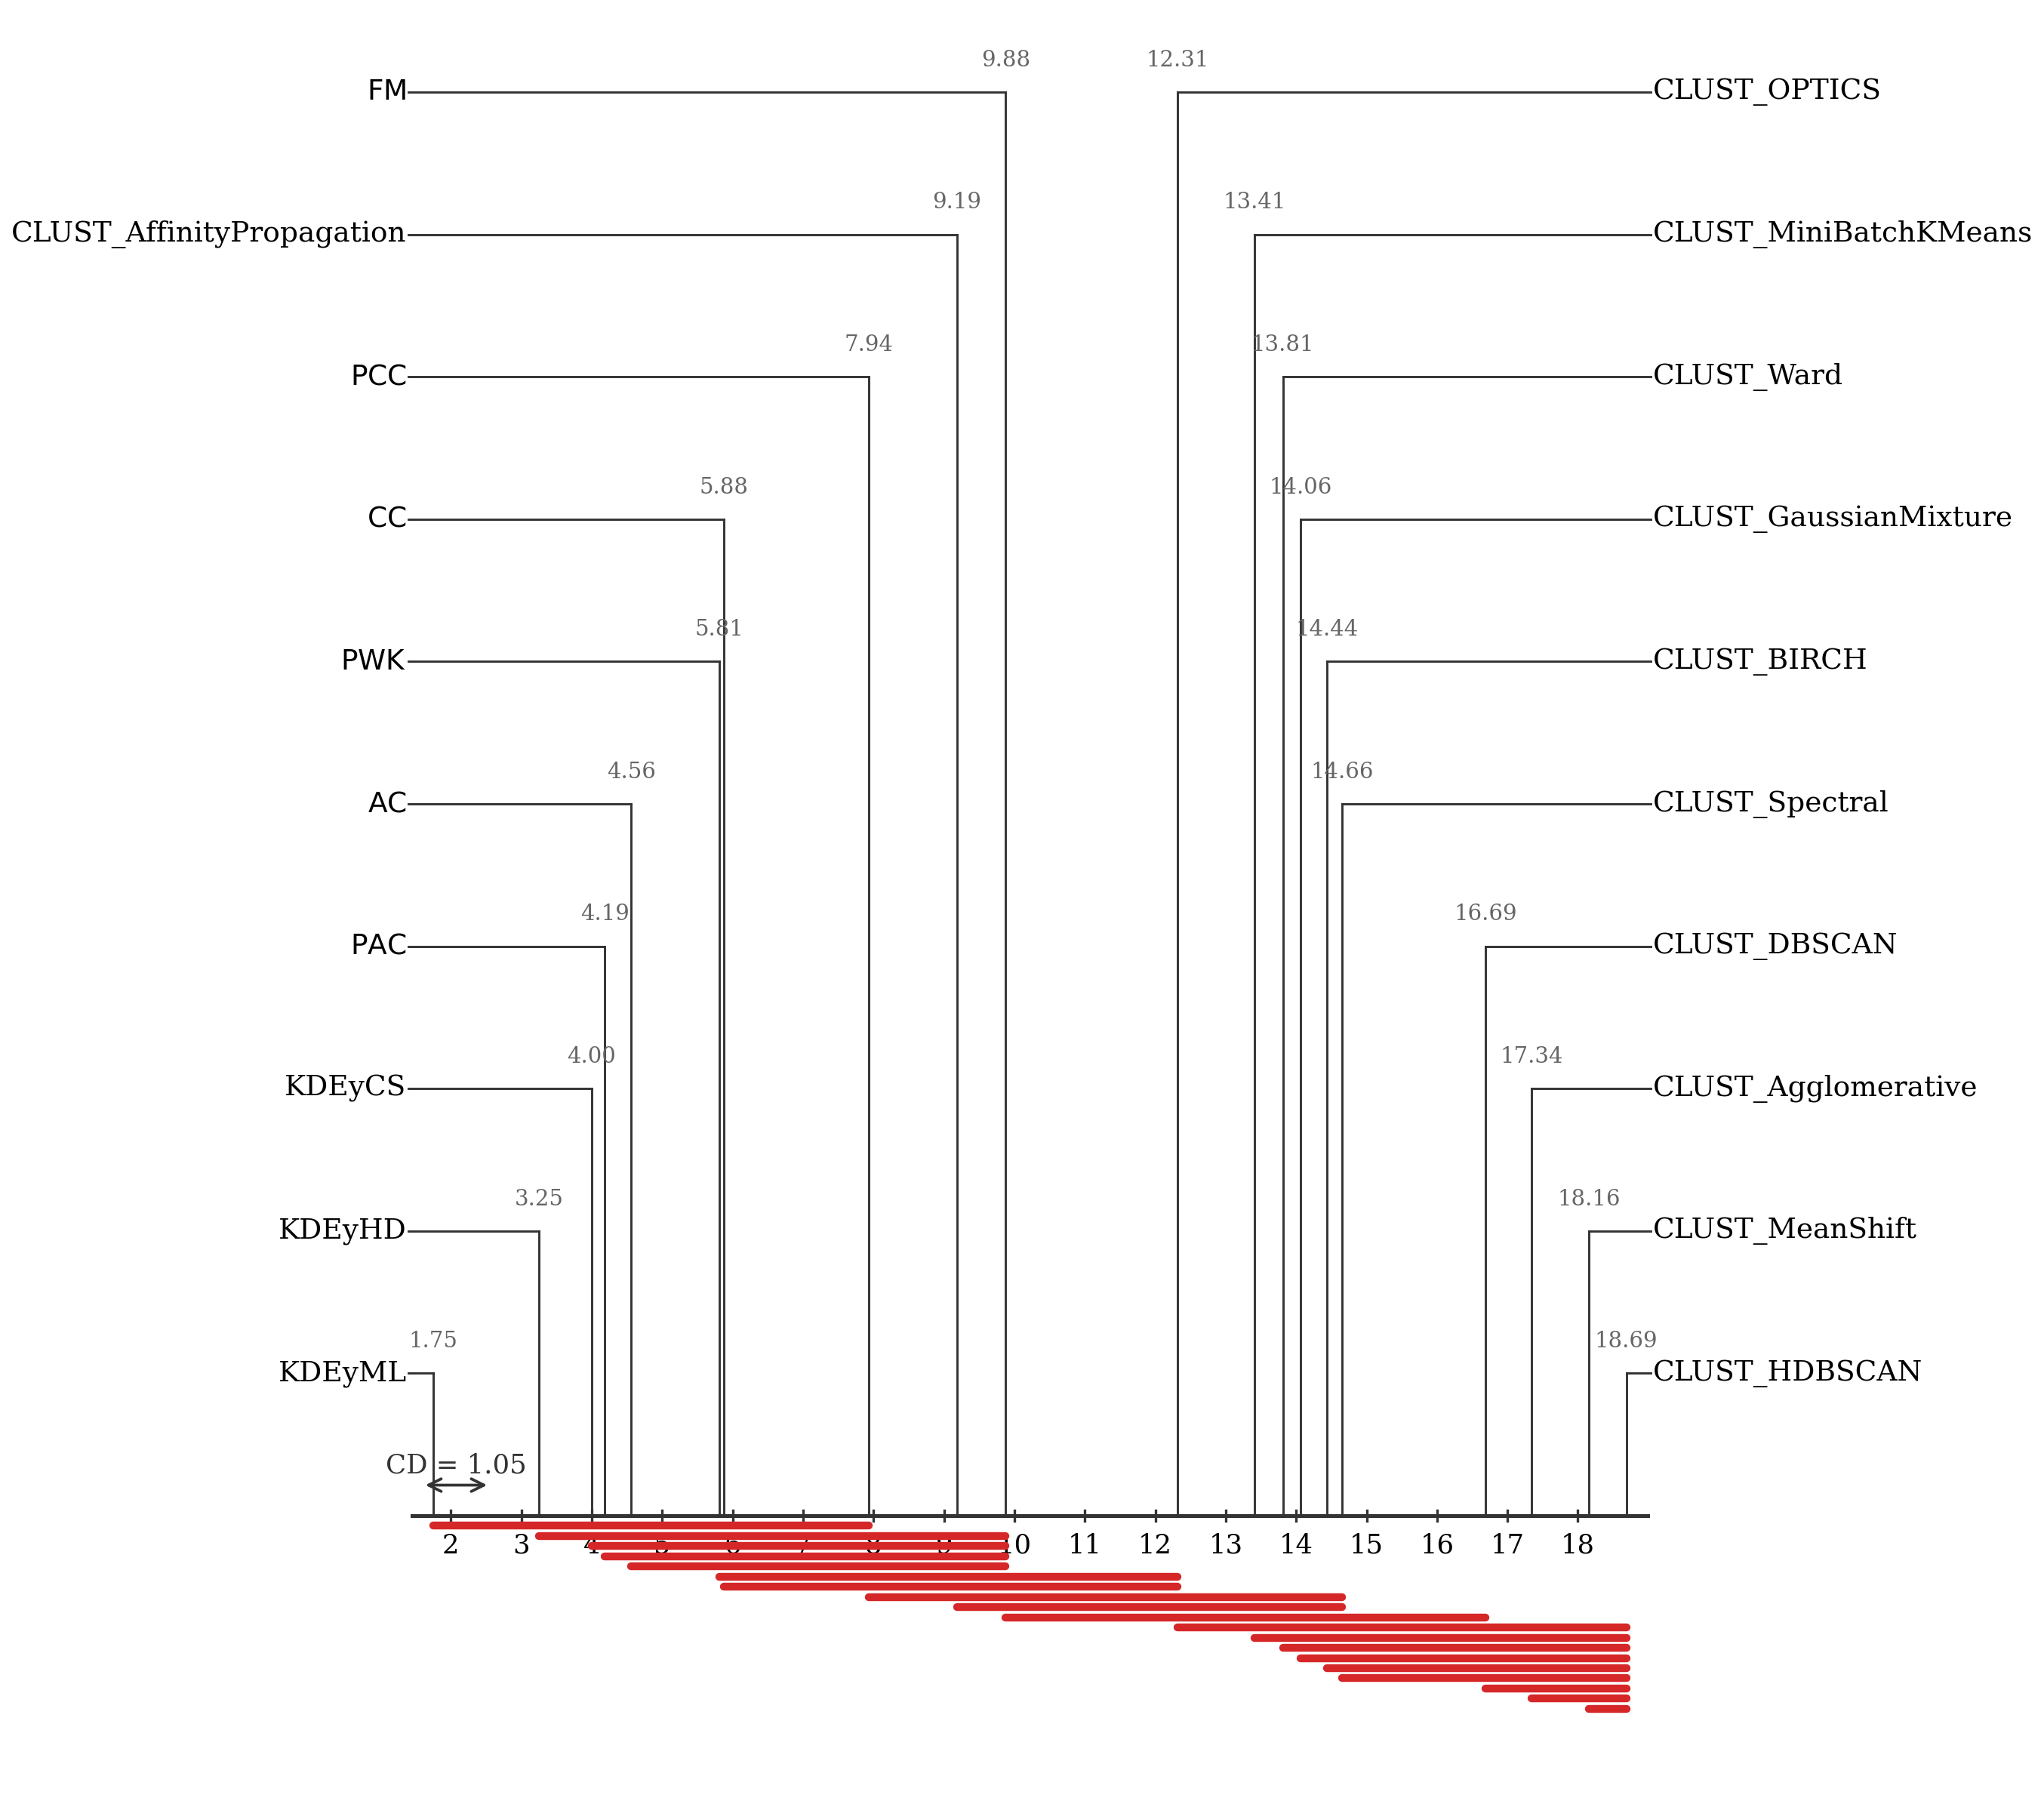

In [7]:
"""
Critical Difference Diagram — Friedman + Nemenyi post-hoc
Input: tabela_erros_medios.csv
       columns: dataset, n_classes_original, <method1>, <method2>, ...

Dependencies:
    pip install scikit-posthocs Orange3   (or just scikit-posthocs)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

# ============================================================
# CONFIG
# ============================================================
CSV_PATH          = "tabela_erros_medios.csv"
N_REPLICATIONS    = 50       # repetições por dataset
ALPHA             = 0.05
CD_LINE_COLOR     = "#333333"
HIGHLIGHT_COLOR   = "#d62728"   # grupos sem diferença significativa

# ============================================================
# PUBLICATION STYLE  (same as boxplot)
# ============================================================
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size":        10,
    "axes.labelsize":   10,
    "figure.dpi":       300,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
    "savefig.pad_inches": 0.05,
})

# ============================================================
# DISPLAY LABELS
# ============================================================
label_map = {
    "SSQML":     r"$\mathrm{SSQML}$",
    "SSQML_ISO": r"$\mathrm{SSQML}_\mathrm{ISO}$",
    "SSQML_RF":  r"$\mathrm{SSQML}_\mathrm{RF}$",
    "EMQ_BCTS":  r"$\mathrm{EMQ}_\mathrm{BCTS}$",
    "EMQ":       r"$\mathrm{EMQ}$",
    "KDEy_ML":   r"$\mathrm{KDEy}_\mathrm{ML}$",
    "KDEy_CS":   r"$\mathrm{KDEy}_\mathrm{CS}$",
    "KDEy_HD":   r"$\mathrm{KDEy}_\mathrm{HD}$",
    "AC":        r"$\mathrm{AC}$",
    "CC":        r"$\mathrm{CC}$",
    "FM":        r"$\mathrm{FM}$",
    "PAC":       r"$\mathrm{PAC}$",
    "PCC":       r"$\mathrm{PCC}$",
    "PWK":       r"$\mathrm{PWK}$",
}

# ============================================================
# LOAD & PREPARE
# ============================================================
df_raw = pd.read_csv(CSV_PATH)

# Drop non-method columns
meta_cols = ["dataset", "n_classes_original"]
methods   = [c for c in df_raw.columns if c not in meta_cols]

# Error matrix: rows = datasets, cols = methods
error_mat = df_raw[methods].values          # shape (n_datasets, n_methods)
n_datasets, n_methods = error_mat.shape

# ============================================================
# FRIEDMAN TEST
# ============================================================
stat, p_friedman = friedmanchisquare(*[error_mat[:, j] for j in range(n_methods)])
print(f"Friedman: χ²={stat:.4f}, p={p_friedman:.4e}")
if p_friedman >= ALPHA:
    print("WARNING: Friedman test not significant — CD diagram may be misleading.")

# ============================================================
# AVERAGE RANKS
# ============================================================
# Rank within each dataset (lower error = lower rank = better)
ranks_mat = pd.DataFrame(error_mat, columns=methods).rank(axis=1, method="average")
avg_ranks = ranks_mat.mean(axis=0).sort_values()

# ============================================================
# NEMENYI POST-HOC
# ============================================================
# scikit_posthocs expects (n_datasets × n_methods) DataFrame
p_nemenyi = sp.posthoc_nemenyi_friedman(
    pd.DataFrame(error_mat, columns=methods)
)

# ============================================================
# CRITICAL DIFFERENCE  (Nemenyi, two-tailed)
# Using the standard formula: CD = q_alpha * sqrt(k(k+1) / (6*N))
# where N = n_datasets * N_REPLICATIONS (effective sample size)
# ============================================================
from scipy.stats import studentized_range

k = n_methods
N = n_datasets * N_REPLICATIONS

# q_alpha for Nemenyi at alpha=0.05, infinite df
# Standard table values (two-tailed, alpha=0.05):
q_alpha_table = {2: 1.960, 3: 2.344, 4: 2.569, 5: 2.728,
                 6: 2.850, 7: 2.949, 8: 3.031, 9: 3.102,
                 10: 3.164, 11: 3.219, 12: 3.268, 13: 3.313,
                 14: 3.354, 15: 3.391, 16: 3.426, 20: 3.561}
q_alpha = q_alpha_table.get(k, 3.5)   # fallback for k > 20

CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))
print(f"CD = {CD:.4f}  (k={k}, N={N}, q={q_alpha})")

# ============================================================
# DRAW CD DIAGRAM
# ============================================================
sorted_methods = avg_ranks.index.tolist()
sorted_ranks   = avg_ranks.values.tolist()
n = len(sorted_methods)

# Split: left half on left side, right half on right side
half = n // 2
left_methods  = sorted_methods[:half]
right_methods = sorted_methods[half:][::-1]   # reversed so best is at top on right

fig_w = 7.2
fig_h = 0.45 * n + 1.2
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.set_xlim(avg_ranks.min() - 0.5, avg_ranks.max() + 0.5)
ax.axis("off")

rank_min = avg_ranks.min() - 0.3
rank_max = avg_ranks.max() + 0.3

# ---- Axis line ----
ax.plot([rank_min, rank_max], [1, 1], color=CD_LINE_COLOR, lw=1.2, zorder=3)

# Tick marks on axis
for r in np.arange(np.ceil(rank_min), np.floor(rank_max) + 1):
    ax.plot([r, r], [0.97, 1.03], color=CD_LINE_COLOR, lw=0.8, zorder=3)
    ax.text(r, 0.90, str(int(r)), ha="center", va="top", fontsize=8.5)

# ---- CD bar ----
cd_x_start = rank_min + 0.1
ax.annotate("", xy=(cd_x_start + CD, 1.18), xytext=(cd_x_start, 1.18),
            arrowprops=dict(arrowstyle="<->", color=CD_LINE_COLOR, lw=0.9))
ax.text(cd_x_start + CD / 2, 1.22, f"CD = {CD:.2f}",
        ha="center", va="bottom", fontsize=8.5, color=CD_LINE_COLOR)

# ---- Vertical spacing for labels ----
y_top   = 1.0
y_step  = (fig_h - 1.8) / max(half, len(right_methods))

def y_for(idx, side_list):
    return y_top + (idx + 1) * y_step

# ---- Left labels ----
for i, m in enumerate(left_methods):
    r   = avg_ranks[m]
    y   = y_top + (i + 1) * y_step
    lbl = label_map.get(m, m)
    ax.plot([r, r],         [1, y],  color=CD_LINE_COLOR, lw=0.7, zorder=2)
    ax.plot([r, rank_min - 0.05], [y, y], color=CD_LINE_COLOR, lw=0.7, zorder=2)
    ax.text(rank_min - 0.08, y, lbl, ha="right", va="center", fontsize=9)
    ax.text(r, y + y_step * 0.15, f"{r:.2f}", ha="center", va="bottom", fontsize=7,
            color="#666666")

# ---- Right labels ----
for i, m in enumerate(right_methods):
    r   = avg_ranks[m]
    y   = y_top + (i + 1) * y_step
    lbl = label_map.get(m, m)
    ax.plot([r, r],          [1, y],  color=CD_LINE_COLOR, lw=0.7, zorder=2)
    ax.plot([r, rank_max + 0.05], [y, y], color=CD_LINE_COLOR, lw=0.7, zorder=2)
    ax.text(rank_max + 0.08, y, lbl, ha="left", va="center", fontsize=9)
    ax.text(r, y + y_step * 0.15, f"{r:.2f}", ha="center", va="bottom", fontsize=7,
            color="#666666")

# ---- Cliques (groups not significantly different) ----
# Draw a thick horizontal bar connecting methods within CD of each other
# that are NOT significantly different per Nemenyi (p >= ALPHA)
drawn = set()
bar_y_base = 1.0
bar_y_offset = -0.06
bar_level = 0

for i in range(n):
    m_i = sorted_methods[i]
    group = [m_i]
    for j in range(i + 1, n):
        m_j = sorted_methods[j]
        if p_nemenyi.loc[m_i, m_j] >= ALPHA:
            group.append(m_j)
    if len(group) < 2:
        continue
    key = tuple(group)
    if key in drawn:
        continue
    # Check that ALL pairs in group are non-significant
    all_ns = all(p_nemenyi.loc[a, b] >= ALPHA
                 for a in group for b in group if a != b)
    if not all_ns:
        continue
    drawn.add(key)
    r_start = avg_ranks[group[0]]
    r_end   = avg_ranks[group[-1]]
    y_bar   = bar_y_base + bar_y_offset * (bar_level + 1)
    ax.plot([r_start, r_end], [y_bar, y_bar],
            color=HIGHLIGHT_COLOR, lw=2.5, solid_capstyle="round", zorder=4)
    bar_level += 1

ax.set_title("")
plt.tight_layout()
plt.savefig("critical_difference.pdf")
plt.savefig("critical_difference.png", dpi=300)
print("Saved: critical_difference.pdf / .png")

                           meanrank    median       mad  ci_lower  ci_upper  \
KDEyML                      1.75000  0.005157  0.003527  0.001173  0.092353   
KDEyHD                      3.25000  0.006799  0.002383  0.003605  0.068195   
KDEyCS                      4.00000  0.007607  0.003984  0.003364  0.058318   
PAC                         4.18750  0.008834  0.005896  0.002325  0.096513   
AC                          4.56250  0.010844  0.008143  0.001642  0.106654   
PWK                         5.81250  0.041159  0.036555  0.001525  0.164927   
CC                          5.87500  0.028462  0.025728  0.001664  0.163007   
PCC                         7.93750  0.051893  0.038363  0.005947  0.172522   
CLUST_AffinityPropagation   9.18750  0.085418  0.070739  0.006088  0.225868   
FM                          9.87500  0.043763  0.025332  0.012725  0.239718   
CLUST_OPTICS               12.31250  0.124883  0.064151  0.007677  0.450639   
CLUST_MiniBatchKMeans      13.40625  0.170405  0.088

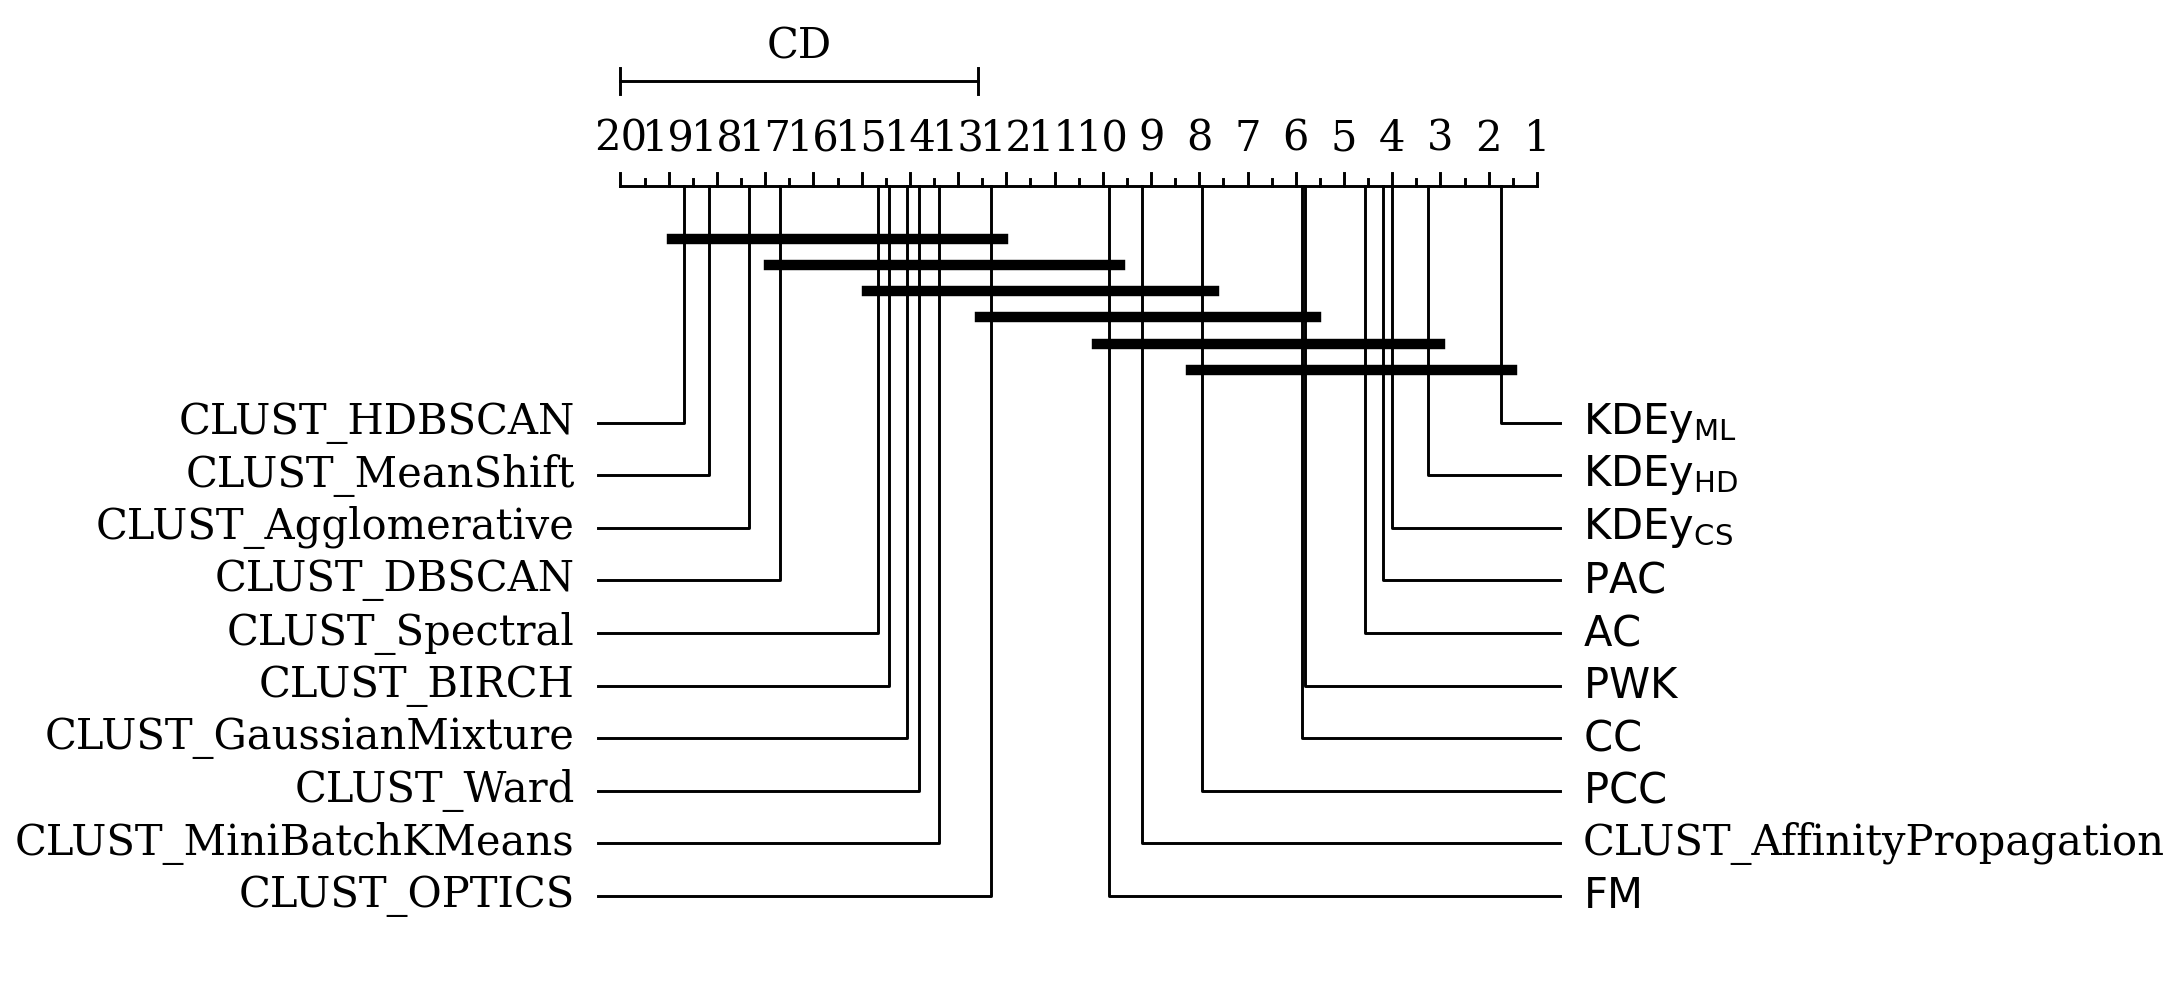

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from autorank import autorank, plot_stats

# ============================================================
# CONFIG
# ============================================================
CSV_PATH = "tabela_erros_medios.csv"
ALPHA    = 0.05

# ============================================================
# PUBLICATION STYLE 
# ============================================================
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size":        10,
    "axes.labelsize":   10,
    "figure.dpi":       300,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
    "savefig.pad_inches": 0.05,
})

# Dicionário estrito mapeando as colunas exatas do CSV para LaTeX
label_map = {
    "QMoSS":     r"$\mathrm{SSQML}$",
    "QMoSS_ISO": r"$\mathrm{SSQML}_\mathrm{ISO}$",
    "QMoSS_RF":  r"$\mathrm{SSQML}_\mathrm{RF}$",
    "EMQ_BCTS":  r"$\mathrm{EMQ}_\mathrm{BCTS}$",
    "EMQ":       r"$\mathrm{EMQ}$",
    "KDEyML":    r"$\mathrm{KDEy}_\mathrm{ML}$",
    "KDEyCS":    r"$\mathrm{KDEy}_\mathrm{CS}$",
    "KDEyHD":    r"$\mathrm{KDEy}_\mathrm{HD}$",
    "AC":        r"$\mathrm{AC}$",
    "CC":        r"$\mathrm{CC}$",
    "FM":        r"$\mathrm{FM}$",
    "PAC":       r"$\mathrm{PAC}$",
    "PCC":       r"$\mathrm{PCC}$",
    "PWK":       r"$\mathrm{PWK}$",
}

# ============================================================
# LOAD & PREPARE
# ============================================================
df_raw = pd.read_csv(CSV_PATH)

# Separar colunas de metadados dos métodos estatísticos
meta_cols = ["dataset", "n_classes_original"]
methods   = [c for c in df_raw.columns if c not in meta_cols]

# Limpar qualquer linha contendo NaNs nas colunas dos métodos
df_clean = df_raw.dropna(subset=methods).copy()

if len(df_clean) < len(df_raw):
    print(f"Aviso: {len(df_raw) - len(df_clean)} datasets removidos por conterem NaNs.")

# Filtramos apenas a matriz com os métodos
df_methods = df_clean[methods]

# ============================================================
# EXECUTA TESTES E CRITICAL DIFFERENCE (AUTORANK ENGINE)
# ============================================================
# order='ascending': indica que o erro menor é o melhor (Ranks baixos = melhores)
result = autorank(df_methods, alpha=ALPHA, verbose=False, order='ascending')

# Exibe o relatório estatístico completo detalhado no terminal
print("\n--- Relatório Estatístico Completo ---")
print(result)

# ============================================================
# DESENHA O DIAGRAMA DE DIFERENÇA CRÍTICA PERFEITO
# ============================================================
# Cria uma figura limpa nas proporções ideais
fig, ax = plt.subplots(figsize=(7.2, 3.5))

# O autorank plota automaticamente o diagrama CD sem cruzamento de linhas
plot_stats(result, ax=ax)

# --- Ajuste dos rótulos para o formato elegante em LaTeX ---
# Pegamos as strings de texto que o autorank colocou no gráfico e aplicamos o label_map
for text_obj in ax.texts:
    txt = text_obj.get_text()
    if txt in label_map:
        text_obj.set_text(label_map[txt])

# Remove decorações desnecessárias da caixa exterior se existirem
ax.set_title("")
plt.tight_layout()

# Salvar os outputs finais em nível de publicação científica
plt.savefig("critical_difference_perfect.pdf")
plt.savefig("critical_difference_perfect.png", dpi=300)
print("\nGráfico gerado com sucesso: critical_difference_perfect.pdf / .png")

Friedman: χ²=265.3950, p=2.3251e-45


CD = 1.0534  (k=20, N=800, q=3.561)
Saved: critical_difference.pdf / .png


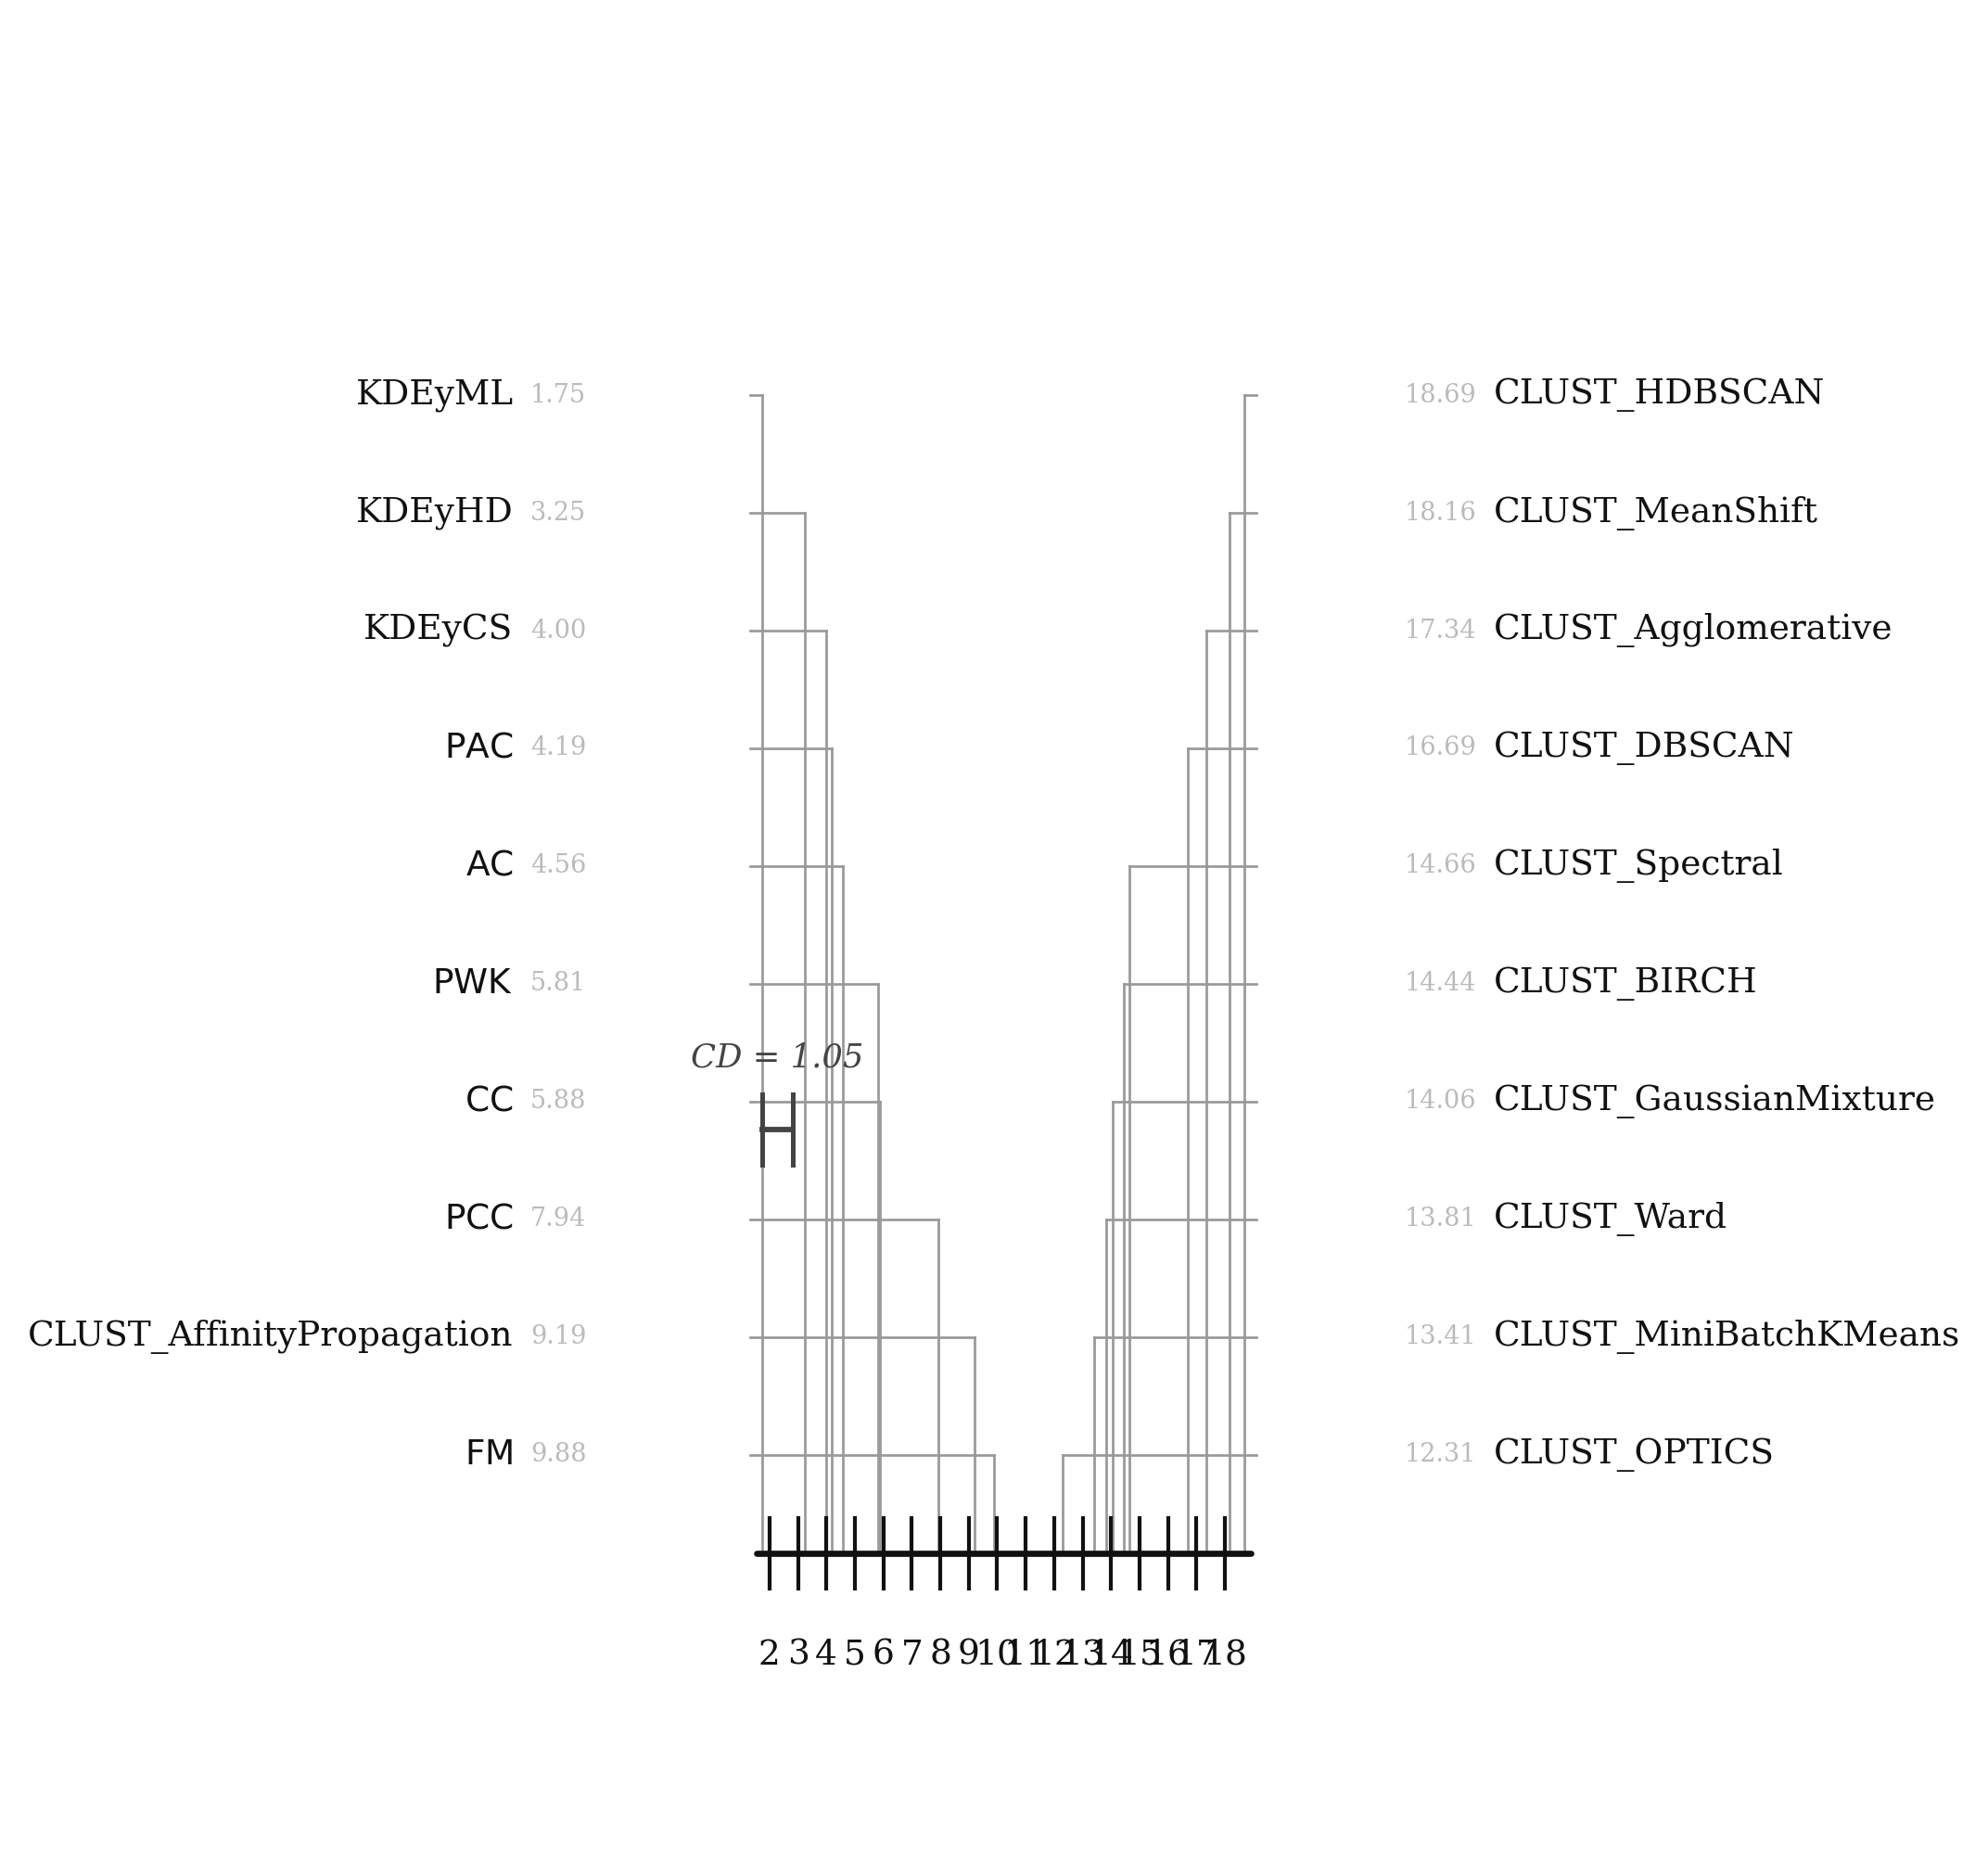

In [9]:
"""
Critical Difference Diagram — Friedman + Nemenyi post-hoc
=========================================================
Input:  tabela_erros_medios.csv
        columns: dataset, n_classes_original, <method1>, <method2>, ...

Output: critical_difference.pdf / .png

Dependencies:
    pip install scikit-posthocs pandas numpy scipy matplotlib
"""

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

# ============================================================
# CONFIG
# ============================================================
CSV_PATH       = "tabela_erros_medios.csv"
N_REPLICATIONS = 50        # replications per dataset (used for CD formula)
ALPHA          = 0.05

# Color palette
AXIS_COLOR    = "#111111"
CONN_COLOR    = "#999999"
RANK_COLOR    = "#bbbbbb"
CD_COLOR      = "#444444"

# ============================================================
# PUBLICATION STYLE
# ============================================================
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size":          10,
    "figure.dpi":         300,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.10,
})

# ============================================================
# DISPLAY LABELS  (add/edit as needed)
# ============================================================
label_map = {
    "SSQML":     r"$\mathrm{SSQML}$",
    "SSQML_ISO": r"$\mathrm{SSQML}_\mathrm{ISO}$",
    "SSQML_RF":  r"$\mathrm{SSQML}_\mathrm{RF}$",
    "EMQ_BCTS":  r"$\mathrm{EMQ}_\mathrm{BCTS}$",
    "EMQ":       r"$\mathrm{EMQ}$",
    "KDEy_ML":   r"$\mathrm{KDEy}_\mathrm{ML}$",
    "KDEy_CS":   r"$\mathrm{KDEy}_\mathrm{CS}$",
    "KDEy_HD":   r"$\mathrm{KDEy}_\mathrm{HD}$",
    "AC":        r"$\mathrm{AC}$",
    "CC":        r"$\mathrm{CC}$",
    "FM":        r"$\mathrm{FM}$",
    "PAC":       r"$\mathrm{PAC}$",
    "PCC":       r"$\mathrm{PCC}$",
    "PWK":       r"$\mathrm{PWK}$",
}

# ============================================================
# LOAD & PREPARE
# ============================================================
df_raw    = pd.read_csv(CSV_PATH)
meta_cols = ["dataset", "n_classes_original"]
methods   = [c for c in df_raw.columns if c not in meta_cols]

error_mat             = df_raw[methods].values
n_datasets, n_methods = error_mat.shape

# ============================================================
# FRIEDMAN TEST
# ============================================================
stat, p_friedman = friedmanchisquare(*[error_mat[:, j] for j in range(n_methods)])
print(f"Friedman: χ²={stat:.4f}, p={p_friedman:.4e}")
if p_friedman >= ALPHA:
    print("WARNING: Friedman test not significant — CD diagram may be misleading.")

# ============================================================
# AVERAGE RANKS  (lower error = lower rank = better)
# ============================================================
ranks_mat = pd.DataFrame(error_mat, columns=methods).rank(axis=1, method="average")
avg_ranks = ranks_mat.mean(axis=0).sort_values()

# ============================================================
# NEMENYI POST-HOC
# ============================================================
p_nemenyi = sp.posthoc_nemenyi_friedman(
    pd.DataFrame(error_mat, columns=methods)
)

# ============================================================
# CRITICAL DIFFERENCE
# ============================================================
q_alpha_table = {
     2: 1.960,  3: 2.344,  4: 2.569,  5: 2.728,
     6: 2.850,  7: 2.949,  8: 3.031,  9: 3.102,
    10: 3.164, 11: 3.219, 12: 3.268, 13: 3.313,
    14: 3.354, 15: 3.391, 16: 3.426, 20: 3.561,
}
k       = n_methods
N       = n_datasets * N_REPLICATIONS
q_alpha = q_alpha_table.get(k, 3.5)
CD      = q_alpha * np.sqrt(k * (k + 1) / (6 * N))
print(f"CD = {CD:.4f}  (k={k}, N={N}, q={q_alpha})")

sorted_methods = avg_ranks.index.tolist()
n = len(sorted_methods)

# ============================================================
# LAYOUT GEOMETRY
# ============================================================
half          = n // 2
left_methods  = sorted_methods[:half]           # best ranks → left labels
right_methods = sorted_methods[half:][::-1]     # worst ranks → right labels (top=best)

rank_vals = avg_ranks.values.tolist()
rank_min  = min(rank_vals)
rank_max  = max(rank_vals)
rank_span = rank_max - rank_min

# Data-coordinate system: x in [0, 10], y in [-1, 1]
# The rank axis always occupies X_LO → X_HI regardless of rank range
X_LO   = 2.6
X_HI   = 7.4
AXIS_W = X_HI - X_LO   # fixed visual width

def r2x(r):
    """Map average rank value to x data coordinate."""
    return X_LO + (r - rank_min) / rank_span * AXIS_W

n_left  = len(left_methods)
n_right = len(right_methods)

FIG_W = 7.2
FIG_H = max(4.2, 0.46 * max(n_left, n_right) + 2.2)

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.set_xlim(0, 10)
ax.set_ylim(-0.20, 1.08)
ax.axis("off")

y_axis = 0.0

# ── rank axis line ────────────────────────────────────────────
ax.plot([X_LO - 0.06, X_HI + 0.06], [y_axis, y_axis],
        color=AXIS_COLOR, lw=1.6, zorder=3, solid_capstyle="round")

# integer ticks + labels below axis
tick_vals = range(int(np.ceil(rank_min)), int(np.floor(rank_max)) + 1)
for r in tick_vals:
    xr = r2x(r)
    ax.plot([xr, xr], [y_axis - 0.025, y_axis + 0.025],
            color=AXIS_COLOR, lw=1.0, zorder=3)
    ax.text(xr, y_axis - 0.06, str(r),
            ha="center", va="top", fontsize=9, color=AXIS_COLOR)

# ── CD bar (upper-left, above the axis) ───────────────────────
cd_x0 = X_LO
cd_x1 = X_LO + CD / rank_span * AXIS_W
cd_y  = 0.30
cap_h = 0.025

ax.plot([cd_x0, cd_x1], [cd_y, cd_y], color=CD_COLOR, lw=1.4, zorder=4)
for xc in [cd_x0, cd_x1]:
    ax.plot([xc, xc], [cd_y - cap_h, cd_y + cap_h],
            color=CD_COLOR, lw=1.2, zorder=4)
ax.text((cd_x0 + cd_x1) / 2, cd_y + cap_h + 0.015,
        f"CD = {CD:.2f}", ha="center", va="bottom",
        fontsize=8.5, color=CD_COLOR, fontstyle="italic")

# ── label y-positions (evenly spaced above axis) ──────────────
y_top = 0.82
y_bot = 0.07

def even_ys(count):
    if count == 1:
        return [(y_top + y_bot) / 2]
    step = (y_top - y_bot) / (count - 1)
    return [y_top - i * step for i in range(count)]

left_ys  = even_ys(n_left)
right_ys = even_ys(n_right)

X_LEFT_LBL  = 0.12    # right-aligned anchor for left labels
X_RIGHT_LBL = 9.88    # left-aligned anchor for right labels
X_LEFT_END  = X_LO - 0.12   # horizontal connector ends
X_RIGHT_END = X_HI + 0.12

def draw_method(m, y_lbl, side):
    r   = avg_ranks[m]
    xr  = r2x(r)
    lbl = label_map.get(m, m)

    x_end   = X_LEFT_END  if side == "left"  else X_RIGHT_END
    x_lbl   = X_LEFT_LBL  if side == "left"  else X_RIGHT_LBL
    ha      = "right"      if side == "left"  else "left"
    rank_ha = "left"       if side == "left"  else "right"
    rank_x  = x_lbl + (0.17 if side == "left" else -0.17)

    # vertical connector (rank → label height)
    ax.plot([xr, xr], [y_axis, y_lbl], color=CONN_COLOR, lw=0.65, zorder=2)
    # horizontal connector (rank → margin)
    ax.plot([xr, x_end], [y_lbl, y_lbl], color=CONN_COLOR, lw=0.65, zorder=2)

    # method label
    ax.text(x_lbl, y_lbl, lbl, ha=ha, va="center",
            fontsize=9, color=AXIS_COLOR)

    # rank value (small, muted, outward from label)
    ax.text(rank_x, y_lbl, f"{r:.2f}",
            ha=rank_ha, va="center", fontsize=6.5, color=RANK_COLOR)

for m, y in zip(left_methods, left_ys):
    draw_method(m, y, "left")
for m, y in zip(right_methods, right_ys):
    draw_method(m, y, "right")


# ── save ──────────────────────────────────────────────────────
plt.tight_layout()
plt.savefig("critical_difference.pdf")
plt.savefig("critical_difference.png", dpi=300)
print("Saved: critical_difference.pdf / .png")

Métodos:
 - AC
 - CC
 - CLUST_AffinityPropagation
 - CLUST_Agglomerative
 - CLUST_BIRCH
 - CLUST_DBSCAN
 - CLUST_GaussianMixture
 - CLUST_HDBSCAN
 - CLUST_MeanShift
 - CLUST_MiniBatchKMeans
 - CLUST_OPTICS
 - CLUST_Spectral
 - CLUST_Ward
 - FM
 - KDEyCS
 - KDEyHD
 - KDEyML
 - PAC
 - PCC
 - PWK

FRIEDMAN TEST
Statistic = 265.395002
P-value   = 0.0000000000

AVERAGE RANKS
KDEyML                        1.75000
KDEyHD                        3.25000
KDEyCS                        4.00000
PAC                           4.18750
AC                            4.56250
PWK                           5.81250
CC                            5.87500
PCC                           7.93750
CLUST_AffinityPropagation     9.18750
FM                            9.87500
CLUST_OPTICS                 12.31250
CLUST_MiniBatchKMeans        13.40625
CLUST_Ward                   13.81250
CLUST_GaussianMixture        14.06250
CLUST_BIRCH                  14.43750
CLUST_Spectral               14.65625
CLUST_DBSCAN       

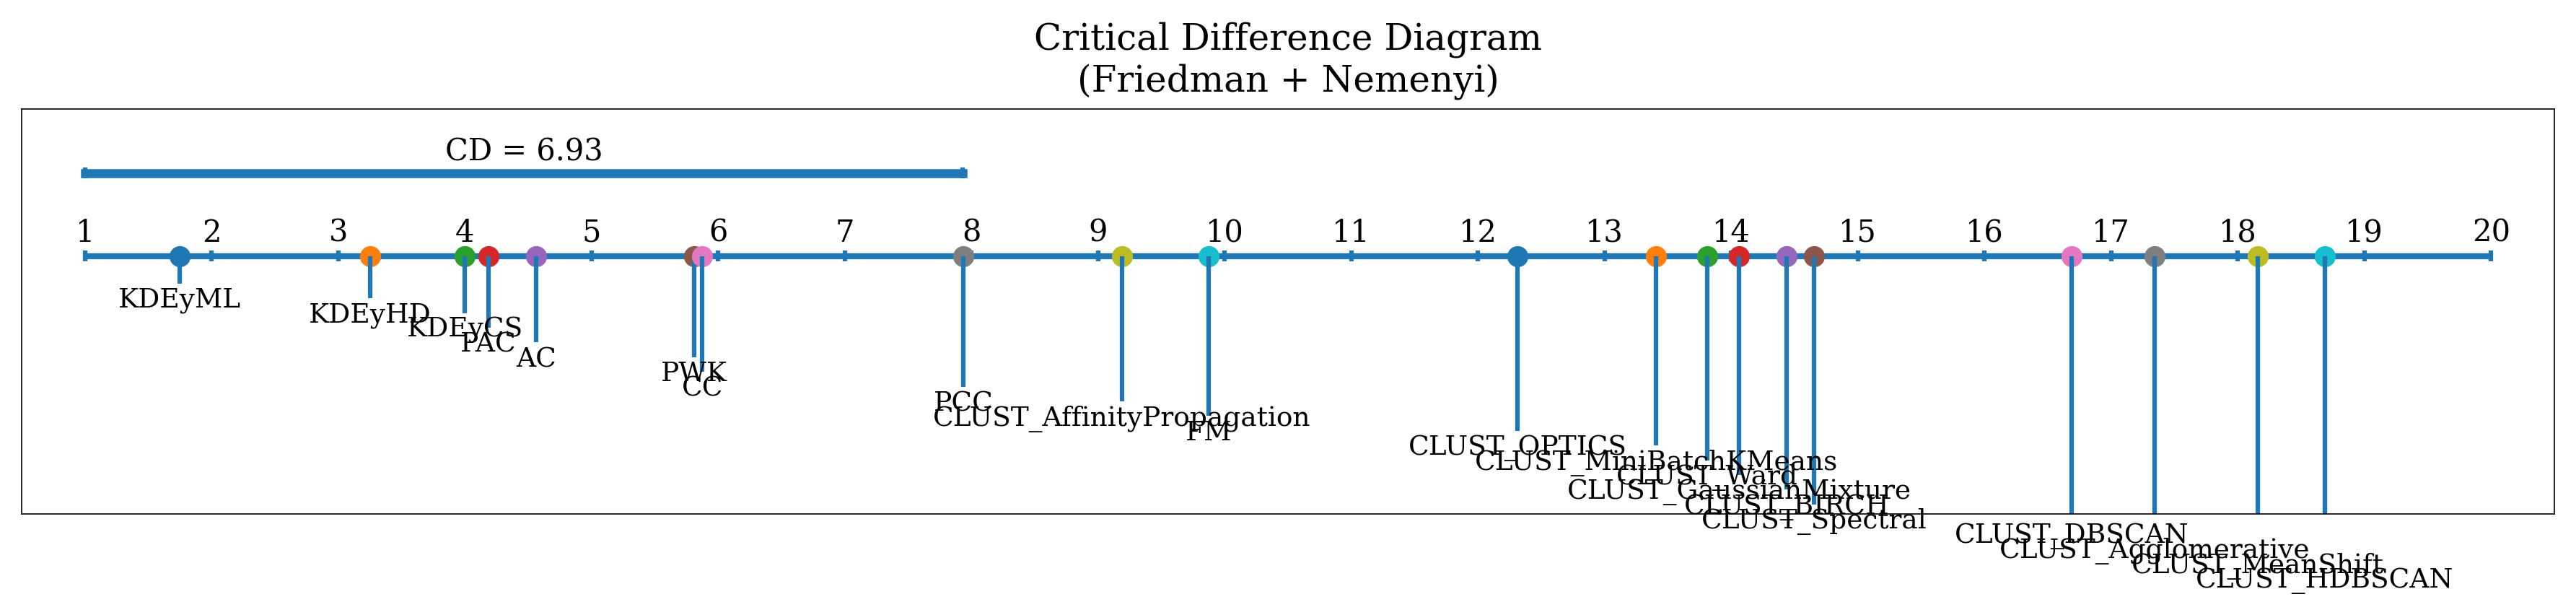

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import friedmanchisquare
from scipy.stats import rankdata

import scikit_posthocs as sp

# ============================================================
# CONFIG
# ============================================================

CSV_PATH = "tabela_erros_medios.csv"

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(CSV_PATH)

# colunas que não são métodos
META_COLS = ["dataset", "n_classes_original"]

methods = [c for c in df.columns if c not in META_COLS]

print("Métodos:")
for m in methods:
    print(" -", m)

# ============================================================
# FRIEDMAN TEST
# ============================================================

friedman_input = [df[m].values for m in methods]

stat, p = friedmanchisquare(*friedman_input)

print("\n==============================")
print("FRIEDMAN TEST")
print("==============================")
print(f"Statistic = {stat:.6f}")
print(f"P-value   = {p:.10f}")

# ============================================================
# COMPUTE RANKS
# ============================================================
# menor erro = melhor rank

ranks = df[methods].apply(
    lambda row: rankdata(row, method='average'),
    axis=1,
    result_type='expand'
)

ranks.columns = methods

avg_ranks = ranks.mean()

print("\n==============================")
print("AVERAGE RANKS")
print("==============================")

print(avg_ranks.sort_values())

# ============================================================
# NEMENYI POST-HOC
# ============================================================

nemenyi = sp.posthoc_nemenyi_friedman(df[methods])

print("\n==============================")
print("NEMENYI P-VALUES")
print("==============================")
print(nemenyi)

# ============================================================
# CRITICAL DIFFERENCE
# ============================================================

k = len(methods)      # métodos
N = len(df)           # datasets

# q_alpha para alpha=0.05
# Demsar (2006)
q_alpha = 3.314

CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))

print("\n==============================")
print("CRITICAL DIFFERENCE")
print("==============================")
print(f"CD = {CD:.4f}")

# ============================================================
# PLOT CD DIAGRAM
# ============================================================

avg_ranks_sorted = avg_ranks.sort_values()

fig, ax = plt.subplots(figsize=(12, 3))

y = 1

# linha principal
ax.hlines(y, 1, k, lw=2)

# ticks
for r in range(1, k + 1):
    ax.vlines(r, y - 0.03, y + 0.03)
    ax.text(r, y + 0.08, str(r),
            ha='center',
            fontsize=10)

# métodos
for i, (method, rank) in enumerate(avg_ranks_sorted.items()):

    offset = 0.15 + i * 0.08

    ax.plot(rank, y, 'o')

    ax.vlines(rank, y, y - offset)

    ax.text(
        rank,
        y - offset - 0.02,
        method,
        ha='center',
        va='top',
        fontsize=9
    )

# barra de CD
cd_start = 1
cd_end = cd_start + CD

ax.plot(
    [cd_start, cd_end],
    [1.45, 1.45],
    lw=3
)

ax.vlines(
    [cd_start, cd_end],
    1.42,
    1.48
)

ax.text(
    (cd_start + cd_end) / 2,
    1.52,
    f"CD = {CD:.2f}",
    ha='center'
)

ax.set_xlim(0.5, k + 0.5)
ax.set_ylim(-0.4, 1.8)

ax.set_xticks([])
ax.set_yticks([])

ax.set_title(
    "Critical Difference Diagram\n"
    "(Friedman + Nemenyi)"
)

plt.tight_layout()
plt.show()


FRIEDMAN
Statistic = 265.395002
P-value   = 0.00000000

Average ranks:
KDEyML                        1.75000
KDEyHD                        3.25000
KDEyCS                        4.00000
PAC                           4.18750
AC                            4.56250
PWK                           5.81250
CC                            5.87500
PCC                           7.93750
CLUST_AffinityPropagation     9.18750
FM                            9.87500
CLUST_OPTICS                 12.31250
CLUST_MiniBatchKMeans        13.40625
CLUST_Ward                   13.81250
CLUST_GaussianMixture        14.06250
CLUST_BIRCH                  14.43750
CLUST_Spectral               14.65625
CLUST_DBSCAN                 16.68750
CLUST_Agglomerative          17.34375
CLUST_MeanShift              18.15625
CLUST_HDBSCAN                18.68750
dtype: float64

Critical Difference = 6.9317
Saved: critical_difference_diagram.pdf
Saved: critical_difference_diagram.png


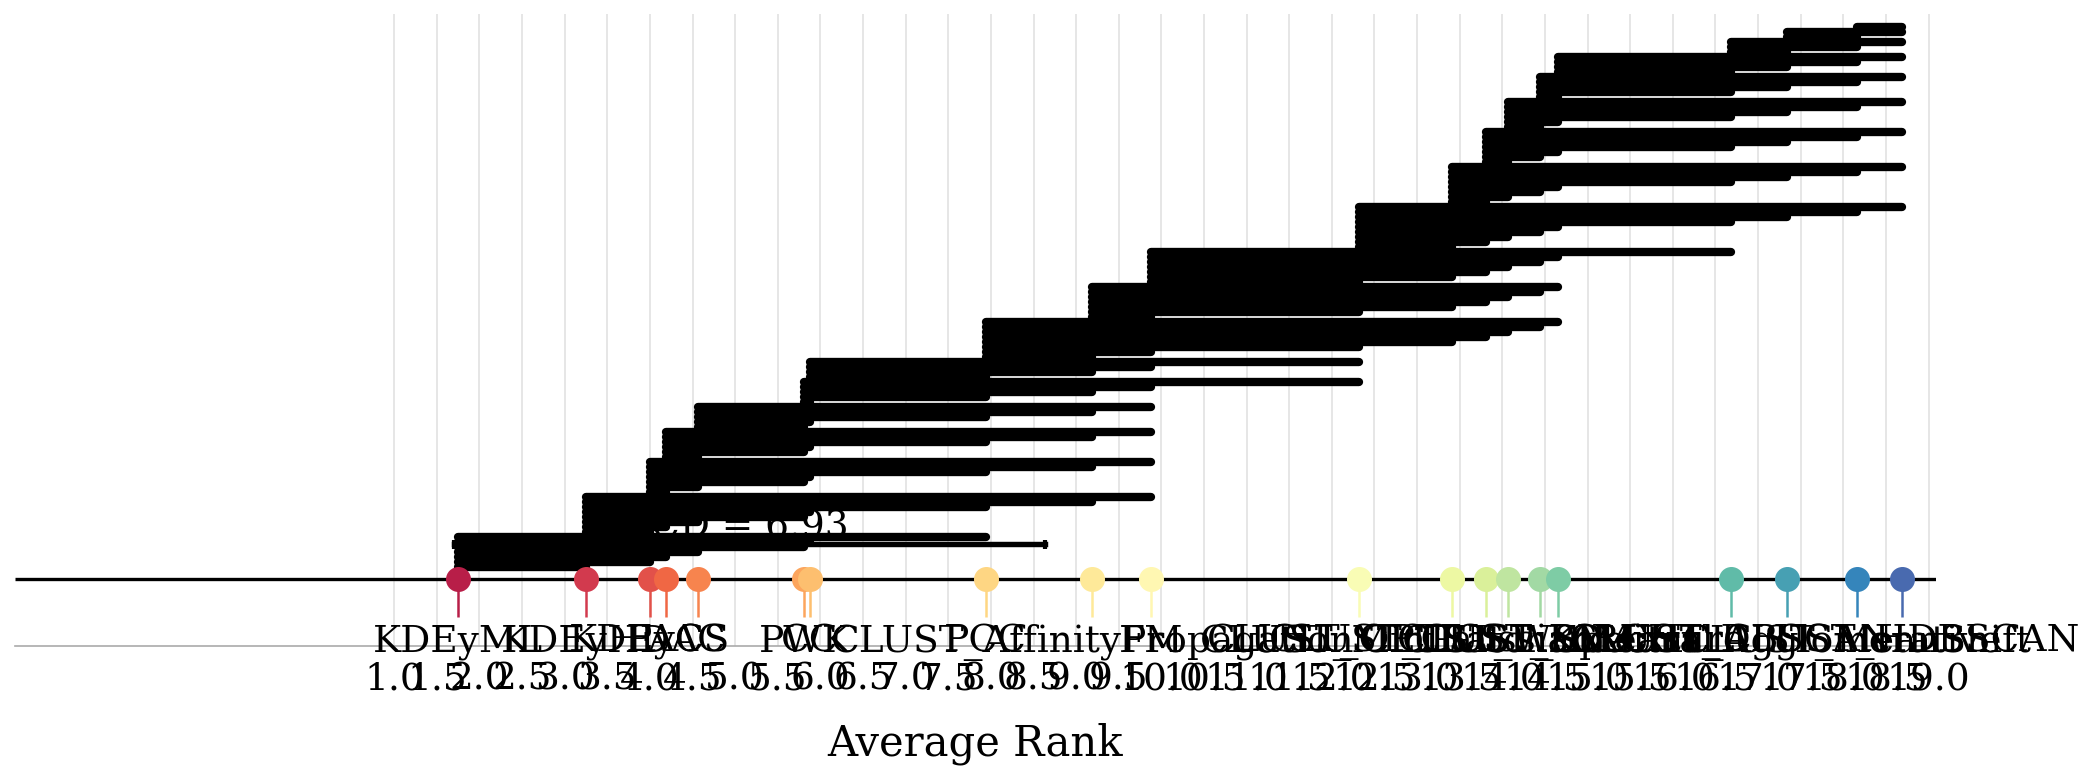

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import friedmanchisquare
from scipy.stats import rankdata
import scikit_posthocs as sp

# ============================================================
# CONFIG
# ============================================================

CSV_PATH = "tabela_erros_medios.csv"
ALPHA = 0.05

# ============================================================
# PUBLICATION STYLE
# ============================================================

plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size":          10,
    "axes.labelsize":     10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "axes.linewidth":     0.4,
    "xtick.major.width":  0.0,
    "ytick.major.width":  0.0,
    "xtick.minor.width":  0.0,
    "ytick.minor.width":  0.0,
    "xtick.major.size":   0.0,
    "ytick.major.size":   0.0,
    "xtick.minor.size":   0.0,
    "ytick.minor.size":   0.0,
    "axes.grid":          False,
    "figure.dpi":         300,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.05,
})

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(CSV_PATH)

meta_cols = ["dataset", "n_classes_original"]

methods = [c for c in df.columns if c not in meta_cols]

# ============================================================
# DISPLAY LABELS
# ============================================================

label_map = {
    "SSQML":     r"$\mathrm{SSQML}$",
    "SSQML_ISO": r"$\mathrm{SSQML}_\mathrm{ISO}$",
    "SSQML_RF":  r"$\mathrm{SSQML}_\mathrm{RF}$",
    "EMQ_BCTS":  r"$\mathrm{EMQ}_\mathrm{BCTS}$",
    "EMQ":       r"$\mathrm{EMQ}$",
    "KDEy_ML":   r"$\mathrm{KDEy}_\mathrm{ML}$",
    "KDEy_CS":   r"$\mathrm{KDEy}_\mathrm{CS}$",
    "KDEy_HD":   r"$\mathrm{KDEy}_\mathrm{HD}$",
}

# ============================================================
# FRIEDMAN
# ============================================================

friedman_input = [df[m].values for m in methods]

stat, pvalue = friedmanchisquare(*friedman_input)

print("\n==========================")
print("FRIEDMAN")
print("==========================")
print(f"Statistic = {stat:.6f}")
print(f"P-value   = {pvalue:.8f}")

# ============================================================
# RANKS
# ============================================================

ranks = df[methods].apply(
    lambda row: rankdata(row, method="average"),
    axis=1,
    result_type="expand"
)

ranks.columns = methods

avg_ranks = ranks.mean().sort_values()

print("\nAverage ranks:")
print(avg_ranks)

# ============================================================
# NEMENYI
# ============================================================

nemenyi = sp.posthoc_nemenyi_friedman(df[methods])

# ============================================================
# CRITICAL DIFFERENCE
# ============================================================

k = len(methods)
N = len(df)

# Demšar Table α=0.05
q_alpha = 3.314

CD = q_alpha * np.sqrt(k*(k+1)/(6*N))

print(f"\nCritical Difference = {CD:.4f}")

# ============================================================
# ORDER
# ============================================================

ordered_methods = avg_ranks.index.tolist()
ordered_ranks = avg_ranks.values

display_labels = [
    label_map.get(m, m)
    for m in ordered_methods
]

# ============================================================
# COLORS
# ============================================================

palette = sns.color_palette(
    "Spectral",
    n_colors=len(ordered_methods)
)

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(7.2, 2.8))

# ============================================================
# DYNAMIC LIMITS
# ============================================================

rank_min = ordered_ranks.min()
rank_max = ordered_ranks.max()

margin_left = max(CD * 0.75, 0.4)
margin_right = 0.4

xmin = rank_min - margin_left
xmax = rank_max + margin_right

# ============================================================
# MAIN AXIS
# ============================================================

ax.hlines(
    1,
    xmin,
    xmax,
    color="black",
    linewidth=0.8
)

# ============================================================
# METHODS
# ============================================================

for i, (method, rank) in enumerate(
    zip(ordered_methods, ordered_ranks)
):

    color = palette[i]

    ax.plot(
        rank,
        1,
        marker="o",
        markersize=5,
        color=color,
        zorder=3
    )

    ax.vlines(
        rank,
        1,
        0.55,
        linewidth=0.6,
        color=color
    )

    ax.text(
        rank,
        0.48,
        display_labels[i],
        ha="center",
        va="top",
        fontsize=9
    )

# ============================================================
# CD BAR
# ============================================================

cd_start = rank_min - 0.05
cd_end = cd_start + CD

ax.plot(
    [cd_start, cd_end],
    [1.42, 1.42],
    color="black",
    linewidth=1.3
)

ax.vlines(
    [cd_start, cd_end],
    1.37,
    1.47,
    color="black",
    linewidth=1.0
)

ax.text(
    (cd_start + cd_end) / 2,
    1.52,
    f"CD = {CD:.2f}",
    ha="center",
    fontsize=9
)

# ============================================================
# NON-SIGNIFICANT GROUPS
# ============================================================

level = 1.15

for i in range(k):

    for j in range(i + 1, k):

        p = nemenyi.loc[
            ordered_methods[i],
            ordered_methods[j]
        ]

        if p >= ALPHA:

            ax.plot(
                [ordered_ranks[i],
                 ordered_ranks[j]],
                [level, level],
                color="black",
                linewidth=2.0,
                solid_capstyle="round"
            )

            level += 0.06

# ============================================================
# AXIS STYLE
# ============================================================

ax.set_xlim(xmin, xmax)
ax.set_ylim(0.2, max(1.7, level + 0.1))

ax.set_xlabel("Average Rank", labelpad=6)
ax.set_ylabel("")

# ranks reais como escala
ax.set_xticks(
    np.arange(
        np.floor(rank_min),
        np.ceil(rank_max) + 0.5,
        0.5
    )
)

ax.set_yticks([])

ax.grid(
    axis="x",
    linewidth=0.4,
    alpha=0.35,
    color="#aaaaaa"
)

for spine in ["top", "left", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_linewidth(0.4)
ax.spines["bottom"].set_color("#aaaaaa")

ax.tick_params(
    axis="x",
    length=0
)

# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

plt.savefig(
    "critical_difference_diagram.pdf"
)

plt.savefig(
    "critical_difference_diagram.png",
    dpi=300
)

print("Saved: critical_difference_diagram.pdf")
print("Saved: critical_difference_diagram.png")

Datasets: 16
Métodos: 20

FRIEDMAN TEST
Statistic = 265.395002
P-value   = 0.0000000000

AVERAGE RANKS
KDEyML                        1.75000
KDEyHD                        3.25000
KDEyCS                        4.00000
PAC                           4.18750
AC                            4.56250
PWK                           5.81250
CC                            5.87500
PCC                           7.93750
CLUST_AffinityPropagation     9.18750
FM                            9.87500
CLUST_OPTICS                 12.31250
CLUST_MiniBatchKMeans        13.40625
CLUST_Ward                   13.81250
CLUST_GaussianMixture        14.06250
CLUST_BIRCH                  14.43750
CLUST_Spectral               14.65625
CLUST_DBSCAN                 16.68750
CLUST_Agglomerative          17.34375
CLUST_MeanShift              18.15625
CLUST_HDBSCAN                18.68750
dtype: float64

NEMENYI
                                     AC            CC  \
AC                         1.000000e+00  1.000000e+00   

/tmp/ipykernel_2886863/1723283160.py:139: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


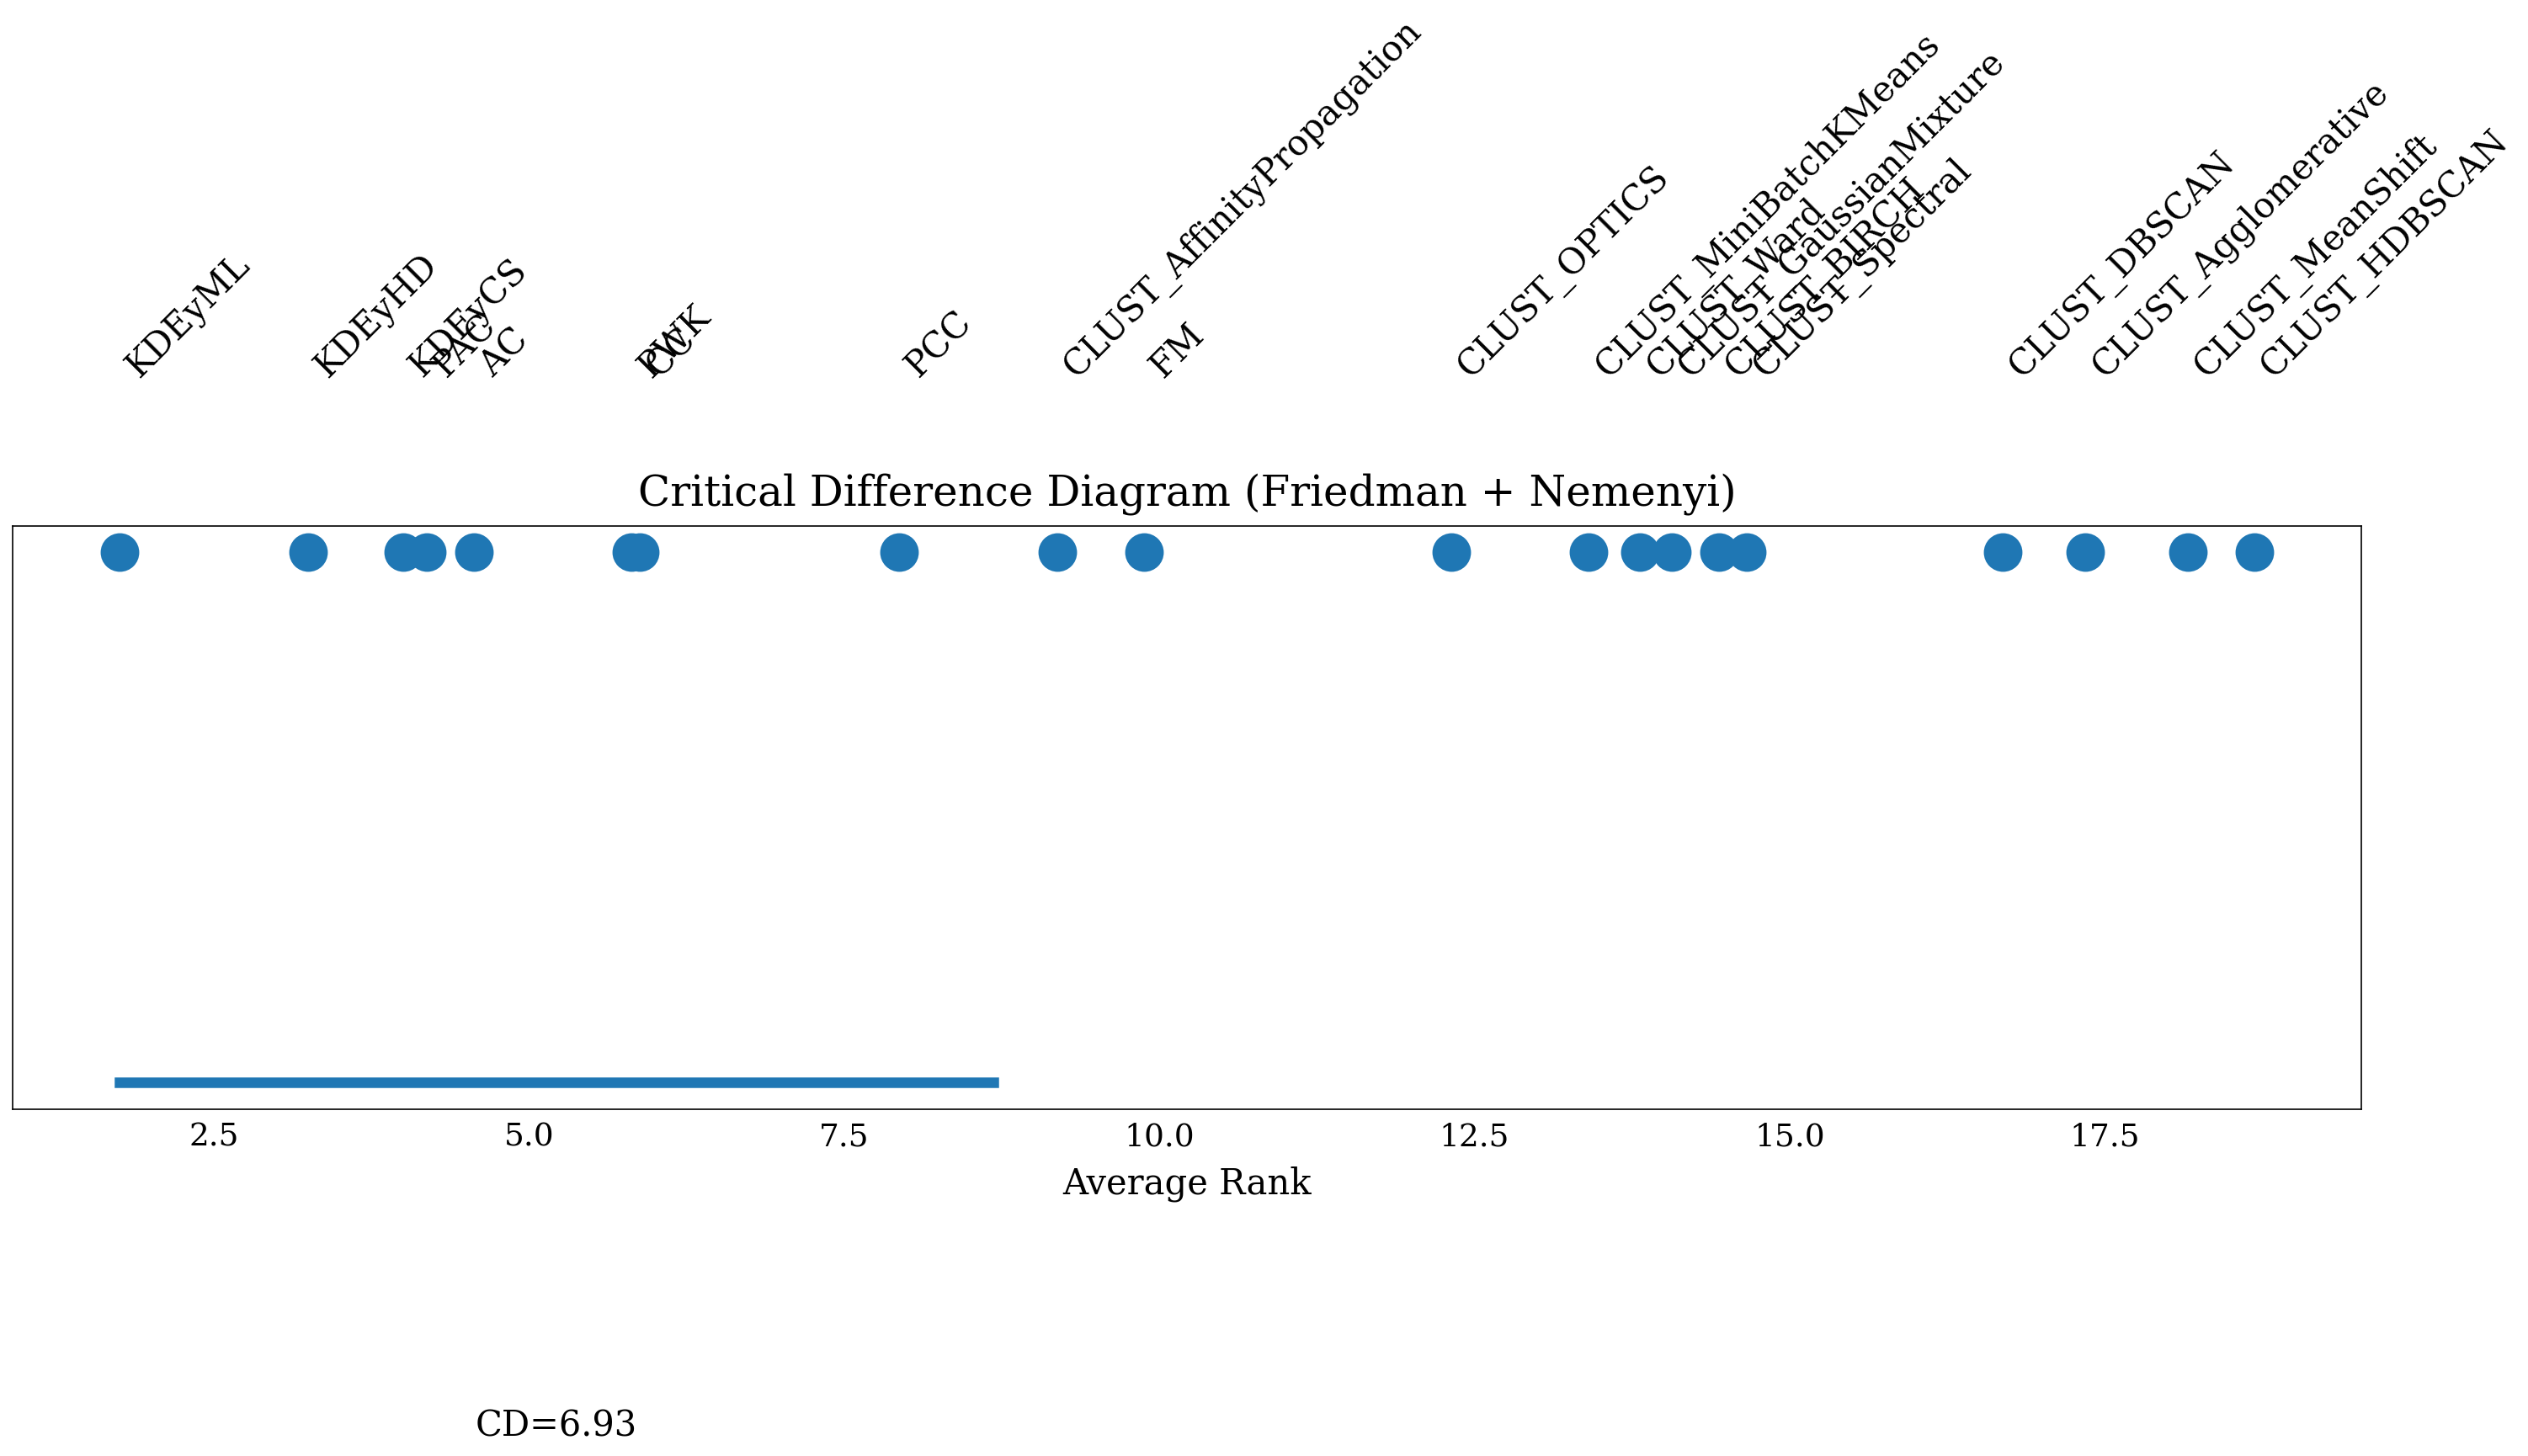

In [12]:
import pandas as pd
import numpy as np

from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

CSV_PATH = "tabela_erros_medios.csv"

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(CSV_PATH)

# remove colunas que não são métodos
methods = [
    c for c in df.columns
    if c not in ["dataset", "n_classes_original"]
]

print(f"Datasets: {len(df)}")
print(f"Métodos: {len(methods)}")

# ============================================================
# FRIEDMAN TEST
# ============================================================

friedman_data = [df[m].values for m in methods]

stat, p = friedmanchisquare(*friedman_data)

print("\n========================")
print("FRIEDMAN TEST")
print("========================")
print(f"Statistic = {stat:.6f}")
print(f"P-value   = {p:.10f}")

# ============================================================
# RANKS
# ============================================================

# menor erro = melhor
ranks = df[methods].rank(axis=1, ascending=True)

avg_ranks = ranks.mean(axis=0).sort_values()

print("\n========================")
print("AVERAGE RANKS")
print("========================")
print(avg_ranks)

# ============================================================
# NEMENYI POST-HOC
# ============================================================

nemenyi = sp.posthoc_nemenyi_friedman(df[methods])

nemenyi.index = methods
nemenyi.columns = methods

print("\n========================")
print("NEMENYI")
print("========================")
print(nemenyi)

# ============================================================
# CRITICAL DIFFERENCE
# ============================================================

N = len(df)          # datasets
k = len(methods)     # métodos

# q_alpha para alpha=0.05
# Demsar (2006)

q_alpha = 3.314

CD = q_alpha * np.sqrt(
    k * (k + 1) / (6 * N)
)

print("\n========================")
print("CRITICAL DIFFERENCE")
print("========================")
print(f"CD = {CD:.4f}")

# ============================================================
# SIMPLE CD PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(12, 3))

sorted_methods = avg_ranks.index
sorted_ranks = avg_ranks.values

ax.scatter(sorted_ranks,
           np.zeros_like(sorted_ranks),
           s=100)

for r, m in zip(sorted_ranks, sorted_methods):
    ax.text(
        r,
        0.1,
        m,
        rotation=45,
        ha='left'
    )

# barra CD

xmin = sorted_ranks.min()

ax.plot(
    [xmin, xmin + CD],
    [-0.3, -0.3],
    linewidth=3
)

ax.text(
    xmin + CD/2,
    -0.5,
    f"CD={CD:.2f}",
    ha='center'
)

ax.set_yticks([])
ax.set_xlabel("Average Rank")

ax.set_title(
    "Critical Difference Diagram (Friedman + Nemenyi)"
)

plt.tight_layout()
plt.show()

Métodos: ['AC', 'CC', 'CLUST_AffinityPropagation', 'CLUST_Agglomerative', 'CLUST_BIRCH', 'CLUST_DBSCAN', 'CLUST_GaussianMixture', 'CLUST_HDBSCAN', 'CLUST_MeanShift', 'CLUST_MiniBatchKMeans', 'CLUST_OPTICS', 'CLUST_Spectral', 'CLUST_Ward', 'FM', 'KDEyCS', 'KDEyHD', 'KDEyML', 'PAC', 'PCC', 'PWK']
Datasets: 16

================ FRIEDMAN ================
stat = 265.3950016535172
p    = 2.325105103948839e-45
Diferenças significativas → prosseguindo com Nemenyi

================ RANKS MÉDIOS ================
KDEyML                        1.75000
KDEyHD                        3.25000
KDEyCS                        4.00000
PAC                           4.18750
AC                            4.56250
PWK                           5.81250
CC                            5.87500
PCC                           7.93750
CLUST_AffinityPropagation     9.18750
FM                            9.87500
CLUST_OPTICS                 12.31250
CLUST_MiniBatchKMeans        13.40625
CLUST_Ward                   13.8125

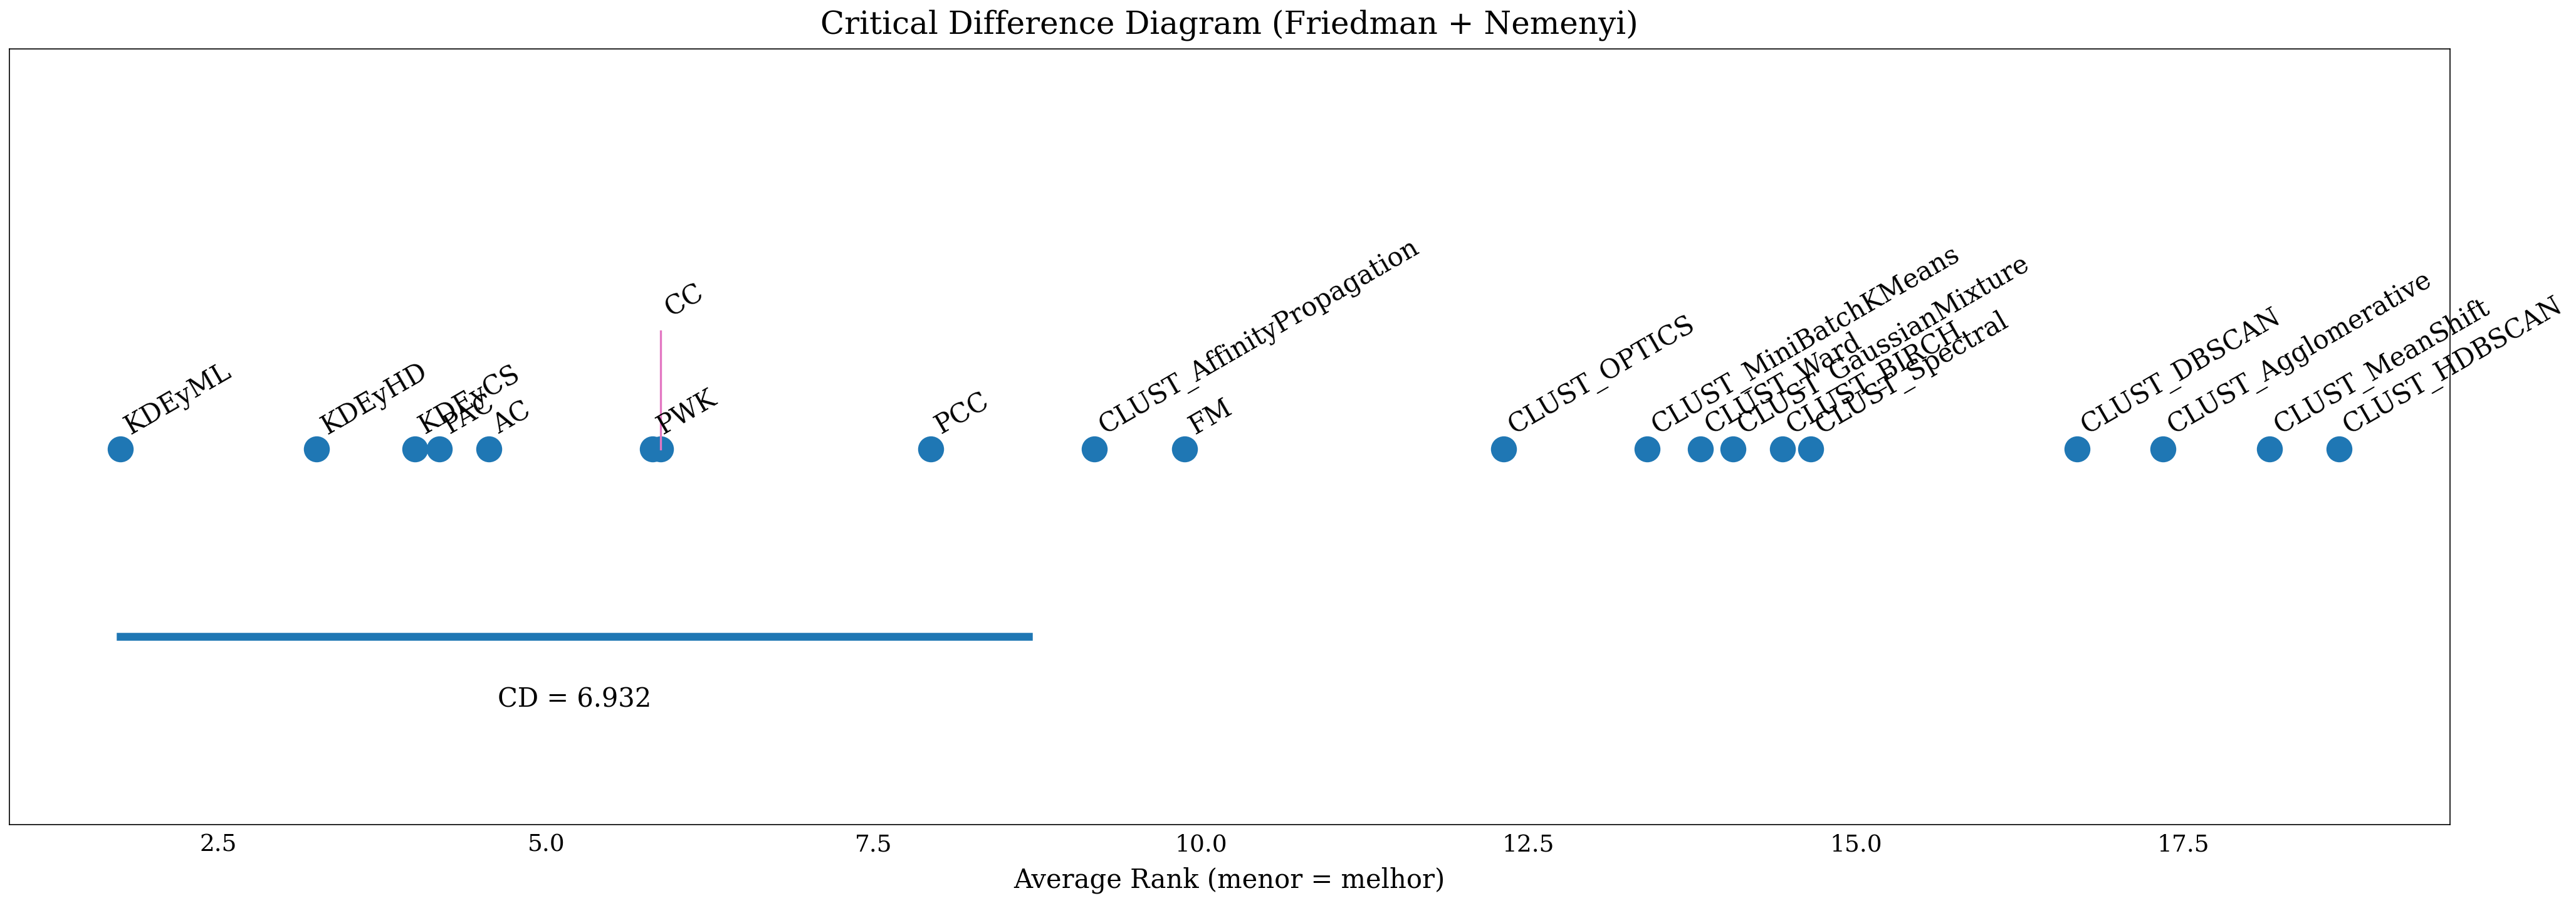

In [13]:
import pandas as pd
import numpy as np

from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

CSV_PATH = "tabela_erros_medios.csv"
ALPHA = 0.05

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(CSV_PATH)

methods = [
    c for c in df.columns
    if c not in ["dataset", "n_classes_original"]
]

print("Métodos:", methods)
print("Datasets:", len(df))

# ============================================================
# FRIEDMAN TEST
# ============================================================

friedman_stat, friedman_p = friedmanchisquare(
    *[df[m].values for m in methods]
)

print("\n================ FRIEDMAN ================")
print("stat =", friedman_stat)
print("p    =", friedman_p)

if friedman_p < ALPHA:
    print("Diferenças significativas → prosseguindo com Nemenyi")
else:
    print("Sem diferença significativa (tecnicamente CD não é necessário)")

# ============================================================
# RANKS (IMPORTANTE: menor erro = melhor)
# ============================================================

ranks = df[methods].rank(axis=1, ascending=True)
avg_ranks = ranks.mean().sort_values()

print("\n================ RANKS MÉDIOS ================")
print(avg_ranks)

# ============================================================
# NEMENYI (HOLM ADJUSTED POST-HOC)
# ============================================================

nemenyi = sp.posthoc_nemenyi_friedman(df[methods])

nemenyi.index = methods
nemenyi.columns = methods

print("\n================ NEMENYI p-values ================")
print(nemenyi)

# ============================================================
# CRITICAL DIFFERENCE (Demsar 2006)
# ============================================================

k = len(methods)
N = len(df)

q_alpha = 3.314  # alpha=0.05, large k approx

CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))

print("\n================ CRITICAL DIFFERENCE ================")
print("CD =", CD)

# ============================================================
# CD DIAGRAM (ROBUSTO, SEM OVERLAP)
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

sorted_methods = avg_ranks.index.to_list()
sorted_values = avg_ranks.values

# eixo principal
ax.scatter(sorted_values, np.zeros_like(sorted_values), s=80)

# layout em "níveis" para evitar sobreposição
levels = np.zeros(len(sorted_values))
used_positions = []

for i, r in enumerate(sorted_values):
    level = 0
    while any(abs(r - x[0]) < 0.15 and x[1] == level for x in used_positions):
        level += 0.25
    used_positions.append((r, level))
    levels[i] = level

# desenhar labels
for i, (r, m) in enumerate(zip(sorted_values, sorted_methods)):

    y = levels[i]

    ax.plot([r, r], [0, y], lw=0.8)
    ax.text(
        r,
        y + 0.02,
        m,
        rotation=30,
        ha="left",
        va="bottom",
        fontsize=10
    )

# CD bar
xmin = sorted_values.min()

ax.plot(
    [xmin, xmin + CD],
    [-0.4, -0.4],
    lw=3
)

ax.text(
    xmin + CD / 2,
    -0.55,
    f"CD = {CD:.3f}",
    ha="center"
)

ax.set_ylim(-0.8, max(levels) + 0.6)
ax.set_yticks([])
ax.set_xlabel("Average Rank (menor = melhor)")
ax.set_title("Critical Difference Diagram (Friedman + Nemenyi)")

plt.tight_layout()

# salvar
plt.savefig("cd_diagram.pdf")
plt.savefig("cd_diagram.svg")

plt.show()

In [14]:
# -*- coding: utf-8 -*-
"""
Script para geração de Diagrama de Diferença Crítica (CD Diagram)
Baseado no framework de Demšar (Friedman + Post-hoc Wilcoxon com correção de Holm)
Adaptado para métricas de Erro (menor valor = melhor rank)

Autores originais: Hassan Ismail Fawaz, Germain Forestier, Jonathan Weber, 
                  Lhassane Idoumghar, Pierre-Alain Muller
Modificações: Ajuste de subscritos, formatação numérica (.2f) e exibição do CD.
"""

import numpy as np
import pandas as pd
import matplotlib
import operator
import math
import re
from scipy.stats import wilcoxon
from scipy.stats import friedmanchisquare
import networkx

# Garante que o matplotlib funcione mesmo em ambientes sem interface gráfica (servidores, Jupyter, etc.)
matplotlib.use('agg')
import matplotlib.pyplot as plt

# Evita avisos de falta de fonte utilizando as disponíveis no sistema de forma genérica
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'Helvetica', 'sans-serif']


def graph_ranks(avranks, names, p_values, cd=None, cdmethod=None, lowv=None, highv=None,
                width=6, textspace=1, reverse=False, filename=None, labels=False, **kwargs):
    """
    Desenha o núcleo do gráfico de Diferença Crítica.
    """
    try:
        from matplotlib.backends.backend_agg import FigureCanvasAgg
    except ImportError:
        raise ImportError("A função graph_ranks exige o pacote matplotlib.")

    width = float(width)
    textspace = float(textspace)

    def nth(l, n):
        n = lloc(l, n)
        return [a[n] for a in l]

    def lloc(l, n):
        if n < 0: return len(l[0]) + n
        else: return n

    sums = avranks
    nnames = names
    ssums = sums

    if lowv is None:
        lowv = min(1, int(math.floor(min(ssums))))
    if highv is None:
        highv = max(len(avranks), int(math.ceil(max(ssums))))

    cline = 0.6 
    k = len(sums)
    linesblank = 0
    scalewidth = width - 2 * textspace

    def rankpos(rank):
        if not reverse:
            a = rank - lowv
        else:
            a = highv - rank
        return textspace + scalewidth / (highv - lowv) * a

    distanceh = 0.25
    cline += distanceh

    minnotsignificant = max(2 * 0.2, linesblank)
    height = cline + ((k + 1) / 2) * 0.2 + minnotsignificant

    fig = plt.figure(figsize=(width, height))
    fig.set_facecolor('white')
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()

    hf = 1. / height
    wf = 1. / width

    def hfl(l): return [a * hf for a in l]
    def wfl(l): return [a * wf for a in l]

    ax.plot([0, 1], [0, 1], c="w")
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)

    def line(l, color='k', **kwargs):
        ax.plot(wfl(nth(l, 0)), hfl(nth(l, 1)), color=color, **kwargs)

    def text(x, y, s, *args, **kwargs):
        ax.text(wf * x, hf * y, s, *args, **kwargs)

    line([(textspace, cline), (width - textspace, cline)], linewidth=2)

    bigtick = 0.3
    smalltick = 0.15
    linewidth = 1.5
    linewidth_sign = 4.5

    tick = None
    for a in list(np.arange(lowv, highv, 0.5)) + [highv]:
        tick = smalltick
        if a == int(a):
            tick = bigtick
        line([(rankpos(a), cline - tick / 2),
              (rankpos(a), cline)],
             linewidth=2)

    for a in range(lowv, highv + 1):
        text(rankpos(a), cline - tick / 2 - 0.05, str(a),
             ha="center", va="bottom", size=14)

    k = len(ssums)
    
    # AJUSTE: Transforma o caractere "_" em subíndices matemáticos reais do Matplotlib
    def filter_names(name):
        if "_" in name:
            parts = name.split("_")
            return r"${}_{{{}}}$".format(parts[0], "".join(parts[1:]))
        return name

    space_between_names = 0.28

    # Desenha o lado Esquerdo do gráfico
    for i in range(math.ceil(k / 2)):
        chei = cline + minnotsignificant + i * space_between_names
        line([(rankpos(ssums[i]), cline),
              (rankpos(ssums[i]), chei),
              (textspace - 0.1, chei)],
             linewidth=linewidth, color='#444444')
        if labels:
            # AJUSTE: Forçado para exatamente duas casas decimais
            text(textspace + 0.25, chei - 0.075, format(ssums[i], '.2f'), ha="right", va="center", size=11, color='#555555')
        text(textspace - 0.2, chei, filter_names(nnames[i]), ha="right", va="center", size=15)

    # Desenha o lado Direito do gráfico
    for i in range(math.ceil(k / 2), k):
        chei = cline + minnotsignificant + (k - i - 1) * space_between_names
        line([(rankpos(ssums[i]), cline),
              (rankpos(ssums[i]), chei),
              (textspace + scalewidth + 0.1, chei)],
             linewidth=linewidth, color='#444444')
        if labels:
            # AJUSTE: Forçado para exatamente duas casas decimais
            text(textspace + scalewidth - 0.25, chei - 0.075, format(ssums[i], '.2f'), ha="left", va="center", size=11, color='#555555')
        text(textspace + scalewidth + 0.2, chei, filter_names(nnames[i]),
             ha="left", va="center", size=15)

    # Agrupa os classificadores não significativos (cliques) para desenhar as linhas pretas grossas
    side = -0.02
    height = 0.08
    cliques = form_cliques(p_values, nnames)
    achieved_half = False
    
    for clq in cliques:
        if len(clq) == 1:
            continue
        min_idx = np.array(clq).min()
        max_idx = np.array(clq).max()
        if min_idx >= len(nnames) / 2 and achieved_half == False:
            start = cline + 0.23
            achieved_half = True
        else:
            start = cline + 0.18
        line([(rankpos(ssums[min_idx]) - side, start),
              (rankpos(ssums[max_idx]) + side, start)],
             linewidth=linewidth_sign, color='#111111')
        start += height

    # AJUSTE: Desenha a régua de tamanho do CD e o rótulo "CD = X.XX" no topo
    if cd is not None:
        cd_top = cline - 0.55
        line([(textspace, cd_top), (textspace + (scalewidth / (highv - lowv)) * cd, cd_top)], linewidth=2.5, color='black')
        line([(textspace, cd_top - 0.05), (textspace, cd_top + 0.05)], linewidth=1.5, color='black')
        line([(textspace + (scalewidth / (highv - lowv)) * cd, cd_top - 0.05), (textspace + (scalewidth / (highv - lowv)) * cd, cd_top + 0.05)], linewidth=1.5, color='black')
        text(textspace + ((scalewidth / (highv - lowv)) * cd) / 2, cd_top - 0.08, f"CD = {cd:.2f}", ha="center", va="bottom", size=12, weight='bold')


def form_cliques(p_values, nnames):
    m = len(nnames)
    g_data = np.zeros((m, m), dtype=np.int64)
    for p in p_values:
        if p[3] == False:
            i = np.where(nnames == p[0])[0][0]
            j = np.where(nnames == p[1])[0][0]
            min_i = min(i, j)
            max_j = max(i, j)
            g_data[min_i, max_j] = 1

    g = networkx.Graph(g_data)
    return networkx.find_cliques(g)


def draw_cd_diagram(df_perf=None, alpha=0.05, title=None, labels=False):
    p_values, average_ranks, num_datasets = wilcoxon_holm(df_perf=df_perf, alpha=alpha)

    # Cálculo aproximado do valor de CD crítico de Nemenyi usando tabela estendida
    k_methods = len(average_ranks)
    q_table = {2:1.96, 3:2.34, 4:2.57, 5:2.73, 6:2.85, 7:2.95, 8:3.03, 9:3.10, 10:3.16, 11:3.22, 12:3.27, 13:3.31, 14:3.35}
    q_alpha = q_table.get(k_methods, 3.2) 
    calculated_cd = q_alpha * math.sqrt((k_methods * (k_methods + 1)) / (6.0 * num_datasets))

    # Executa a plotagem expandida para evitar quebra de texto nas laterais
    graph_ranks(average_ranks.values, average_ranks.keys(), p_values,
                cd=calculated_cd, reverse=True, width=11, textspace=1.8, labels=labels)

    font = {'family': 'sans-serif', 'color': 'black', 'weight': 'bold', 'size': 16}
    if title:
        plt.title(title, fontdict=font, y=0.96, x=0.5)
    
    # Salva o arquivo final
    plt.savefig('cd-diagram.pdf', bbox_inches='tight')
    plt.savefig('cd-diagram.png', bbox_inches='tight', dpi=300)
    print("Sucesso! Diagrama salvo como 'cd-diagram.png'.")


def wilcoxon_holm(alpha=0.05, df_perf=None):
    df_counts = pd.DataFrame({'count': df_perf.groupby(['classifier_name']).size()}).reset_index()
    max_nb_datasets = df_counts['count'].max()
    classifiers = list(df_counts.loc[df_counts['count'] == max_nb_datasets]['classifier_name'])
    
    # Teste de hipótese global de Friedman
    friedman_p_value = friedmanchisquare(*(
        np.array(df_perf.loc[df_perf['classifier_name'] == c]['accuracy'])
        for c in classifiers))[1]
        
    if friedman_p_value >= alpha:
        print('O teste de Friedman indica que os algoritmos não têm diferença estatística global.')
        exit()

    m = len(classifiers)
    p_values = []
    for i in range(m - 1):
        classifier_1 = classifiers[i]
        perf_1 = np.array(df_perf.loc[df_perf['classifier_name'] == classifier_1]['accuracy'], dtype=np.float64)
        for j in range(i + 1, m):
            classifier_2 = classifiers[j]
            perf_2 = np.array(df_perf.loc[df_perf['classifier_name'] == classifier_2]['accuracy'], dtype=np.float64)
            p_value = wilcoxon(perf_1, perf_2, zero_method='pratt')[1]
            p_values.append((classifier_1, classifier_2, p_value, False))

    k = len(p_values)
    p_values.sort(key=operator.itemgetter(2))

    for i in range(k):
        new_alpha = float(alpha / (k - i))
        if p_values[i][2] <= new_alpha:
            p_values[i] = (p_values[i][0], p_values[i][1], p_values[i][2], True)
        else:
            break

    sorted_df_perf = df_perf.loc[df_perf['classifier_name'].isin(classifiers)].sort_values(['classifier_name', 'dataset_name'])
    rank_data = np.array(sorted_df_perf['accuracy']).reshape(m, max_nb_datasets)

    df_ranks = pd.DataFrame(data=rank_data, index=np.sort(classifiers), columns=np.unique(sorted_df_perf['dataset_name']))

    # AJUSTE ESTRUTURAL: Definido para ascending=True porque sua tabela é de erros (menor erro = melhor rank)
    average_ranks = df_ranks.rank(ascending=True).mean(axis=1).sort_values(ascending=False)
    
    return p_values, average_ranks, max_nb_datasets


# ==============================================================================
# PIPELINE DE EXECUÇÃO COM OS SEUS DADOS
# ==============================================================================
if __name__ == '__main__':
    
    # 1. Carregar seu arquivo
    df_original = pd.read_csv('tabela_erros_medios.csv')

    # 2. [OPCIONAL] Se o seu arquivo bruto possuir as 50 linhas explícitas repetidas 
    # por dataset, descomente a linha abaixo para calcular a média delas:
    # df_original = df_original.groupby('dataset').mean().reset_index()

    # 3. Mapeamento das colunas que representam os seus algoritmos
    colunas_algoritmos = [
        'AC', 'CC', 'EMQ', 'EMQ_BCTS', 'FM', 'KDEy_CS', 'KDEy_HD', 
        'KDEy_ML', 'PAC', 'PCC', 'PWK', 'SSQML', 'SSQML_ISO', 'SSQML_RF'
    ]

    # 4. Derretimento (Melt) para transformar colunas em formato longo esperado
    df_long = pd.melt(
        df_original, 
        id_vars=['dataset'], 
        value_vars=colunas_algoritmos,
        var_name='classifier_name', 
        value_name='accuracy'  # Mantido nome interno para o motor matemático funcionar
    )

    # Renomeia para sincronizar com os metadados internos das funções
    df_long = df_long.rename(columns={'dataset': 'dataset_name'})

    # 5. Roda e salva o gráfico final customizado
    draw_cd_diagram(df_perf=df_long, labels=True)

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['EMQ', 'EMQ_BCTS', 'KDEy_CS', 'KDEy_HD', 'KDEy_ML', 'SSQML', 'SSQML_ISO', 'SSQML_RF']"

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib
import operator
import math
from scipy.stats import wilcoxon
from scipy.stats import friedmanchisquare
import networkx

matplotlib.use('agg')
import matplotlib.pyplot as plt

matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'Helvetica', 'sans-serif']


def graph_ranks(avranks, names, p_values, cd=None, cdmethod=None, lowv=None, highv=None,
                width=6, textspace=1, reverse=False, filename=None, labels=False, **kwargs):
    try:
        from matplotlib.backends.backend_agg import FigureCanvasAgg
    except ImportError:
        raise ImportError("A função graph_ranks exige o pacote matplotlib.")

    width = float(width)
    textspace = float(textspace)

    def nth(l, n):
        n = lloc(l, n)
        return [a[n] for a in l]

    def lloc(l, n):
        if n < 0: return len(l[0]) + n
        else: return n

    sums = avranks
    nnames = names
    ssums = sums

    if lowv is None:
        lowv = min(1, int(math.floor(min(ssums))))
    if highv is None:
        highv = max(len(avranks), int(math.ceil(max(ssums))))

    cline = 0.6
    k = len(sums)
    linesblank = 0
    scalewidth = width - 2 * textspace

    def rankpos(rank):
        if not reverse:
            a = rank - lowv
        else:
            a = highv - rank
        return textspace + scalewidth / (highv - lowv) * a

    distanceh = 0.25
    cline += distanceh

    minnotsignificant = max(2 * 0.2, linesblank)
    height = cline + ((k + 1) / 2) * 0.2 + minnotsignificant

    fig = plt.figure(figsize=(width, height))
    fig.set_facecolor('white')
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()

    hf = 1. / height
    wf = 1. / width

    def hfl(l): return [a * hf for a in l]
    def wfl(l): return [a * wf for a in l]

    ax.plot([0, 1], [0, 1], c="w")
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)

    def line(l, color='k', **kwargs):
        ax.plot(wfl(nth(l, 0)), hfl(nth(l, 1)), color=color, **kwargs)

    def text(x, y, s, *args, **kwargs):
        ax.text(wf * x, hf * y, s, *args, **kwargs)

    line([(textspace, cline), (width - textspace, cline)], linewidth=2)

    bigtick = 0.3
    smalltick = 0.15
    linewidth = 1.5
    linewidth_sign = 4.5

    tick = None
    for a in list(np.arange(lowv, highv, 0.5)) + [highv]:
        tick = smalltick
        if a == int(a):
            tick = bigtick
        line([(rankpos(a), cline - tick / 2),
              (rankpos(a), cline)],
             linewidth=2)

    for a in range(lowv, highv + 1):
        text(rankpos(a), cline - tick / 2 - 0.05, str(a),
             ha="center", va="bottom", size=14)

    k = len(ssums)

    def filter_names(name):
        if "_" in name:
            parts = name.split("_")
            return r"${}_{{{}}}$".format(parts[0], "".join(parts[1:]))
        return name

    space_between_names = 0.28

    for i in range(math.ceil(k / 2)):
        chei = cline + minnotsignificant + i * space_between_names
        line([(rankpos(ssums[i]), cline),
              (rankpos(ssums[i]), chei),
              (textspace - 0.1, chei)],
             linewidth=linewidth, color='#444444')
        if labels:
            text(textspace + 0.25, chei - 0.075, format(ssums[i], '.2f'), ha="right", va="center", size=11, color='#555555')
        text(textspace - 0.2, chei, filter_names(nnames[i]), ha="right", va="center", size=15)

    for i in range(math.ceil(k / 2), k):
        chei = cline + minnotsignificant + (k - i - 1) * space_between_names
        line([(rankpos(ssums[i]), cline),
              (rankpos(ssums[i]), chei),
              (textspace + scalewidth + 0.1, chei)],
             linewidth=linewidth, color='#444444')
        if labels:
            text(textspace + scalewidth - 0.25, chei - 0.075, format(ssums[i], '.2f'), ha="left", va="center", size=11, color='#555555')
        text(textspace + scalewidth + 0.2, chei, filter_names(nnames[i]),
             ha="left", va="center", size=15)

    side = -0.02
    height = 0.08
    cliques = form_cliques(p_values, nnames)
    achieved_half = False

    for clq in cliques:
        if len(clq) == 1:
            continue
        min_idx = np.array(clq).min()
        max_idx = np.array(clq).max()
        if min_idx >= len(nnames) / 2 and achieved_half == False:
            start = cline + 0.23
            achieved_half = True
        else:
            start = cline + 0.18
        line([(rankpos(ssums[min_idx]) - side, start),
              (rankpos(ssums[max_idx]) + side, start)],
             linewidth=linewidth_sign, color='#111111')
        start += height

    if cd is not None:
        cd_top = cline - 0.55
        line([(textspace, cd_top),
              (textspace + (scalewidth / (highv - lowv)) * cd, cd_top)],
             linewidth=2.5, color='black')
        line([(textspace, cd_top - 0.05),
              (textspace, cd_top + 0.05)],
             linewidth=1.5, color='black')
        line([(textspace + (scalewidth / (highv - lowv)) * cd, cd_top - 0.05),
              (textspace + (scalewidth / (highv - lowv)) * cd, cd_top + 0.05)],
             linewidth=1.5, color='black')
        text(textspace + ((scalewidth / (highv - lowv)) * cd) / 2,
             cd_top - 0.08, f"CD = {cd:.2f}",
             ha="center", va="bottom", size=12, weight='bold')


def form_cliques(p_values, nnames):
    m = len(nnames)
    g_data = np.zeros((m, m), dtype=np.int64)
    for p in p_values:
        if p[3] == False:
            i = np.where(nnames == p[0])[0][0]
            j = np.where(nnames == p[1])[0][0]
            min_i = min(i, j)
            max_j = max(i, j)
            g_data[min_i, max_j] = 1

    g = networkx.Graph(g_data)
    return networkx.find_cliques(g)


def draw_cd_diagram(df_perf=None, alpha=0.05, title=None, labels=False):
    p_values, average_ranks, num_datasets, friedman_pvalue = wilcoxon_holm(
        df_perf=df_perf, alpha=alpha
    )

    # ── IMPRESSÃO DO P-VALOR DO FRIEDMAN ──────────────────────────────────────
    print("=" * 55)
    print(f"  Friedman p-value : {friedman_pvalue:.6f}")
    print(f"  Significativo    : {'SIM  (p < 0.05)' if friedman_pvalue < alpha else 'NAO  (p >= 0.05)'}")
    print(f"  Nº de métodos    : {len(average_ranks)}")
    print(f"  Nº de datasets   : {num_datasets}")
    print("=" * 55)
    print("\nRanks médios (menor = melhor):")
    for name, rank in average_ranks.sort_values().items():
        print(f"  {name:<20s}  {rank:.4f}")
    print("=" * 55)

    k_methods = len(average_ranks)
    q_table = {
        2: 1.96, 3: 2.34, 4: 2.57, 5: 2.73, 6: 2.85,
        7: 2.95, 8: 3.03, 9: 3.10, 10: 3.16, 11: 3.22,
        12: 3.27, 13: 3.31, 14: 3.35
    }
    q_alpha = q_table.get(k_methods, 3.2)
    calculated_cd = q_alpha * math.sqrt(
        (k_methods * (k_methods + 1)) / (6.0 * num_datasets)
    )
    print(f"\n  CD calculado     : {calculated_cd:.4f}")
    print("=" * 55)

    graph_ranks(average_ranks.values, average_ranks.keys(), p_values,
                cd=calculated_cd, reverse=True, width=11, textspace=1.8, labels=labels)

    font = {'family': 'sans-serif', 'color': 'black', 'weight': 'bold', 'size': 16}
    if title:
        plt.title(title, fontdict=font, y=0.96, x=0.5)

    plt.savefig('cd-diagram.pdf', bbox_inches='tight')
    plt.savefig('cd-diagram.png', bbox_inches='tight', dpi=300)
    print("\nDiagrama salvo como 'cd-diagram.png' e 'cd-diagram.pdf'.")


def wilcoxon_holm(alpha=0.05, df_perf=None):
    df_counts = pd.DataFrame(
        {'count': df_perf.groupby(['classifier_name']).size()}
    ).reset_index()
    max_nb_datasets = df_counts['count'].max()
    classifiers = list(
        df_counts.loc[df_counts['count'] == max_nb_datasets]['classifier_name']
    )

    # ── FRIEDMAN ──────────────────────────────────────────────────────────────
    friedman_stat, friedman_pvalue = friedmanchisquare(*(
        np.array(df_perf.loc[df_perf['classifier_name'] == c]['accuracy'])
        for c in classifiers
    ))

    if friedman_pvalue >= alpha:
        print(f"\n[AVISO] Friedman p-value = {friedman_pvalue:.6f} >= {alpha}.")
        print("Não há diferença estatística global. Nemenyi NÃO deve ser aplicado.")
        exit()

    # ── WILCOXON + HOLM ───────────────────────────────────────────────────────
    m = len(classifiers)
    p_values = []
    for i in range(m - 1):
        classifier_1 = classifiers[i]
        perf_1 = np.array(
            df_perf.loc[df_perf['classifier_name'] == classifier_1]['accuracy'],
            dtype=np.float64
        )
        for j in range(i + 1, m):
            classifier_2 = classifiers[j]
            perf_2 = np.array(
                df_perf.loc[df_perf['classifier_name'] == classifier_2]['accuracy'],
                dtype=np.float64
            )
            p_value = wilcoxon(perf_1, perf_2, zero_method='pratt')[1]
            p_values.append((classifier_1, classifier_2, p_value, False))

    k = len(p_values)
    p_values.sort(key=operator.itemgetter(2))

    for i in range(k):
        new_alpha = float(alpha / (k - i))
        if p_values[i][2] <= new_alpha:
            p_values[i] = (p_values[i][0], p_values[i][1], p_values[i][2], True)
        else:
            break

    sorted_df_perf = df_perf.loc[
        df_perf['classifier_name'].isin(classifiers)
    ].sort_values(['classifier_name', 'dataset_name'])

    rank_data = np.array(sorted_df_perf['accuracy']).reshape(m, max_nb_datasets)
    df_ranks = pd.DataFrame(
        data=rank_data,
        index=np.sort(classifiers),
        columns=np.unique(sorted_df_perf['dataset_name'])
    )

    average_ranks = df_ranks.rank(ascending=True).mean(axis=1).sort_values(ascending=False)

    return p_values, average_ranks, max_nb_datasets, friedman_pvalue


# ==============================================================================
if __name__ == '__main__':

    df_original = pd.read_csv('tabela_erros_medios.csv')

    colunas_algoritmos = [
        'AC', 'CC', 'EMQ', 'EMQ_BCTS', 'FM', 'KDEy_CS', 'KDEy_HD',
        'KDEy_ML', 'PAC', 'PCC', 'PWK', 'SSQML', 'SSQML_ISO', 'SSQML_RF'
    ]

    df_long = pd.melt(
        df_original,
        id_vars=['dataset'],
        value_vars=colunas_algoritmos,
        var_name='classifier_name',
        value_name='accuracy'
    )
    df_long = df_long.rename(columns={'dataset': 'dataset_name'})

    draw_cd_diagram(
        df_perf=df_long,
        labels=True,
        title='Critical Difference Diagram - Mean Error'
    )

  Friedman p-value : 0.000003
  Significativo    : SIM  (p < 0.05)
  Nº de métodos    : 14
  Nº de datasets   : 40

Ranks médios (menor = melhor):
  PCC                   5.5500
  PWK                   5.9750
  SSQML_RF              6.0500
  CC                    6.5375
  EMQ_BCTS              7.0750
  KDEy_CS               7.1500
  KDEy_ML               7.1750
  SSQML_ISO             7.6250
  KDEy_HD               7.6250
  SSQML                 8.2000
  AC                    8.3625
  EMQ                   8.5750
  PAC                   8.6750
  FM                    10.4250

  CD calculado     : 3.1336

Diagrama salvo como 'cd-diagram.png' e 'cd-diagram.pdf'.


In [ ]:
# -*- coding: utf-8 -*-
"""
Script para geração de Diagrama de Diferença Crítica (CD Diagram)
Baseado no framework de Demšar (Friedman + Post-hoc Wilcoxon com correção de Holm)
Adaptado para métricas de Erro (menor valor = melhor rank)

Autores originais: Hassan Ismail Fawaz, Germain Forestier, Jonathan Weber, 
                  Lhassane Idoumghar, Pierre-Alain Muller
Modificações: Ajuste de subscritos, formatação numérica (.2f) e exibição do CD.
"""

import numpy as np
import pandas as pd
import matplotlib
import operator
import math
import re
from scipy.stats import wilcoxon
from scipy.stats import friedmanchisquare
import networkx

# Garante que o matplotlib funcione mesmo em ambientes sem interface gráfica (servidores, Jupyter, etc.)
matplotlib.use('agg')
import matplotlib.pyplot as plt

# Evita avisos de falta de fonte utilizando as disponíveis no sistema de forma genérica
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'Helvetica', 'sans-serif']


def graph_ranks(avranks, names, p_values, cd=None, cdmethod=None, lowv=None, highv=None,
                width=6, textspace=1, reverse=False, filename=None, labels=False, **kwargs):
    """
    Desenha o núcleo do gráfico de Diferença Crítica.
    """
    try:
        from matplotlib.backends.backend_agg import FigureCanvasAgg
    except ImportError:
        raise ImportError("A função graph_ranks exige o pacote matplotlib.")

    width = float(width)
    textspace = float(textspace)

    def nth(l, n):
        n = lloc(l, n)
        return [a[n] for a in l]

    def lloc(l, n):
        if n < 0: return len(l[0]) + n
        else: return n

    sums = avranks
    nnames = names
    ssums = sums

    if lowv is None:
        lowv = min(1, int(math.floor(min(ssums))))
    if highv is None:
        highv = max(len(avranks), int(math.ceil(max(ssums))))

    cline = 0.6 
    k = len(sums)
    linesblank = 0
    scalewidth = width - 2 * textspace

    def rankpos(rank):
        if not reverse:
            a = rank - lowv
        else:
            a = highv - rank
        return textspace + scalewidth / (highv - lowv) * a

    distanceh = 0.25
    cline += distanceh

    minnotsignificant = max(2 * 0.2, linesblank)
    height = cline + ((k + 1) / 2) * 0.2 + minnotsignificant

    fig = plt.figure(figsize=(width, height))
    fig.set_facecolor('white')
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()

    hf = 1. / height
    wf = 1. / width

    def hfl(l): return [a * hf for a in l]
    def wfl(l): return [a * wf for a in l]

    ax.plot([0, 1], [0, 1], c="w")
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)

    def line(l, color='k', **kwargs):
        ax.plot(wfl(nth(l, 0)), hfl(nth(l, 1)), color=color, **kwargs)

    def text(x, y, s, *args, **kwargs):
        ax.text(wf * x, hf * y, s, *args, **kwargs)

    line([(textspace, cline), (width - textspace, cline)], linewidth=2)

    bigtick = 0.3
    smalltick = 0.15
    linewidth = 1.5
    linewidth_sign = 4.5

    tick = None
    for a in list(np.arange(lowv, highv, 0.5)) + [highv]:
        tick = smalltick
        if a == int(a):
            tick = bigtick
        line([(rankpos(a), cline - tick / 2),
              (rankpos(a), cline)],
             linewidth=2)

    for a in range(lowv, highv + 1):
        text(rankpos(a), cline - tick / 2 - 0.05, str(a),
             ha="center", va="bottom", size=14)

    k = len(ssums)
    
    # AJUSTE: Transforma o caractere "_" em subíndices matemáticos reais do Matplotlib
    def filter_names(name):
        if "_" in name:
            parts = name.split("_")
            return r"${}_{{{}}}$".format(parts[0], "".join(parts[1:]))
        return name

    space_between_names = 0.28

    # Desenha o lado Esquerdo do gráfico
    for i in range(math.ceil(k / 2)):
        chei = cline + minnotsignificant + i * space_between_names
        line([(rankpos(ssums[i]), cline),
              (rankpos(ssums[i]), chei),
              (textspace - 0.1, chei)],
             linewidth=linewidth, color='#444444')
        if labels:
            # AJUSTE: Forçado para exatamente duas casas decimais
            text(textspace + 0.25, chei - 0.075, format(ssums[i], '.2f'), ha="right", va="center", size=11, color='#555555')
        text(textspace - 0.2, chei, filter_names(nnames[i]), ha="right", va="center", size=15)

    # Desenha o lado Direito do gráfico
    for i in range(math.ceil(k / 2), k):
        chei = cline + minnotsignificant + (k - i - 1) * space_between_names
        line([(rankpos(ssums[i]), cline),
              (rankpos(ssums[i]), chei),
              (textspace + scalewidth + 0.1, chei)],
             linewidth=linewidth, color='#444444')
        if labels:
            # AJUSTE: Forçado para exatamente duas casas decimais
            text(textspace + scalewidth - 0.25, chei - 0.075, format(ssums[i], '.2f'), ha="left", va="center", size=11, color='#555555')
        text(textspace + scalewidth + 0.2, chei, filter_names(nnames[i]),
             ha="left", va="center", size=15)

    # Agrupa os classificadores não significativos (cliques) para desenhar as linhas pretas grossas
    side = -0.02
    height = 0.08
    # Agrupa pelos cliques passados externamente (Nemenyi por CD)
    cliques = kwargs.get('cliques_override', None)
    nnames  = kwargs.get('nnames_override', nnames)
    achieved_half = False
    
    for clq in cliques:
        if len(clq) == 1:
            continue
        min_idx = np.array(clq).min()
        max_idx = np.array(clq).max()
        if min_idx >= len(nnames) / 2 and achieved_half == False:
            start = cline + 0.23
            achieved_half = True
        else:
            start = cline + 0.18
        line([(rankpos(ssums[min_idx]) - side, start),
              (rankpos(ssums[max_idx]) + side, start)],
             linewidth=linewidth_sign, color='#111111')
        start += height

    # AJUSTE: Desenha a régua de tamanho do CD e o rótulo "CD = X.XX" no topo
    if cd is not None:
        cd_top = cline - 0.55
        line([(textspace, cd_top), (textspace + (scalewidth / (highv - lowv)) * cd, cd_top)], linewidth=2.5, color='black')
        line([(textspace, cd_top - 0.05), (textspace, cd_top + 0.05)], linewidth=1.5, color='black')
        line([(textspace + (scalewidth / (highv - lowv)) * cd, cd_top - 0.05), (textspace + (scalewidth / (highv - lowv)) * cd, cd_top + 0.05)], linewidth=1.5, color='black')
        text(textspace + ((scalewidth / (highv - lowv)) * cd) / 2, cd_top - 0.08, f"CD = {cd:.2f}", ha="center", va="bottom", size=12, weight='bold')


def form_cliques_nemenyi(average_ranks, cd):
    """
    Conecta métodos cuja diferença de rank médio é MENOR que CD.
    Esse é o critério correto do teste de Nemenyi.
    """
    nnames = list(average_ranks.keys())
    ranks  = list(average_ranks.values)
    m = len(nnames)

    g_data = np.zeros((m, m), dtype=np.int64)
    for i in range(m):
        for j in range(i + 1, m):
            if abs(ranks[i] - ranks[j]) < cd:   # não significativo → conecta
                g_data[i, j] = 1

    g = networkx.Graph(g_data)
    return networkx.find_cliques(g), np.array(nnames)


def draw_cd_diagram(df_perf=None, alpha=0.05, title=None, labels=False):
    # CORREÇÃO: Agora recebe os 4 valores na ordem correta em que são retornados
    p_values, average_ranks, num_datasets, friedman_pvalue = wilcoxon_holm(
        df_perf=df_perf, alpha=alpha
    )

    k_methods = len(average_ranks)
    q_table = {2:1.96, 3:2.34, 4:2.57, 5:2.73, 6:2.85, 7:2.95,
               8:3.03, 9:3.10, 10:3.16, 11:3.22, 12:3.27, 13:3.31, 14:3.35}
    q_alpha = q_table.get(k_methods, 3.2)
    calculated_cd = q_alpha * math.sqrt(
        (k_methods * (k_methods + 1)) / (6.0 * num_datasets)
    )

    # ── Cliques baseados no CD do Nemenyi (substitui Wilcoxon+Holm) ──────────
    cliques_nemenyi, nnames_array = form_cliques_nemenyi(average_ranks, calculated_cd)
        # ============================================================
    # DEBUG / PRINT: SIGNIFICÂNCIA ENTRE MÉTODOS
    # ============================================================
    print("\n================= SIGNIFICÂNCIA (NEMENYI) =================")
    print(f"CD = {calculated_cd:.4f}\n")

    ranks = average_ranks.values
    names = list(average_ranks.index)

    significant_pairs = []
    not_significant_pairs = []

    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            diff = abs(ranks[i] - ranks[j])

            if diff > calculated_cd:
                significant_pairs.append((names[i], names[j], diff))
            else:
                not_significant_pairs.append((names[i], names[j], diff))

    print("❌ DIFERENÇAS SIGNIFICATIVAS (não conectadas no CD diagram):")
    for a, b, d in sorted(significant_pairs, key=lambda x: -x[2]):
        print(f"{a:15s} vs {b:15s} | diff = {d:.4f}")

    print("\n✅ NÃO SIGNIFICATIVAS (conectadas no CD diagram):")
    for a, b, d in sorted(not_significant_pairs, key=lambda x: -x[2]):
        print(f"{a:15s} vs {b:15s} | diff = {d:.4f}")

    print("===========================================================\n")

    graph_ranks(average_ranks.values, average_ranks.keys(), p_values,
                cd=calculated_cd, reverse=True, width=11, textspace=1.8,
                labels=labels,
                cliques_override=cliques_nemenyi,
                nnames_override=nnames_array)

    font = {'family': 'sans-serif', 'color': 'black', 'weight': 'bold', 'size': 16}
    if title:
        plt.title(title, fontdict=font, y=0.96, x=0.5)

    plt.savefig('cd-diagram.pdf', bbox_inches='tight')
    plt.savefig('cd-diagram.png', bbox_inches='tight', dpi=300)
    print(f"Friedman p = {friedman_pvalue:.6f} | CD = {calculated_cd:.4f}")
    print("Diagrama salvo.")


def wilcoxon_holm(alpha=0.05, df_perf=None):
    df_counts = pd.DataFrame({'count': df_perf.groupby(['classifier_name']).size()}).reset_index()
    max_nb_datasets = df_counts['count'].max()
    classifiers = list(df_counts.loc[df_counts['count'] == max_nb_datasets]['classifier_name'])
    
    # Teste de hipótese global de Friedman
    friedman_p_value = friedmanchisquare(*(
        np.array(df_perf.loc[df_perf['classifier_name'] == c]['accuracy'])
        for c in classifiers))[1]
        
    if friedman_p_value >= alpha:
        print('O teste de Friedman indica que os algoritmos não têm diferença estatística global.')
        exit()

    m = len(classifiers)
    p_values = []
    for i in range(m - 1):
        classifier_1 = classifiers[i]
        perf_1 = np.array(df_perf.loc[df_perf['classifier_name'] == classifier_1]['accuracy'], dtype=np.float64)
        for j in range(i + 1, m):
            classifier_2 = classifiers[j]
            perf_2 = np.array(df_perf.loc[df_perf['classifier_name'] == classifier_2]['accuracy'], dtype=np.float64)
            p_value = wilcoxon(perf_1, perf_2, zero_method='pratt')[1]
            p_values.append((classifier_1, classifier_2, p_value, False))

    k = len(p_values)
    p_values.sort(key=operator.itemgetter(2))

    for i in range(k):
        new_alpha = float(alpha / (k - i))
        if p_values[i][2] <= new_alpha:
            p_values[i] = (p_values[i][0], p_values[i][1], p_values[i][2], True)
        else:
            break

    sorted_df_perf = df_perf.loc[df_perf['classifier_name'].isin(classifiers)].sort_values(['classifier_name', 'dataset_name'])
    rank_data = np.array(sorted_df_perf['accuracy']).reshape(m, max_nb_datasets)

    df_ranks = pd.DataFrame(data=rank_data, index=np.sort(classifiers), columns=np.unique(sorted_df_perf['dataset_name']))

    # AJUSTE ESTRUTURAL: Definido para ascending=True porque sua tabela é de erros (menor erro = melhor rank)
    average_ranks = df_ranks.rank(ascending=True).mean(axis=1).sort_values(ascending=False)
    
    # CORREÇÃO: Incluído o friedman_p_value no retorno para bater com o esperado no unpacking
    return p_values, average_ranks, max_nb_datasets, friedman_p_value


# ==============================================================================
# PIPELINE DE EXECUÇÃO COM OS SEUS DADOS
# ==============================================================================
if __name__ == '__main__':
    
    # 1. Carregar seu arquivo
    df_original = pd.read_csv('tabela_erros_medios.csv')

    # 2. [OPCIONAL] Se o seu arquivo bruto possuir as 50 linhas explícitas repetidas 
    # por dataset, descomente a linha abaixo para calcular a média delas:
    # df_original = df_original.groupby('dataset').mean().reset_index()

    # 3. Mapeamento das colunas que representam os seus algoritmos
    colunas_algoritmos = [
        'AC', 'CC', 'EMQ', 'EMQ_BCTS', 'FM', 'KDEy_CS', 'KDEy_HD', 
        'KDEy_ML', 'PAC', 'PCC', 'PWK', 'SSQML', 'SSQML_ISO', 'SSQML_RF'
    ]

    # 4. Derretimento (Melt) para transformar colunas em formato longo esperado
    df_long = pd.melt(
        df_original, 
        id_vars=['dataset'], 
        value_vars=colunas_algoritmos,
        var_name='classifier_name', 
        value_name='accuracy'  # Mantido nome interno para o motor matemático funcionar
    )

    # Renomeia para sincronizar com os metadados internos das funções
    df_long = df_long.rename(columns={'dataset': 'dataset_name'})

    # 5. Roda e salva o gráfico final customizado
    draw_cd_diagram(df_perf=df_long, labels=True)


================= SIGNIFICÂNCIA (NEMENYI) =================
CD = 3.1336

❌ DIFERENÇAS SIGNIFICATIVAS (não conectadas no CD diagram):
FM              vs PCC             | diff = 4.8750
FM              vs PWK             | diff = 4.4500
FM              vs SSQML_RF        | diff = 4.3750
FM              vs CC              | diff = 3.8875
FM              vs EMQ_BCTS        | diff = 3.3500
FM              vs KDEy_CS         | diff = 3.2750
FM              vs KDEy_ML         | diff = 3.2500

✅ NÃO SIGNIFICATIVAS (conectadas no CD diagram):
PAC             vs PCC             | diff = 3.1250
EMQ             vs PCC             | diff = 3.0250
AC              vs PCC             | diff = 2.8125
FM              vs SSQML_ISO       | diff = 2.8000
FM              vs KDEy_HD         | diff = 2.8000
PAC             vs PWK             | diff = 2.7000
SSQML           vs PCC             | diff = 2.6500
PAC             vs SSQML_RF        | diff = 2.6250
EMQ             vs PWK             | diff = 2.6000


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

# ============================================================
# CONFIG
# ============================================================
CSV_PATH = "tabela_erros_medios.csv"

# ============================================================
# PUBLICATION STYLE
# ============================================================
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size":          10,
    "axes.labelsize":     10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "axes.linewidth":     0.4,
    "xtick.major.width":  0.4,
    "ytick.major.width":  0.4,
    "xtick.major.size":   3.0,
    "ytick.major.size":   3.0,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "xtick.top":          False,
    "ytick.right":        False,
    "axes.grid":          True,
    "axes.grid.axis":     "y",
    "grid.linewidth":     0.3,
    "grid.alpha":         0.4,
    "grid.color":         "#cccccc",
    "figure.dpi":         300,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.05,
})

# ============================================================
# LOAD & MELT
# ============================================================
df = pd.read_csv(CSV_PATH)

id_cols = ["dataset", "n_classes_original"]
value_cols = [c for c in df.columns if c not in id_cols]

df = df.melt(
    id_vars=id_cols,
    value_vars=value_cols,
    var_name="modelo",
    value_name="erro"
)

# ============================================================
# CLEAN MODELS → SMQ
# ============================================================
df["modelo"] = df["modelo"].replace(
    {
        r"SSQML":           "SMQ",
        r"SSQML_ISO": "SMQ_ISO",
        r"SSQML_RF":  "SMQ_RF",
    },
    regex=True,
)

df["modelo"] = df["modelo"].replace({
    "EMQ_BCTS_QUAPY": None,
    "EMQ_QUAPY": None,
})

df = df[df["modelo"].notna()]

# ============================================================
# TYPES
# ============================================================
df["n_classes_original"] = df["n_classes_original"].astype(int)
df["erro"] = df["erro"].astype(float)

# ============================================================
# MEDIAN MAE PER (CLASSES × MODEL)
# ============================================================
median_curve = (
    df.groupby(["n_classes_original", "modelo"])["erro"]
    .median()
    .reset_index()
)

pivot = median_curve.pivot(
    index="n_classes_original",
    columns="modelo",
    values="erro"
).sort_index()

# ============================================================
# MODEL ORDER
# ============================================================
smq_variants = ["SMQ", "SMQ_ISO", "SMQ_RF"]

all_models = df["modelo"].unique().tolist()
baseline_models = [m for m in all_models if m not in smq_variants]

baseline_models = (
    df[df["modelo"].isin(baseline_models)]
    .groupby("modelo")["erro"]
    .median()
    .sort_values()
    .index.tolist()
)

order_models = baseline_models + smq_variants

# ============================================================
# LABELS
# ============================================================
label_map = {
    "SMQ_RF":   r"$\mathrm{SMQ}_{\mathrm{RF}}$",
    "SMQ_ISO":  r"$\mathrm{SMQ}_{\mathrm{ISO}}$",
    "SMQ":      r"$\mathrm{SMQ}$",
    "EMQ":      r"$\mathrm{EMQ}$",
    "EMQ_BCTS": r"$\mathrm{EMQ}_{\mathrm{BCTS}}$",
    "KDEy_ML":  r"$\mathrm{KDEy}_{\mathrm{ML}}$",
    "KDEy_CS":  r"$\mathrm{KDEy}_{\mathrm{CS}}$",
    "KDEy_HD":  r"$\mathrm{KDEy}_{\mathrm{HD}}$",
    "PAC":      r"$\mathrm{PAC}$",
    "PCC":      r"$\mathrm{PCC}$",
    "PWK":      r"$\mathrm{PWK}$",
    "AC":       r"$\mathrm{AC}$",
    "CC":       r"$\mathrm{CC}$",
    "FM":       r"$\mathrm{FM}$",
}

# ============================================================
# COLORS
# ============================================================
spectral = sns.color_palette("Spectral", n_colors=len(baseline_models))
color_map = dict(zip(baseline_models, spectral))

color_map.update({
    "SMQ_RF":     "#d62728",
    "SMQ_ISO": "#ff7f0e",
    "SMQ":  "#2ca02c",
})

# ============================================================
# STYLE MAPS
# ============================================================
lw_map = {m: 1.5 if m in smq_variants else 0.65 for m in order_models}
ms_map = {m: 4.0 if m in smq_variants else 2.5 for m in order_models}
zo_map = {m: 4 if m in smq_variants else 2 for m in order_models}
al_map = {m: 1.0 if m in smq_variants else 0.8 for m in order_models}

# ============================================================
# X VALUES
# ============================================================
x_vals = sorted(df["n_classes_original"].unique())

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(7.8, 3.4))

for model in order_models:
    if model not in pivot.columns:
        continue

    ax.plot(
        pivot.index,
        pivot[model],
        label=label_map.get(model, model),
        linewidth=lw_map[model],
        color=color_map.get(model, "black"),
        marker="o" if model in smq_variants else None,
        markersize=ms_map[model],
        markeredgewidth=0.0,
        zorder=zo_map[model],
        alpha=al_map[model],
    )

# ============================================================
# AXES
# ============================================================
ax.set_xlabel("Number of Classes")
ax.set_ylabel("Median MAE")

ax.set_xlim(x_vals[0] - 0.5, x_vals[-1] + 0.5)
ax.set_xticks(x_vals)
ax.set_xticklabels(x_vals, fontsize=8, rotation=45, ha="right")

for label in ax.get_xticklabels():
    label.set_x(label.get_position()[0] + 0.1)
ax.tick_params(axis="x", pad=4)

ax.yaxis.set_major_locator(ticker.MaxNLocator(6))

for spine in ax.spines.values():
    spine.set_linewidth(0.4)
    spine.set_color("#aaaaaa")

ax.tick_params(which="both", length=3, width=0.4, color="#aaaaaa")

# ============================================================
# LEGEND
# ============================================================
ax.legend(
    frameon=False,
    ncol=1,
    fontsize=7.5,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
)

plt.tight_layout()
plt.savefig("mae_vs_classes_lineplot.pdf", bbox_inches="tight")
plt.savefig("mae_vs_classes_lineplot.png", dpi=300, bbox_inches="tight")

print("Saved: mae_vs_classes_lineplot.pdf / .png")

Saved: mae_vs_classes_lineplot.pdf / .png


In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib
import math
import operator
from scipy.stats import wilcoxon
from scipy.stats import friedmanchisquare
import networkx
import matplotlib.pyplot as plt

matplotlib.use('agg')

matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'Helvetica']


# ============================================================
# CD DIAGRAM CORE
# ============================================================
def draw_cd_diagram(df_perf, alpha=0.05, title=None, labels=True):
    import scikit_posthocs as sp
    from scipy.stats import rankdata, studentized_range

    # ========================================================
    # MATRIX (datasets × classifiers)
    # ========================================================
    df_wide = df_perf.pivot(
        index='dataset_name',
        columns='classifier_name',
        values='accuracy'
    )

    arr = df_wide.values
    ranks = np.array([rankdata(row) for row in arr])

    avg_ranks = pd.Series(
        ranks.mean(axis=0),
        index=df_wide.columns
    ).sort_values()

    # ========================================================
    # FRIEDMAN
    # ========================================================
    stat, p = friedmanchisquare(*[df_wide[c].values for c in df_wide.columns])
    print(f"Friedman p-value = {p:.6e}")

    # ========================================================
    # CD (Nemenyi)
    # ========================================================
    k = df_wide.shape[1]
    N = df_wide.shape[0]

    q_alpha = studentized_range.ppf(1 - alpha, k, np.inf) / np.sqrt(2)
    CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))

    print(f"CD = {CD:.4f}")

    # ========================================================
    # NEMENYI
    # ========================================================
    nemenyi = sp.posthoc_nemenyi_friedman(df_wide.values)
    nemenyi.index = df_wide.columns
    nemenyi.columns = df_wide.columns

    # ========================================================
    # LABELS (LaTeX-style subscripts)
    # ========================================================
    def to_latex(name):
        if "_" in name:
            parts = name.split("_")
            return r"${}_{{{}}}$".format(parts[0], "".join(parts[1:]))
        return name

    avg_ranks_latex = avg_ranks.copy()
    avg_ranks_latex.index = [to_latex(m) for m in avg_ranks.index]

    nemenyi_latex = nemenyi.copy()
    nemenyi_latex.index = [to_latex(m) for m in nemenyi.index]
    nemenyi_latex.columns = [to_latex(m) for m in nemenyi.columns]

    # ========================================================
    # PLOT (BLACK & WHITE ONLY)
    # ========================================================
    plt.style.use('grayscale')
    plt.figure(figsize=(10, 3.8))

    color_map = {m: "black" for m in avg_ranks_latex.index}

    sp.critical_difference_diagram(
        ranks=avg_ranks_latex,
        sig_matrix=nemenyi_latex,
        label_fmt_left='{label} ({rank:.2f})',
        label_fmt_right='({rank:.2f}) {label}',
        color_palette=color_map,
        crossbar_props={'color': 'black', 'linewidth': 1.2},
    )

    plt.title(title or f"CD Diagram (CD={CD:.3f})", fontsize=10)
    plt.tight_layout()

    plt.savefig("cd_diagram.pdf", bbox_inches="tight", pad_inches=0.02)
    plt.savefig("cd_diagram.png", dpi=300, bbox_inches="tight", pad_inches=0.02)

    plt.show()


# ============================================================
# PIPELINE
# ============================================================
if __name__ == '__main__':

    df_original = pd.read_csv('tabela_erros_medios.csv')

    # ========================================================
    # REMOVE SMQ_RF COMPLETAMENTE
    # ========================================================
    colunas_algoritmos = [
        'AC', 'CC', 'EMQ', 'EMQ_BCTS', 'FM',
        'KDEy_CS', 'KDEy_HD', 'KDEy_ML',
        'PAC', 'PCC', 'PWK',
        'SSQML', 'SSQML_ISO'
        # ❌ SSQML_RF REMOVIDO
    ]

    df_long = pd.melt(
        df_original,
        id_vars=['dataset'],
        value_vars=colunas_algoritmos,
        var_name='classifier_name',
        value_name='accuracy'
    )

    df_long = df_long.rename(columns={'dataset': 'dataset_name'})

    # ========================================================
    # CLEANING
    # ========================================================
    df_long['classifier_name'] = df_long['classifier_name'].replace({
        'SSQML': 'SMQ',
        'SSQML_ISO': 'SMQ_ISO',
    })

    # BLINDAGEM FINAL (caso RF ainda exista no CSV)
    df_long = df_long[~df_long['classifier_name'].str.contains("RF", na=False)]
    df_long = df_long[df_long['classifier_name'].notna()]

    # ========================================================
    # RUN
    # ========================================================
    draw_cd_diagram(df_perf=df_long, labels=True)

Friedman p-value = 5.301982e-06
CD = 2.8848


In [ ]:
# -*- coding: utf-8 -*-
"""
Script para geração de Diagrama de Diferença Crítica (CD Diagram)
Baseado no framework de Demšar (Friedman + Post-hoc Wilcoxon com correção de Holm)
Adaptado para métricas de Erro (menor valor = melhor rank)

Autores originais: Hassan Ismail Fawaz, Germain Forestier, Jonathan Weber, 
                  Lhassane Idoumghar, Pierre-Alain Muller
Modificações: Ajuste de subscritos, formatação numérica (.2f) e exibição do CD.
"""

import numpy as np
import pandas as pd
import matplotlib
import operator
import math
import re
from scipy.stats import wilcoxon
from scipy.stats import friedmanchisquare
import networkx

# Garante que o matplotlib funcione mesmo em ambientes sem interface gráfica (servidores, Jupyter, etc.)
matplotlib.use('agg')
import matplotlib.pyplot as plt

# Evita avisos de falta de fonte utilizando as disponíveis no sistema de forma genérica
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'Helvetica', 'sans-serif']


def graph_ranks(avranks, names, p_values, cd=None, cdmethod=None, lowv=None, highv=None,
                width=6, textspace=1, reverse=False, filename=None, labels=False, **kwargs):
    """
    Desenha o núcleo do gráfico de Diferença Crítica.
    """
    try:
        from matplotlib.backends.backend_agg import FigureCanvasAgg
    except ImportError:
        raise ImportError("A função graph_ranks exige o pacote matplotlib.")

    width = float(width)
    textspace = float(textspace)

    def nth(l, n):
        n = lloc(l, n)
        return [a[n] for a in l]

    def lloc(l, n):
        if n < 0: return len(l[0]) + n
        else: return n

    sums = avranks
    nnames = names
    ssums = sums

    if lowv is None:
        lowv = min(1, int(math.floor(min(ssums))))
    if highv is None:
        highv = max(len(avranks), int(math.ceil(max(ssums))))

    cline = 0.6 
    k = len(sums)
    linesblank = 0
    scalewidth = width - 2 * textspace

    def rankpos(rank):
        if not reverse:
            a = rank - lowv
        else:
            a = highv - rank
        return textspace + scalewidth / (highv - lowv) * a

    distanceh = 0.25
    cline += distanceh

    minnotsignificant = max(2 * 0.2, linesblank)
    height = cline + ((k + 1) / 2) * 0.2 + minnotsignificant

    fig = plt.figure(figsize=(width, height))
    fig.set_facecolor('white')
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()

    hf = 1. / height
    wf = 1. / width

    def hfl(l): return [a * hf for a in l]
    def wfl(l): return [a * wf for a in l]

    ax.plot([0, 1], [0, 1], c="w")
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)

    def line(l, color='k', **kwargs):
        ax.plot(wfl(nth(l, 0)), hfl(nth(l, 1)), color=color, **kwargs)

    def text(x, y, s, *args, **kwargs):
        ax.text(wf * x, hf * y, s, *args, **kwargs)

    line([(textspace, cline), (width - textspace, cline)], linewidth=2)

    bigtick = 0.3
    smalltick = 0.15
    linewidth = 1.5
    linewidth_sign = 4.5

    tick = None
    for a in list(np.arange(lowv, highv, 0.5)) + [highv]:
        tick = smalltick
        if a == int(a):
            tick = bigtick
        line([(rankpos(a), cline - tick / 2),
              (rankpos(a), cline)],
             linewidth=2)

    for a in range(lowv, highv + 1):
        text(rankpos(a), cline - tick / 2 - 0.05, str(a),
             ha="center", va="bottom", size=14)

    k = len(ssums)
    
    # AJUSTE: Transforma o caractere "_" em subíndices matemáticos reais do Matplotlib
    def filter_names(name):
        if "_" in name:
            parts = name.split("_")
            return r"${}_{{{}}}$".format(parts[0], "".join(parts[1:]))
        return name

    space_between_names = 0.28

    # Desenha o lado Esquerdo do gráfico
    for i in range(math.ceil(k / 2)):
        chei = cline + minnotsignificant + i * space_between_names
        line([(rankpos(ssums[i]), cline),
              (rankpos(ssums[i]), chei),
              (textspace - 0.1, chei)],
             linewidth=linewidth, color='#444444')
        if labels:
            # AJUSTE: Forçado para exatamente duas casas decimais
            text(textspace + 0.25, chei - 0.075, format(ssums[i], '.2f'), ha="right", va="center", size=11, color='#555555')
        text(textspace - 0.2, chei, filter_names(nnames[i]), ha="right", va="center", size=15)

    # Desenha o lado Direito do gráfico
    for i in range(math.ceil(k / 2), k):
        chei = cline + minnotsignificant + (k - i - 1) * space_between_names
        line([(rankpos(ssums[i]), cline),
              (rankpos(ssums[i]), chei),
              (textspace + scalewidth + 0.1, chei)],
             linewidth=linewidth, color='#444444')
        if labels:
            # AJUSTE: Forçado para exatamente duas casas decimais
            text(textspace + scalewidth - 0.25, chei - 0.075, format(ssums[i], '.2f'), ha="left", va="center", size=11, color='#555555')
        text(textspace + scalewidth + 0.2, chei, filter_names(nnames[i]),
             ha="left", va="center", size=15)

    # Agrupa os classificadores não significativos (cliques) para desenhar as linhas pretas grossas
    side = -0.02
    height = 0.08
    # Agrupa pelos cliques passados externamente (Nemenyi por CD)
    cliques = kwargs.get('cliques_override', None)
    nnames  = kwargs.get('nnames_override', nnames)
    achieved_half = False
    
    for clq in cliques:
        if len(clq) == 1:
            continue
        min_idx = np.array(clq).min()
        max_idx = np.array(clq).max()
        if min_idx >= len(nnames) / 2 and achieved_half == False:
            start = cline + 0.23
            achieved_half = True
        else:
            start = cline + 0.18
        line([(rankpos(ssums[min_idx]) - side, start),
              (rankpos(ssums[max_idx]) + side, start)],
             linewidth=linewidth_sign, color='#111111')
        start += height

    # AJUSTE: Desenha a régua de tamanho do CD e o rótulo "CD = X.XX" no topo
    if cd is not None:
        cd_top = cline - 0.55
        line([(textspace, cd_top), (textspace + (scalewidth / (highv - lowv)) * cd, cd_top)], linewidth=2.5, color='black')
        line([(textspace, cd_top - 0.05), (textspace, cd_top + 0.05)], linewidth=1.5, color='black')
        line([(textspace + (scalewidth / (highv - lowv)) * cd, cd_top - 0.05), (textspace + (scalewidth / (highv - lowv)) * cd, cd_top + 0.05)], linewidth=1.5, color='black')
        text(textspace + ((scalewidth / (highv - lowv)) * cd) / 2, cd_top - 0.08, f"CD = {cd:.2f}", ha="center", va="bottom", size=12, weight='bold')


def form_cliques_nemenyi(average_ranks, cd):
    """
    Conecta métodos cuja diferença de rank médio é MENOR que CD.
    Esse é o critério correto do teste de Nemenyi.
    """
    nnames = list(average_ranks.keys())
    ranks  = list(average_ranks.values)
    m = len(nnames)

    g_data = np.zeros((m, m), dtype=np.int64)
    for i in range(m):
        for j in range(i + 1, m):
            if abs(ranks[i] - ranks[j]) < cd:   # não significativo → conecta
                g_data[i, j] = 1

    g = networkx.Graph(g_data)
    return networkx.find_cliques(g), np.array(nnames)


def draw_cd_diagram(df_perf, alpha=0.05, title=None, labels=True):
    import scikit_posthocs as sp
    from scipy.stats import friedmanchisquare, rankdata, studentized_range

    # =========================
    # 1. matriz (datasets x métodos)
    # =========================
    df_wide = df_perf.pivot(
        index='dataset_name',
        columns='classifier_name',
        values='accuracy'
    )

    arr = df_wide.values
    ranks = np.array([rankdata(row) for row in arr])

    avg_ranks = pd.Series(
        ranks.mean(axis=0),
        index=df_wide.columns
    ).sort_values()

    # =========================
    # 2. Friedman
    # =========================
    stat, p = friedmanchisquare(*[df_wide[c].values for c in df_wide.columns])
    print(f"Friedman p-value = {p:.6e}")

    # =========================
    # 3. CD (Nemenyi)
    # =========================
    k = df_wide.shape[1]
    N = df_wide.shape[0]

    q_alpha = studentized_range.ppf(1 - alpha, k, np.inf) / np.sqrt(2)
    CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))

    print(f"CD = {CD:.4f}")

    # =========================
    # 4. Nemenyi matrix
    # =========================
    nemenyi = sp.posthoc_nemenyi_friedman(df_wide.values)
    nemenyi.index = df_wide.columns
    nemenyi.columns = df_wide.columns

    # =========================
    # 5. FIGURA MAIS COMPACTA
    # =========================
    plt.figure(figsize=(10, 3.8))  # <<< REDUÇÃO FORTE AQUI

    cores = {m: 'black' for m in avg_ranks.index}

    sp.critical_difference_diagram(
        ranks=avg_ranks,
        sig_matrix=nemenyi,
        label_fmt_left='{label} ({rank:.2f})',
        label_fmt_right='({rank:.2f}) {label}',
        color_palette=cores,
        crossbar_props={'color': 'black', 'linewidth': 1.2},
    )

    # título menor e mais próximo
    plt.title(
        title or f"CD Diagram (CD={CD:.3f})",
        fontsize=10,
        pad=4
    )

    # reduz margens externas (isso é o segredo real)
    plt.subplots_adjust(top=0.88, bottom=0.12, left=0.02, right=0.98)

    # salva mais “tight”
    plt.savefig("cd_diagram.pdf", bbox_inches="tight", pad_inches=0.02)
    plt.savefig("cd_diagram.png", dpi=300, bbox_inches="tight", pad_inches=0.02)

    plt.show()


def wilcoxon_holm(alpha=0.05, df_perf=None):
    df_counts = pd.DataFrame({'count': df_perf.groupby(['classifier_name']).size()}).reset_index()
    max_nb_datasets = df_counts['count'].max()
    classifiers = list(df_counts.loc[df_counts['count'] == max_nb_datasets]['classifier_name'])
    
    # Teste de hipótese global de Friedman
    friedman_p_value = friedmanchisquare(*(
        np.array(df_perf.loc[df_perf['classifier_name'] == c]['accuracy'])
        for c in classifiers))[1]
        
    if friedman_p_value >= alpha:
        print('O teste de Friedman indica que os algoritmos não têm diferença estatística global.')
        exit()

    m = len(classifiers)
    p_values = []
    for i in range(m - 1):
        classifier_1 = classifiers[i]
        perf_1 = np.array(df_perf.loc[df_perf['classifier_name'] == classifier_1]['accuracy'], dtype=np.float64)
        for j in range(i + 1, m):
            classifier_2 = classifiers[j]
            perf_2 = np.array(df_perf.loc[df_perf['classifier_name'] == classifier_2]['accuracy'], dtype=np.float64)
            p_value = wilcoxon(perf_1, perf_2, zero_method='pratt')[1]
            p_values.append((classifier_1, classifier_2, p_value, False))

    k = len(p_values)
    p_values.sort(key=operator.itemgetter(2))

    for i in range(k):
        new_alpha = float(alpha / (k - i))
        if p_values[i][2] <= new_alpha:
            p_values[i] = (p_values[i][0], p_values[i][1], p_values[i][2], True)
        else:
            break

    sorted_df_perf = df_perf.loc[df_perf['classifier_name'].isin(classifiers)].sort_values(['classifier_name', 'dataset_name'])
    rank_data = np.array(sorted_df_perf['accuracy']).reshape(m, max_nb_datasets)

    df_ranks = pd.DataFrame(data=rank_data, index=np.sort(classifiers), columns=np.unique(sorted_df_perf['dataset_name']))

    # AJUSTE ESTRUTURAL: Definido para ascending=True porque sua tabela é de erros (menor erro = melhor rank)
    average_ranks = df_ranks.rank(ascending=True).mean(axis=1).sort_values(ascending=False)
    
    # CORREÇÃO: Incluído o friedman_p_value no retorno para bater com o esperado no unpacking
    return p_values, average_ranks, max_nb_datasets, friedman_p_value


# ==============================================================================
# PIPELINE DE EXECUÇÃO COM OS SEUS DADOS
# ==============================================================================
if __name__ == '__main__':
    
    # 1. Carregar seu arquivo
    df_original = pd.read_csv('tabela_erros_medios.csv')

    # 2. [OPCIONAL] Se o seu arquivo bruto possuir as 50 linhas explícitas repetidas 
    # por dataset, descomente a linha abaixo para calcular a média delas:
    # df_original = df_original.groupby('dataset').mean().reset_index()

    # 3. Mapeamento das colunas que representam os seus algoritmos
    colunas_algoritmos = [
        'AC', 'CC', 'EMQ', 'EMQ_BCTS', 'FM', 'KDEy_CS', 'KDEy_HD', 
        'KDEy_ML', 'PAC', 'PCC', 'PWK', 'SSQML', 'SSQML_ISO', 'SSQML_RF'
    ]

    # 4. Derretimento (Melt) para transformar colunas em formato longo esperado
    df_long = pd.melt(
        df_original, 
        id_vars=['dataset'], 
        value_vars=colunas_algoritmos,
        var_name='classifier_name', 
        value_name='accuracy'  # Mantido nome interno para o motor matemático funcionar
    )

    # Renomeia para sincronizar com os metadados internos das funções
    df_long = df_long.rename(columns={'dataset': 'dataset_name'})

    # 5. Roda e salva o gráfico final customizado
    draw_cd_diagram(df_perf=df_long, labels=True)

Friedman p-value = 2.846153e-06
CD = 3.1370


In [ ]:
# -*- coding: utf-8 -*-
"""
Script para geração de Diagrama de Diferença Crítica (CD Diagram)
Baseado no framework de Demšar (Friedman + Post-hoc Wilcoxon com correção de Holm)
Adaptado para métricas de Erro (menor valor = melhor rank)

Autores originais: Hassan Ismail Fawaz, Germain Forestier, Jonathan Weber, 
                  Lhassane Idoumghar, Pierre-Alain Muller
Modificações: Ajuste de subscritos, formatação numérica (.2f) e exibição do CD.
"""

import numpy as np
import pandas as pd
import matplotlib
import operator
import math
import re
from scipy.stats import wilcoxon
from scipy.stats import friedmanchisquare
import networkx

# Garante que o matplotlib funcione mesmo em ambientes sem interface gráfica (servidores, Jupyter, etc.)
matplotlib.use('agg')
import matplotlib.pyplot as plt

# Evita avisos de falta de fonte utilizando as disponíveis no sistema de forma genérica
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'Helvetica', 'sans-serif']


def graph_ranks(avranks, names, p_values, cd=None, cdmethod=None, lowv=None, highv=None,
                width=6, textspace=1, reverse=False, filename=None, labels=False, **kwargs):
    """
    Desenha o núcleo do gráfico de Diferença Crítica.
    """
    try:
        from matplotlib.backends.backend_agg import FigureCanvasAgg
    except ImportError:
        raise ImportError("A função graph_ranks exige o pacote matplotlib.")

    width = float(width)
    textspace = float(textspace)

    def nth(l, n):
        n = lloc(l, n)
        return [a[n] for a in l]

    def lloc(l, n):
        if n < 0: return len(l[0]) + n
        else: return n

    sums = avranks
    nnames = names
    ssums = sums

    if lowv is None:
        lowv = min(1, int(math.floor(min(ssums))))
    if highv is None:
        highv = max(len(avranks), int(math.ceil(max(ssums))))

    cline = 0.6 
    k = len(sums)
    linesblank = 0
    scalewidth = width - 2 * textspace

    def rankpos(rank):
        if not reverse:
            a = rank - lowv
        else:
            a = highv - rank
        return textspace + scalewidth / (highv - lowv) * a

    distanceh = 0.25
    cline += distanceh

    minnotsignificant = max(2 * 0.2, linesblank)
    height = cline + ((k + 1) / 2) * 0.2 + minnotsignificant

    fig = plt.figure(figsize=(width, height))
    fig.set_facecolor('white')
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()

    hf = 1. / height
    wf = 1. / width

    def hfl(l): return [a * hf for a in l]
    def wfl(l): return [a * wf for a in l]

    ax.plot([0, 1], [0, 1], c="w")
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)

    def line(l, color='k', **kwargs):
        ax.plot(wfl(nth(l, 0)), hfl(nth(l, 1)), color=color, **kwargs)

    def text(x, y, s, *args, **kwargs):
        ax.text(wf * x, hf * y, s, *args, **kwargs)

    line([(textspace, cline), (width - textspace, cline)], linewidth=2)

    bigtick = 0.3
    smalltick = 0.15
    linewidth = 1.5
    linewidth_sign = 4.5

    tick = None
    for a in list(np.arange(lowv, highv, 0.5)) + [highv]:
        tick = smalltick
        if a == int(a):
            tick = bigtick
        line([(rankpos(a), cline - tick / 2),
              (rankpos(a), cline)],
             linewidth=2)

    for a in range(lowv, highv + 1):
        text(rankpos(a), cline - tick / 2 - 0.05, str(a),
             ha="center", va="bottom", size=14)

    k = len(ssums)
    
    # AJUSTE: Transforma o caractere "_" em subíndices matemáticos reais do Matplotlib
    def filter_names(name):
        if "_" in name:
            parts = name.split("_")
            return r"${}_{{{}}}$".format(parts[0], "".join(parts[1:]))
        return name

    space_between_names = 0.28

    # Desenha o lado Esquerdo do gráfico
    for i in range(math.ceil(k / 2)):
        chei = cline + minnotsignificant + i * space_between_names
        line([(rankpos(ssums[i]), cline),
              (rankpos(ssums[i]), chei),
              (textspace - 0.1, chei)],
             linewidth=linewidth, color='#444444')
        if labels:
            # AJUSTE: Forçado para exatamente duas casas decimais
            text(textspace + 0.25, chei - 0.075, format(ssums[i], '.2f'), ha="right", va="center", size=11, color='#555555')
        text(textspace - 0.2, chei, filter_names(nnames[i]), ha="right", va="center", size=15)

    # Desenha o lado Direito do gráfico
    for i in range(math.ceil(k / 2), k):
        chei = cline + minnotsignificant + (k - i - 1) * space_between_names
        line([(rankpos(ssums[i]), cline),
              (rankpos(ssums[i]), chei),
              (textspace + scalewidth + 0.1, chei)],
             linewidth=linewidth, color='#444444')
        if labels:
            # AJUSTE: Forçado para exatamente duas casas decimais
            text(textspace + scalewidth - 0.25, chei - 0.075, format(ssums[i], '.2f'), ha="left", va="center", size=11, color='#555555')
        text(textspace + scalewidth + 0.2, chei, filter_names(nnames[i]),
             ha="left", va="center", size=15)

    # Agrupa os classificadores não significativos (cliques) para desenhar as linhas pretas grossas
    side = -0.02
    height = 0.08
    # Agrupa pelos cliques passados externamente (Nemenyi por CD)
    cliques = kwargs.get('cliques_override', None)
    nnames  = kwargs.get('nnames_override', nnames)
    achieved_half = False
    
    for clq in cliques:
        if len(clq) == 1:
            continue
        min_idx = np.array(clq).min()
        max_idx = np.array(clq).max()
        if min_idx >= len(nnames) / 2 and achieved_half == False:
            start = cline + 0.23
            achieved_half = True
        else:
            start = cline + 0.18
        line([(rankpos(ssums[min_idx]) - side, start),
              (rankpos(ssums[max_idx]) + side, start)],
             linewidth=linewidth_sign, color='#111111')
        start += height

    # AJUSTE: Desenha a régua de tamanho do CD e o rótulo "CD = X.XX" no topo
    if cd is not None:
        cd_top = cline - 0.55
        line([(textspace, cd_top), (textspace + (scalewidth / (highv - lowv)) * cd, cd_top)], linewidth=2.5, color='black')
        line([(textspace, cd_top - 0.05), (textspace, cd_top + 0.05)], linewidth=1.5, color='black')
        line([(textspace + (scalewidth / (highv - lowv)) * cd, cd_top - 0.05), (textspace + (scalewidth / (highv - lowv)) * cd, cd_top + 0.05)], linewidth=1.5, color='black')
        text(textspace + ((scalewidth / (highv - lowv)) * cd) / 2, cd_top - 0.08, f"CD = {cd:.2f}", ha="center", va="bottom", size=12, weight='bold')


def form_cliques_nemenyi(average_ranks, cd):
    """
    Conecta métodos cuja diferença de rank médio é MENOR que CD.
    Esse é o critério correto do teste de Nemenyi.
    """
    nnames = list(average_ranks.keys())
    ranks  = list(average_ranks.values)
    m = len(nnames)

    g_data = np.zeros((m, m), dtype=np.int64)
    for i in range(m):
        for j in range(i + 1, m):
            if abs(ranks[i] - ranks[j]) < cd:   # não significativo → conecta
                g_data[i, j] = 1

    g = networkx.Graph(g_data)
    return networkx.find_cliques(g), np.array(nnames)


def draw_cd_diagram(df_perf, alpha=0.05, title=None, labels=True):
    import scikit_posthocs as sp
    from scipy.stats import friedmanchisquare, rankdata, studentized_range

    # =========================
    # 1. matriz (datasets x métodos)
    # =========================
    df_wide = df_perf.pivot(
        index='dataset_name',
        columns='classifier_name',
        values='accuracy'
    )

    arr = df_wide.values
    ranks = np.array([rankdata(row) for row in arr])

    avg_ranks = pd.Series(
        ranks.mean(axis=0),
        index=df_wide.columns
    ).sort_values()

    # =========================
    # 2. Friedman
    # =========================
    stat, p = friedmanchisquare(*[df_wide[c].values for c in df_wide.columns])
    print(f"Friedman p-value = {p:.6e}")

    # =========================
    # 3. CD (Nemenyi)
    # =========================
    k = df_wide.shape[1]
    N = df_wide.shape[0]

    q_alpha = studentized_range.ppf(1 - alpha, k, np.inf) / np.sqrt(2)
    CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))

    print(f"CD = {CD:.4f}")

    # =========================
    # 4. Nemenyi matrix
    # =========================
    nemenyi = sp.posthoc_nemenyi_friedman(df_wide.values)
    nemenyi.index = df_wide.columns
    nemenyi.columns = df_wide.columns

    # =========================
    # 5. FIGURA MAIS COMPACTA e Conversão para Subscritos Latex
    # =========================
    plt.figure(figsize=(10, 3.8))

    cores = {m: 'black' for m in avg_ranks.index}
    
    # Mapeamento para exibição bonita com subscritos matemáticos reais no gráfico do scikit-posthocs
    def to_latex_label(name):
        if "_" in name:
            parts = name.split("_")
            return r"${}_{{{}}}$".format(parts[0], "".join(parts[1:]))
        return name

    # Cria uma cópia com os índices convertidos para o formato LaTeX do Matplotlib
    avg_ranks_latex = avg_ranks.copy()
    avg_ranks_latex.index = [to_latex_label(m) for m in avg_ranks.index]
    
    nemenyi_latex = nemenyi.copy()
    nemenyi_latex.index = [to_latex_label(m) for m in nemenyi.index]
    nemenyi_latex.columns = [to_latex_label(m) for m in nemenyi.columns]
    cores_latex = {to_latex_label(k): v for k, v in cores.items()}

    sp.critical_difference_diagram(
        ranks=avg_ranks_latex,
        sig_matrix=nemenyi_latex,
        label_fmt_left='{label} ({rank:.2f})',
        label_fmt_right='({rank:.2f}) {label}',
        color_palette=cores_latex,
        crossbar_props={'color': 'black', 'linewidth': 1.2},
    )

    # título menor e mais próximo
    plt.title(
        title or f"CD Diagram (CD={CD:.3f})",
        fontsize=10,
        pad=4
    )

    # reduz margens externas (isso é o segredo real)
    plt.subplots_adjust(top=0.88, bottom=0.12, left=0.02, right=0.98)

    # salva mais “tight”
    plt.savefig("cd_diagram.pdf", bbox_inches="tight", pad_inches=0.02)
    plt.savefig("cd_diagram.png", dpi=300, bbox_inches="tight", pad_inches=0.02)

    plt.show()


def wilcoxon_holm(alpha=0.05, df_perf=None):
    df_counts = pd.DataFrame({'count': df_perf.groupby(['classifier_name']).size()}).reset_index()
    max_nb_datasets = df_counts['count'].max()
    classifiers = list(df_counts.loc[df_counts['count'] == max_nb_datasets]['classifier_name'])
    
    # Teste de hipótese global de Friedman
    friedman_p_value = friedmanchisquare(*(
        np.array(df_perf.loc[df_perf['classifier_name'] == c]['accuracy'])
        for c in classifiers))[1]
        
    if friedman_p_value >= alpha:
        print('O teste de Friedman indica que os algoritmos não têm diferença estatística global.')
        exit()

    m = len(classifiers)
    p_values = []
    for i in range(m - 1):
        classifier_1 = classifiers[i]
        perf_1 = np.array(df_perf.loc[df_perf['classifier_name'] == classifier_1]['accuracy'], dtype=np.float64)
        for j in range(i + 1, m):
            classifier_2 = classifiers[j]
            perf_2 = np.array(df_perf.loc[df_perf['classifier_name'] == classifier_2]['accuracy'], dtype=np.float64)
            p_value = wilcoxon(perf_1, perf_2, zero_method='pratt')[1]
            p_values.append((classifier_1, classifier_2, p_value, False))

    k = len(p_values)
    p_values.sort(key=operator.itemgetter(2))

    for i in range(k):
        new_alpha = float(alpha / (k - i))
        if p_values[i][2] <= new_alpha:
            p_values[i] = (p_values[i][0], p_values[i][1], p_values[i][2], True)
        else:
            break

    sorted_df_perf = df_perf.loc[df_perf['classifier_name'].isin(classifiers)].sort_values(['classifier_name', 'dataset_name'])
    rank_data = np.array(sorted_df_perf['accuracy']).reshape(m, max_nb_datasets)

    df_ranks = pd.DataFrame(data=rank_data, index=np.sort(classifiers), columns=np.unique(sorted_df_perf['dataset_name']))

    # AJUSTE ESTRUTURAL: Definido para ascending=True porque sua tabela é de erros (menor erro = melhor rank)
    average_ranks = df_ranks.rank(ascending=True).mean(axis=1).sort_values(ascending=False)
    
    # CORREÇÃO: Incluído o friedman_p_value no retorno para bater com o esperado no unpacking
    return p_values, average_ranks, max_nb_datasets, friedman_p_value


# ==============================================================================
# PIPELINE DE EXECUÇÃO COM OS SEUS DADOS
# ==============================================================================
if __name__ == '__main__':
    
    # 1. Carregar seu arquivo
    df_original = pd.read_csv('tabela_erros_medios.csv')

    # 2. [OPCIONAL] Se o seu arquivo bruto possuir as 50 linhas explícitas repetidas 
    # por dataset, decomente a linha abaixo para calcular a média delas:
    # df_original = df_original.groupby('dataset').mean().reset_index()

    # 3. Mapeamento das colunas que representam os seus algoritmos (Modificado para SMQ)
    colunas_algoritmos = [
        'AC', 'CC', 'EMQ', 'EMQ_BCTS', 'FM', 'KDEy_CS', 'KDEy_HD', 
        'KDEy_ML', 'PAC', 'PCC', 'PWK', 'SSQML', 'SSQML_ISO', 'SSQML_RF'
    ]

    # 4. Derretimento (Melt) para transformar colunas em formato longo esperado
    df_long = pd.melt(
        df_original, 
        id_vars=['dataset'], 
        value_vars=colunas_algoritmos,
        var_name='classifier_name', 
        value_name='accuracy'  # Mantido nome interno para o motor matemático funcionar
    )

    # Renomeia para sincronizar com os metadados internos das funções
    df_long = df_long.rename(columns={'dataset': 'dataset_name'})

    # 5. AJUSTE DE NOMES: Renomeando SSQML para SMQ diretamente no DataFrame
    df_long['classifier_name'] = df_long['classifier_name'].replace({
        'SSQML': 'SMQ',
        'SSQML_ISO': 'SMQ_ISO',
        'SSQML_RF': 'SMQ_RF'
    })

    # 6. Roda e salva o gráfico final customizado
    draw_cd_diagram(df_perf=df_long, labels=True)

Friedman p-value = 2.846153e-06
CD = 3.1370


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

# ============================================================
# CONFIG
# ============================================================
CSV_PATH = "tabela_erros_medios.csv"

# ============================================================
# PUBLICATION STYLE
# ============================================================
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size":          10,
    "axes.labelsize":     10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "axes.linewidth":     0.4,
    "xtick.major.width":  0.4,
    "ytick.major.width":  0.4,
    "xtick.major.size":   3.0,
    "ytick.major.size":   3.0,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "xtick.top":          False,
    "ytick.right":        False,
    "axes.grid":          True,
    "axes.grid.axis":     "y",
    "grid.linewidth":     0.3,
    "grid.alpha":         0.4,
    "grid.color":         "#cccccc",
    "figure.dpi":         300,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.05,
})

# ============================================================
# LOAD & MELT
# ============================================================
df = pd.read_csv(CSV_PATH)

id_cols = ["dataset", "n_classes_original"]
value_cols = [c for c in df.columns if c not in id_cols]

df = df.melt(
    id_vars=id_cols,
    value_vars=value_cols,
    var_name="modelo",
    value_name="erro"
)

# ============================================================
# CLEAN MODELS → SMQ (SEM RF)
# ============================================================
df["modelo"] = df["modelo"].replace(
    {
        r"SSQML":           "SMQ",
        r"SSQML_ISO":       "SMQ_ISO",
        # RF REMOVIDO INTENCIONALMENTE
    },
    regex=True,
)

df["modelo"] = df["modelo"].replace({
    "EMQ_BCTS_QUAPY": None,
    "EMQ_QUAPY": None,
})

# REMOVE QUALQUER COISA RF (blindagem extra)
df = df[~df["modelo"].str.contains("RF", na=False)]
df = df[df["modelo"].notna()]

# ============================================================
# TYPES
# ============================================================
df["n_classes_original"] = df["n_classes_original"].astype(int)
df["erro"] = df["erro"].astype(float)

# ============================================================
# MEDIAN MAE PER (CLASSES × MODEL)
# ============================================================
median_curve = (
    df.groupby(["n_classes_original", "modelo"])["erro"]
    .median()
    .reset_index()
)

pivot = median_curve.pivot(
    index="n_classes_original",
    columns="modelo",
    values="erro"
).sort_index()

# ============================================================
# MODEL ORDER
# ============================================================
smq_variants = ["SMQ", "SMQ_ISO"]  # RF REMOVIDO

all_models = df["modelo"].unique().tolist()
baseline_models = [m for m in all_models if m not in smq_variants]

baseline_models = (
    df[df["modelo"].isin(baseline_models)]
    .groupby("modelo")["erro"]
    .median()
    .sort_values()
    .index.tolist()
)

order_models = baseline_models + smq_variants

# ============================================================
# LABELS
# ============================================================
label_map = {
    "SMQ":      r"$\mathrm{SMQ}$",
    "SMQ_ISO":  r"$\mathrm{SMQ}_{\mathrm{ISO}}$",
    "EMQ":      r"$\mathrm{EMQ}$",
    "EMQ_BCTS": r"$\mathrm{EMQ}_{\mathrm{BCTS}}$",
    "KDEy_ML":  r"$\mathrm{KDEy}_{\mathrm{ML}}$",
    "KDEy_CS":  r"$\mathrm{KDEy}_{\mathrm{CS}}$",
    "KDEy_HD":  r"$\mathrm{KDEy}_{\mathrm{HD}}$",
    "PAC":      r"$\mathrm{PAC}$",
    "PCC":      r"$\mathrm{PCC}$",
    "PWK":      r"$\mathrm{PWK}$",
    "AC":       r"$\mathrm{AC}$",
    "CC":       r"$\mathrm{CC}$",
    "FM":       r"$\mathrm{FM}$",
}

# ============================================================
# COLORS
# ============================================================
spectral = sns.color_palette("Spectral", n_colors=len(baseline_models))
color_map = dict(zip(baseline_models, spectral))

color_map.update({
    "SMQ_ISO": "#d62728",
    "SMQ":     "#ff7f0e",
})

# ============================================================
# STYLE MAPS
# ============================================================
lw_map = {m: 1.5 if m in smq_variants else 0.65 for m in order_models}
ms_map = {m: 4.0 if m in smq_variants else 2.5 for m in order_models}
zo_map = {m: 4 if m in smq_variants else 2 for m in order_models}
al_map = {m: 1.0 if m in smq_variants else 0.8 for m in order_models}

# ============================================================
# X VALUES
# ============================================================
x_vals = sorted(df["n_classes_original"].unique())

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(7.8, 3.4))

for model in order_models:
    if model not in pivot.columns:
        continue

    ax.plot(
        pivot.index,
        pivot[model],
        label=label_map.get(model, model),
        linewidth=lw_map[model],
        color=color_map.get(model, "black"),
        marker="o" if model in smq_variants else None,
        markersize=ms_map[model],
        markeredgewidth=0.0,
        zorder=zo_map[model],
        alpha=al_map[model],
    )

# ============================================================
# AXES
# ============================================================
ax.set_xlabel("Number of Classes")
ax.set_ylabel("Median MAE")

ax.set_xlim(x_vals[0] - 0.5, x_vals[-1] + 0.5)
ax.set_xticks(x_vals)
ax.set_xticklabels(x_vals, fontsize=8, rotation=45, ha="right")

for label in ax.get_xticklabels():
    label.set_x(label.get_position()[0] + 0.1)

ax.tick_params(axis="x", pad=4)
ax.yaxis.set_major_locator(ticker.MaxNLocator(6))

for spine in ax.spines.values():
    spine.set_linewidth(0.4)
    spine.set_color("#aaaaaa")

ax.tick_params(which="both", length=3, width=0.4, color="#aaaaaa")

# ============================================================
# LEGEND
# ============================================================
ax.legend(
    frameon=False,
    ncol=1,
    fontsize=7.5,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
)

plt.tight_layout()
plt.savefig("mae_vs_classes_lineplot.pdf", bbox_inches="tight")
plt.savefig("mae_vs_classes_lineplot.png", dpi=300, bbox_inches="tight")

print("Saved: mae_vs_classes_lineplot.pdf / .png")

Saved: mae_vs_classes_lineplot.pdf / .png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

# ============================================================
# CONFIG
# ============================================================
CSV_PATH = "tabela_erros_medios.csv"

# ============================================================
# STYLE
# ============================================================
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size":          10,
    "axes.labelsize":     10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "axes.linewidth":     0.4,
    "xtick.major.width":  0.4,
    "ytick.major.width":  0.4,
    "xtick.major.size":   3.0,
    "ytick.major.size":   3.0,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "xtick.top":          False,
    "ytick.right":        False,
    "axes.grid":          True,
    "axes.grid.axis":     "y",
    "grid.linewidth":     0.3,
    "grid.alpha":         0.4,
    "grid.color":         "#cccccc",
    "figure.dpi":         300,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.05,
})

# ============================================================
# LOAD & MELT
# ============================================================
df = pd.read_csv(CSV_PATH)

id_cols = ["dataset", "n_classes_original"]
value_cols = [c for c in df.columns if c not in id_cols]

df = df.melt(
    id_vars=id_cols,
    value_vars=value_cols,
    var_name="modelo",
    value_name="erro"
)

# ============================================================
# CLEAN MODELS (SEM RF)
# ============================================================
df["modelo"] = df["modelo"].replace(
    {
        r"SSQML":     "SMQ",
        r"SSQML_ISO": "SMQ_ISO",
    },
    regex=True,
)

df = df[df["modelo"].notna()]
df = df[~df["modelo"].str.contains("RF", na=False)]

# ============================================================
# TYPES
# ============================================================
df["n_classes_original"] = df["n_classes_original"].astype(int)
df["erro"] = df["erro"].astype(float)

# ============================================================
# 1) MEAN ERROR PER (dataset × model)
# ============================================================
dataset_mean = (
    df.groupby(["dataset", "modelo"])["erro"]
    .mean()
    .reset_index()
)

# ============================================================
# 2) RANK PER DATASET
# ============================================================
dataset_mean["rank_dataset"] = (
    dataset_mean.groupby("dataset")["erro"]
    .rank(method="average", ascending=True)
)

# ============================================================
# 3) JOIN BACK WITH CLASS INFO
# ============================================================
df_rank = dataset_mean.merge(
    df[["dataset", "n_classes_original"]].drop_duplicates(),
    on="dataset",
    how="left"
)

# ============================================================
# 4) RANK CURVE (median rank per #classes)
# ============================================================
rank_curve = (
    df_rank.groupby(["n_classes_original", "modelo"])["rank_dataset"]
    .median()
    .reset_index()
)

pivot = rank_curve.pivot(
    index="n_classes_original",
    columns="modelo",
    values="rank_dataset"
).sort_index()

# ============================================================
# MODEL ORDER
# ============================================================
all_models = df["modelo"].unique().tolist()

baseline_models = (
    df_rank.groupby("modelo")["rank_dataset"]
    .median()
    .sort_values()
    .index.tolist()
)

order_models = baseline_models

# ============================================================
# LABELS
# ============================================================
label_map = {
    "SMQ":      r"$\mathrm{SMQ}$",
    "SMQ_ISO":  r"$\mathrm{SMQ}_{\mathrm{ISO}}$",
    "EMQ":      r"$\mathrm{EMQ}$",
    "EMQ_BCTS": r"$\mathrm{EMQ}_{\mathrm{BCTS}}$",
    "KDEy_ML":  r"$\mathrm{KDEy}_{\mathrm{ML}}$",
    "KDEy_CS":  r"$\mathrm{KDEy}_{\mathrm{CS}}$",
    "KDEy_HD":  r"$\mathrm{KDEy}_{\mathrm{HD}}$",
}

# ============================================================
# COLORS
# ============================================================
palette = sns.color_palette("Spectral", n_colors=len(order_models))
color_map = dict(zip(order_models, palette))

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(7.8, 3.4))

x_vals = pivot.index.tolist()

for model in order_models:
    if model not in pivot.columns:
        continue

    ax.plot(
        pivot.index,
        pivot[model],
        label=label_map.get(model, model),
        color=color_map.get(model),
        linewidth=1.2,
        marker="o",
        markersize=3.5,
    )

# ============================================================
# AXES
# ============================================================
ax.set_xlabel("Number of Classes")
ax.set_ylabel("Median Rank")

ax.set_xlim(x_vals[0] - 0.5, x_vals[-1] + 0.5)
ax.set_xticks(x_vals)
ax.set_xticklabels(x_vals, rotation=45, ha="right")

ax.yaxis.set_major_locator(ticker.MaxNLocator(6))

for spine in ax.spines.values():
    spine.set_linewidth(0.4)
    spine.set_color("#aaaaaa")

ax.tick_params(length=3, width=0.4)

# ============================================================
# LEGEND
# ============================================================
ax.legend(
    frameon=False,
    fontsize=7.5,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
)

plt.tight_layout()
plt.savefig("rank_vs_classes_lineplot.pdf", bbox_inches="tight")
plt.savefig("rank_vs_classes_lineplot.png", dpi=300, bbox_inches="tight")

print("Saved: rank_vs_classes_lineplot.pdf / .png")

Saved: rank_vs_classes_lineplot.pdf / .png


In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib
import operator
import math
from scipy.stats import wilcoxon
from scipy.stats import friedmanchisquare
import networkx
import matplotlib.pyplot as plt

matplotlib.use('agg')

matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'Helvetica']


# ============================================================
# CD DIAGRAM CORE
# ============================================================
def draw_cd_diagram(df_perf, alpha=0.05, title=None, labels=True):
    import scikit_posthocs as sp
    from scipy.stats import friedmanchisquare, rankdata, studentized_range

    # ========================================================
    # MATRIX (datasets × classifiers)
    # ========================================================
    df_wide = df_perf.pivot(
        index='dataset_name',
        columns='classifier_name',
        values='accuracy'
    )

    arr = df_wide.values
    ranks = np.array([rankdata(row) for row in arr])

    avg_ranks = pd.Series(
        ranks.mean(axis=0),
        index=df_wide.columns
    ).sort_values()

    # ========================================================
    # FRIEDMAN
    # ========================================================
    stat, p = friedmanchisquare(*[df_wide[c].values for c in df_wide.columns])
    print(f"Friedman p-value = {p:.6e}")

    # ========================================================
    # CD (Nemenyi)
    # ========================================================
    k = df_wide.shape[1]
    N = df_wide.shape[0]

    q_alpha = studentized_range.ppf(1 - alpha, k, np.inf) / np.sqrt(2)
    CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))

    print(f"CD = {CD:.4f}")

    # ========================================================
    # NEMENYI
    # ========================================================
    nemenyi = sp.posthoc_nemenyi_friedman(df_wide.values)
    nemenyi.index = df_wide.columns
    nemenyi.columns = df_wide.columns

    # ========================================================
    # LABELS (latex subscripts)
    # ========================================================
    def to_latex(name):
        if "_" in name:
            parts = name.split("_")
            return r"${}_{{{}}}$".format(parts[0], "".join(parts[1:]))
        return name

    avg_ranks_latex = avg_ranks.copy()
    avg_ranks_latex.index = [to_latex(m) for m in avg_ranks.index]

    nemenyi_latex = nemenyi.copy()
    nemenyi_latex.index = [to_latex(m) for m in nemenyi.index]
    nemenyi_latex.columns = [to_latex(m) for m in nemenyi.columns]

    # ========================================================
    # PLOT
    # ========================================================
    plt.figure(figsize=(10, 3.8))

    sp.critical_difference_diagram(
        ranks=avg_ranks_latex,
        sig_matrix=nemenyi_latex,
        label_fmt_left='{label} ({rank:.2f})',
        label_fmt_right='({rank:.2f}) {label}',
        crossbar_props={'color': 'black', 'linewidth': 1.2},
    )

    plt.title(title or f"CD Diagram (CD={CD:.3f})", fontsize=10)
    plt.tight_layout()

    plt.savefig("cd_diagram.pdf", bbox_inches="tight", pad_inches=0.02)
    plt.savefig("cd_diagram.png", dpi=300, bbox_inches="tight", pad_inches=0.02)

    plt.show()


# ============================================================
# PIPELINE
# ============================================================
if __name__ == '__main__':

    df_original = pd.read_csv('tabela_erros_medios.csv')

    # ========================================================
    # REMOVE SMQ_RF ANTES DE QUALQUER COISA
    # ========================================================
    colunas_algoritmos = [
        'AC', 'CC', 'EMQ', 'EMQ_BCTS', 'FM',
        'KDEy_CS', 'KDEy_HD', 'KDEy_ML',
        'PAC', 'PCC', 'PWK',
        'SSQML', 'SSQML_ISO'
        # ❌ REMOVIDO: SSQML_RF
    ]

    df_long = pd.melt(
        df_original,
        id_vars=['dataset'],
        value_vars=colunas_algoritmos,
        var_name='classifier_name',
        value_name='accuracy'
    )

    df_long = df_long.rename(columns={'dataset': 'dataset_name'})

    # ========================================================
    # CLEANING (SEM RF)
    # ========================================================
    df_long['classifier_name'] = df_long['classifier_name'].replace({
        'SSQML': 'SMQ',
        'SSQML_ISO': 'SMQ_ISO',
        # ❌ SSQML_RF REMOVIDO
    })

    # BLINDAGEM FINAL (caso exista lixo no CSV)
    df_long = df_long[~df_long['classifier_name'].str.contains("RF", na=False)]
    df_long = df_long[df_long['classifier_name'].notna()]

    # ========================================================
    # RUN
    # ========================================================
    draw_cd_diagram(df_perf=df_long, labels=True)

Friedman p-value = 5.301982e-06
CD = 2.8848


In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib
import math
import operator
from scipy.stats import wilcoxon
from scipy.stats import friedmanchisquare
import networkx
import matplotlib.pyplot as plt

matplotlib.use('agg')

matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'Helvetica']


# ============================================================
# CD DIAGRAM CORE
# ============================================================
def draw_cd_diagram(df_perf, alpha=0.05, title=None, labels=True):
    import scikit_posthocs as sp
    from scipy.stats import rankdata, studentized_range

    # ========================================================
    # MATRIX (datasets × classifiers)
    # ========================================================
    df_wide = df_perf.pivot(
        index='dataset_name',
        columns='classifier_name',
        values='accuracy'
    )

    arr = df_wide.values
    ranks = np.array([rankdata(row) for row in arr])

    avg_ranks = pd.Series(
        ranks.mean(axis=0),
        index=df_wide.columns
    ).sort_values()

    # ========================================================
    # FRIEDMAN
    # ========================================================
    stat, p = friedmanchisquare(*[df_wide[c].values for c in df_wide.columns])
    print(f"Friedman p-value = {p:.6e}")

    # ========================================================
    # CD (Nemenyi)
    # ========================================================
    k = df_wide.shape[1]
    N = df_wide.shape[0]

    q_alpha = studentized_range.ppf(1 - alpha, k, np.inf) / np.sqrt(2)
    CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))

    print(f"CD = {CD:.4f}")

    # ========================================================
    # NEMENYI
    # ========================================================
    nemenyi = sp.posthoc_nemenyi_friedman(df_wide.values)
    nemenyi.index = df_wide.columns
    nemenyi.columns = df_wide.columns

    # ========================================================
    # LABELS (LaTeX-style subscripts)
    # ========================================================
    def to_latex(name):
        if "_" in name:
            parts = name.split("_")
            return r"${}_{{{}}}$".format(parts[0], "".join(parts[1:]))
        return name

    avg_ranks_latex = avg_ranks.copy()
    avg_ranks_latex.index = [to_latex(m) for m in avg_ranks.index]

    nemenyi_latex = nemenyi.copy()
    nemenyi_latex.index = [to_latex(m) for m in nemenyi.index]
    nemenyi_latex.columns = [to_latex(m) for m in nemenyi.columns]

    # ========================================================
    # PLOT (BLACK & WHITE ONLY)
    # ========================================================
    plt.style.use('grayscale')
    plt.figure(figsize=(13, 4.5))

    color_map = {m: "black" for m in avg_ranks_latex.index}

    sp.critical_difference_diagram(
        ranks=avg_ranks_latex,
        sig_matrix=nemenyi_latex,
        label_fmt_left='{label} ({rank:.2f})',
        label_fmt_right='({rank:.2f}) {label}',
        color_palette=color_map,
        crossbar_props={'color': 'black', 'linewidth': 1.2},
    )

    # Aumenta fonte de TODOS os textos do gráfico após renderizar
    ax = plt.gca()
    for text in ax.texts:
        text.set_fontsize(22)  # <<< mude esse valor até ficar bom

    plt.title(title or f"CD Diagram (CD={CD:.3f})", fontsize=20)
    ax.tick_params(axis='x', labelsize=20)

    plt.tight_layout()

    plt.savefig("cd_diagram.pdf", bbox_inches="tight", pad_inches=0.02)
    plt.savefig("cd_diagram.png", dpi=300, bbox_inches="tight", pad_inches=0.02)

    plt.show()


# ============================================================
# PIPELINE
# ============================================================
if __name__ == '__main__':

    df_original = pd.read_csv('tabela_erros_medios11.csv')

    # ========================================================
    # REMOVE SMQ_RF COMPLETAMENTE
    # ========================================================
    colunas_algoritmos = [
        'AC', 'CC', 'EMQ', 'EMQ_BCTS', 'FM',
        'KDEy_CS', 'KDEy_HD', 'KDEy_ML',
        'PAC', 'PCC', 'PWK',
        'SSQML', 'SSQML_ISO'
        # ❌ SSQML_RF REMOVIDO
    ]

    df_long = pd.melt(
        df_original,
        id_vars=['dataset'],
        value_vars=colunas_algoritmos,
        var_name='classifier_name',
        value_name='accuracy'
    )

    df_long = df_long.rename(columns={'dataset': 'dataset_name'})

    # ========================================================
    # CLEANING
    # ========================================================
    df_long['classifier_name'] = df_long['classifier_name'].replace({
        'SSQML': 'SMQ',
        'SSQML_ISO': 'SMQ_ISO',
    })

    # BLINDAGEM FINAL (caso RF ainda exista no CSV)
    df_long = df_long[~df_long['classifier_name'].str.contains("RF", na=False)]
    df_long = df_long[df_long['classifier_name'].notna()]

    # ========================================================
    # RUN
    # ========================================================
    draw_cd_diagram(df_perf=df_long, labels=True)

Friedman p-value = 4.917545e-05
CD = 4.7109
